
**System Architecture Overview:**
- Perception → Tracking (YOLO + 100 SEQ TRACKING)
- Multi-Agent Detection → (ByteTracker+729 unique agents Tracked)
- Motion Representation → (11-dimensional state vector)
- Interaction Modeling → (Dynamic Neighbor Graphs)
- Intent Prediction → (Transformer-based network+six intents:continue,slow-stop,merge-left,merge-right,overtake,yield)
- Uncertainty Estimation → Monte Carlo Dropout / Ensemble
- Traffic Chaos and Stress → 2 neural estimators in parallel
1. Traffic Stress Index combines chaos, agent uncertainty, trajectory conflict probability, braking demand, and interaction complexity into a single 0–100 stress score per frame.

- Variable Gap Acceptance → Learned from Indian Traffic Patterns
- Stress-Aware Planner →Stress Cost Network +Policy Network + Agentic Decision
1. Stress Cost Network- takes (scene state, candidate action) predicts stress cost of that action
2. Policy Network- trained in two phases(imitation learning)-learns to replicate the minimum-stress action identified by the Stress Cost Network.(REINFORCE fine-tuning) receives rewards for conservative actions penalties for aggressive ones.
3. Agentic Decision Layer → Multi-Future Rollout & Ranking


SECTION 1: PERCEPTION LAYER


In [ ]:
#1
!pip install -q ultralytics supervision
!pip install -q torch-geometric
!pip install -q transformers stable-baselines3 gymnasium
!pip install -q scikit-learn matplotlib seaborn pandas numpy scipy
!pip install -q opencv-python-headless tqdm gdown networkx tensorboard einops timm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 12.1 MB/s eta 0:00:00


In [ ]:
#2
import os, sys, json, time, math, random, warnings, logging, copy
from pathlib import Path
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any
from datetime import datetime
import glob

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('SA-TJA')

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import entropy as scipy_entropy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.distributions import Categorical, Normal

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error
from ultralytics import YOLO
import supervision as sv
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[SA-TJA] Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"[SA-TJA] GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("[SA-TJA] All libraries imported.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[SA-TJA] Device: cpu
[SA-TJA] All libraries imported.


In [ ]:
#3
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/SA_TJA')
dirs = [
    BASE_DIR / 'data' / 'idd_detection',
    BASE_DIR / 'data' / 'idd_temporal',
    BASE_DIR / 'data' / 'processed',
    BASE_DIR / 'models' / 'intent',
    BASE_DIR / 'models' / 'trajectory',
    BASE_DIR / 'models' / 'chaos',
    BASE_DIR / 'models' / 'gap_acceptance',
    BASE_DIR / 'models' / 'tsi',
    BASE_DIR / 'models' / 'planner',
    BASE_DIR / 'outputs' / 'visualizations',
    BASE_DIR / 'outputs' / 'predictions',
    BASE_DIR / 'checkpoints',
    BASE_DIR / 'logs',
]
for d in dirs:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  {d}")

IDD_TEMPORAL_DIR = "/content/drive/MyDrive/idd_temporal_train_4"

Mounted at /content/drive
  /content/SA_TJA/data/idd_detection
  /content/SA_TJA/data/idd_temporal
  /content/SA_TJA/data/processed
  /content/SA_TJA/models/intent
  /content/SA_TJA/models/trajectory
  /content/SA_TJA/models/chaos
  /content/SA_TJA/models/gap_acceptance
  /content/SA_TJA/models/tsi
  /content/SA_TJA/models/planner
  /content/SA_TJA/outputs/visualizations
  /content/SA_TJA/outputs/predictions
  /content/SA_TJA/checkpoints
  /content/SA_TJA/logs


In [ ]:
#4
CLASS_NAMES = ['car', 'motorcycle', 'auto_rickshaw', 'truck', 'bus', 'bicycle', 'pedestrian']
CLASS_ID_MAP = {i: name for i, name in enumerate(CLASS_NAMES)}

CLASS_COLORS_MPL = {
    'car': '#0078FF', 'motorcycle': '#00C864', 'auto_rickshaw': '#FFB400',
    'truck': '#C80000', 'bus': '#960096', 'bicycle': '#00C8C8',
    'pedestrian': '#FF6400', 'unknown': '#808080',
}

STATE_DIM     = 11
OBS_HORIZON   = 10
PRED_HORIZON  = 15
N_TRAJ_MODES  = 5
INTENT_CLASSES = ['continue', 'slow_stop', 'merge_left', 'merge_right', 'overtake', 'yield']
N_INTENTS      = len(INTENT_CLASSES)

FRAME_W, FRAME_H = 1280, 720
MIN_FRAMES       = 10

print("Constants defined.")

Constants defined.


In [ ]:
#5
@dataclass
class TrafficAgent:
    track_id:    int   = -1
    agent_class: str   = 'unknown'
    class_id:    int   = -1
    confidence:  float = 0.0
    bbox:   List[float] = field(default_factory=lambda: [0,0,0,0])
    center: List[float] = field(default_factory=lambda: [0,0])
    width:  float = 0.0
    height: float = 0.0
    vx: float = 0.0;  vy: float = 0.0
    ax: float = 0.0;  ay: float = 0.0
    speed:   float = 0.0
    heading: float = 0.0
    jerk:    float = 0.0
    frame_id: int  = 0
    history: List[Dict] = field(default_factory=list)
    intent_probs:    Optional[np.ndarray] = None
    intent_entropy:  float = 0.0
    predicted_traj:  Optional[np.ndarray] = None
    traj_uncertainty: float = 0.0
    neighbor_ids:    List[int] = field(default_factory=list)
    nearest_dist:    float = float('inf')

    def update_from_detection(self, det: Dict, frame_id: int):
        self.confidence = det['confidence']
        self.bbox   = det['bbox']
        self.center = det['center']
        self.width  = det.get('width',  det['bbox'][2] - det['bbox'][0])
        self.height = det.get('height', det['bbox'][3] - det['bbox'][1])
        self.frame_id = frame_id
        self.history.append({
            'frame_id': frame_idx,
            'center':   list(self.center),
            'bbox':     list(self.bbox),
            'vx': self.vx, 'vy': self.vy,
            'speed': self.speed, 'heading': self.heading,
        })
        if len(self.history) > 60:
            self.history.pop(0)

    def get_state_vector(self) -> np.ndarray:
        return np.array([
            self.center[0] / 1280.0,
            self.center[1] / 720.0,
            self.vx / 50.0,
            self.vy / 30.0,
            self.ax / 20.0,
            self.ay / 15.0,
            np.sin(self.heading),
            np.cos(self.heading),
            self.speed / 80.0,
            self.jerk / 50.0,
            float(self.class_id) / 6.0,
        ], dtype=np.float32)

print("TrafficAgent defined.")

TrafficAgent defined.


In [ ]:
#6
class SA_TJA_Detector:
    COCO_TO_IDD = {
        0: 'pedestrian', 1: 'bicycle', 2: 'car',
        3: 'motorcycle', 5: 'bus', 7: 'truck',
    }
    CLASS_COLORS = {
        'car': (0,120,255), 'motorcycle': (0,200,100),
        'auto_rickshaw': (255,180,0), 'truck': (200,0,0),
        'bus': (150,0,150), 'bicycle': (0,200,200),
        'pedestrian': (255,100,0), 'unknown': (128,128,128),
    }

    def __init__(self, model_size='n', conf_threshold=0.25, iou_threshold=0.45):
        self.conf_threshold = conf_threshold
        self.iou_threshold  = iou_threshold
        print(f"[SA-TJA Detector] Loading YOLOv8{model_size}...")
        self.model = YOLO(f'yolov8{model_size}.pt')
        self.model.to(DEVICE)
        print(f"[SA-TJA Detector] Loaded on {DEVICE}.")

    def detect(self, frame_bgr: np.ndarray) -> List[Dict]:
        results = self.model.predict(
            frame_bgr, conf=self.conf_threshold,
            iou=self.iou_threshold, verbose=False
        )[0]
        detections = []
        for box in results.boxes:
            coco_cls = int(box.cls.item())
            if coco_cls not in self.COCO_TO_IDD:
                continue
            idd_cls  = self.COCO_TO_IDD[coco_cls]
            try:
                class_id = CLASS_NAMES.index(idd_cls)
            except ValueError:
                class_id = -1
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf.item())
            cx, cy = (x1+x2)/2, (y1+y2)/2
            detections.append({
                'class': idd_cls, 'class_id': class_id,
                'confidence': conf, 'bbox': [x1,y1,x2,y2],
                'center': [cx,cy], 'width': x2-x1, 'height': y2-y1,
            })
        return detections

detector = SA_TJA_Detector(model_size='n', conf_threshold=0.25)
print("Detector ready.")

[SA-TJA Detector] Loading YOLOv8n...
[SA-TJA Detector] Loaded on cpu.
Detector ready.


In [ ]:
#7
class SA_TJA_ByteTracker:
    def __init__(self, track_activation_threshold=0.25,
                 lost_track_buffer=60,
                 minimum_matching_threshold=0.8,
                 frame_rate=30):
        self.tracker = sv.ByteTrack(
            track_activation_threshold=track_activation_threshold,
            lost_track_buffer=lost_track_buffer,
            minimum_matching_threshold=minimum_matching_threshold,
            frame_rate=frame_rate,
        )
        self.frame_rate = frame_rate
        self.track_history: Dict[int, List[Dict]] = defaultdict(list)

    def detections_to_sv(self, detections: List[Dict]) -> sv.Detections:
        if not detections:
            return sv.Detections.empty()
        xyxy = np.array([d['bbox']        for d in detections], dtype=np.float32)
        conf = np.array([d['confidence']  for d in detections], dtype=np.float32)
        cls  = np.array([d['class_id']    for d in detections], dtype=int)
        return sv.Detections(xyxy=xyxy, confidence=conf, class_id=cls)

    def update(self, detections: List[Dict]) -> sv.Detections:
        sv_dets = self.detections_to_sv(detections)
        return self.tracker.update_with_detections(sv_dets)

    def reset(self):
        self.tracker.reset()
        self.track_history.clear()

def make_fresh_tracker():
    return SA_TJA_ByteTracker(
        track_activation_threshold=0.25,
        lost_track_buffer=60,
        minimum_matching_threshold=0.8,
        frame_rate=30,
    )

print("[SA-TJA] ByteTracker defined.")

[SA-TJA] ByteTracker defined.


In [ ]:
#8
class TrackRegistry:
    def __init__(self):
        self.tracks:      Dict[int, TrafficAgent] = {}
        self.active_ids:  set = set()
        self.frame_count: int = 0

    def update(self, tracked_frame: List[Dict], frame_id: int):
        self.frame_count += 1
        self.active_ids   = set()
        for det in tracked_frame:
            tid = det['track_id']
            self.active_ids.add(tid)
            if tid not in self.tracks:
                self.tracks[tid] = TrafficAgent(
                    track_id=tid,
                    agent_class=det['class'],
                    class_id=det['class_id'],
                )
            agent = self.tracks[tid]
            if agent.history:
                prev = agent.history[-1]
                dt   = 1.0 / 30.0
                new_cx, new_cy   = det['center']
                prev_cx, prev_cy = prev['center']
                new_vx = (new_cx - prev_cx) / dt
                new_vy = (new_cy - prev_cy) / dt
                agent.ax = (new_vx - agent.vx) / dt
                agent.ay = (new_vy - agent.vy) / dt
                agent.vx = new_vx;  agent.vy = new_vy
                agent.speed   = float(np.sqrt(new_vx**2 + new_vy**2))
                agent.heading = float(np.arctan2(new_vy, new_vx))
                agent.jerk    = float(np.sqrt(agent.ax**2 + agent.ay**2))
            agent.update_from_detection(det, frame_id)

    def get_active_agents(self) -> List[TrafficAgent]:
        return [self.tracks[tid] for tid in self.active_ids]

    def get_track_lengths(self) -> Dict[int, int]:
        return {tid: len(a.history) for tid, a in self.tracks.items()}

print("[SA-TJA] TrackRegistry defined.")


[SA-TJA] TrackRegistry defined.


In [ ]:
#11
import os
import subprocess
import glob

ARCHIVE_PATH = "/content/drive/MyDrive/idd/IDD117K_Detection.tar.gz.partae"

if os.path.exists(ARCHIVE_PATH):
    size = os.path.getsize(ARCHIVE_PATH) / 1e9
    print(f"✓ File found: {size:.2f} GB")
else:
    print("✗ File not found — check Drive path")

    files = glob.glob("/content/drive/MyDrive/idd/IDD117K_Detection.tar.gz.partae")
    print("Contents of /content/drive/MyDrive/idd/:")
    for f in files:
        print(f"  {f}")

result = subprocess.run(["file", ARCHIVE_PATH], capture_output=True, text=True)
print("Format:", result.stdout)

✓ File found: 12.78 GB
Format: /content/drive/MyDrive/idd/IDD117K_Detection.tar.gz.partae: data



In [ ]:
#12
MAX_SEQUENCES = 100
class IDDSequenceLoader:
    COCO_TO_IDD = {0:'pedestrian',1:'bicycle',2:'car',3:'motorcycle',5:'bus',7:'truck'}

    def __init__(self, idd_dir, detector, tracker_factory,
                 frame_w=FRAME_W, frame_h=FRAME_H, min_frames=MIN_FRAMES):
        self.idd_dir         = Path(idd_dir)
        self.detector        = detector
        self.tracker_factory = tracker_factory
        self.frame_w         = frame_w
        self.frame_h         = frame_h
        self.min_frames      = min_frames

    def discover_sequences(self):
        sequences = []
        if not self.idd_dir.exists():
            raise FileNotFoundError(f"IDD dir not found: {self.idd_dir}")
        for scene_dir in sorted(self.idd_dir.iterdir()):
            if not scene_dir.is_dir(): continue
            for seq_dir in sorted(scene_dir.iterdir()):
                if not seq_dir.is_dir(): continue
                if 'leftImg8bit' not in seq_dir.name: continue
                frames = sorted(
                    glob.glob(str(seq_dir / '*.jpeg')) +
                    glob.glob(str(seq_dir / '*.jpg'))  +
                    glob.glob(str(seq_dir / '*.png'))
                )
                if len(frames) >= self.min_frames:
                    sequences.append((scene_dir.name, seq_dir.name, frames))
        print(f"[IDDLoader] Found {len(sequences)} sequences "
              f"across {len(set(s[0] for s in sequences))} scenes.")
        return sequences

    def _load_frame(self, path):
        img = cv2.imread(path)
        if img is None: return None
        if img.shape[1] != self.frame_w or img.shape[0] != self.frame_h:
            img = cv2.resize(img, (self.frame_w, self.frame_h),
                             interpolation=cv2.INTER_LINEAR)
        return img

    def _detect_frame(self, img_bgr):
        return self.detector.detect(img_bgr)

    def _track_sequence(self, frame_paths):
        tracker  = self.tracker_factory()
        tracked_sequence = []
        for frame_idx, fpath in enumerate(frame_paths):
            img  = self._load_frame(fpath)
            if img is None:
                tracked_sequence.append([]); continue
            dets    = self._detect_frame(img)
            tracked = tracker.update(dets)
            tracked_frame = []
            if len(tracked) > 0 and tracked.tracker_id is not None:
                for i in range(len(tracked)):
                    tid  = int(tracked.tracker_id[i])
                    cid  = int(tracked.class_id[i])  if tracked.class_id  is not None else 0
                    conf = float(tracked.confidence[i]) if tracked.confidence is not None else 0.5
                    bbox = tracked.xyxy[i].tolist()
                    cx, cy = (bbox[0]+bbox[2])/2, (bbox[1]+bbox[3])/2
                    tracked_frame.append({
                        'track_id': tid,
                        'class':    CLASS_ID_MAP.get(cid, 'unknown'),
                        'class_id': cid, 'confidence': conf,
                        'bbox': bbox, 'center': [cx, cy],
                        'frame_id': frame_idx,
                    })
            tracked_sequence.append(tracked_frame)
        return tracked_sequence

    def load_all(self, max_sequences=None):
        seqs = self.discover_sequences()
        if max_sequences is not None:
          seqs = seqs[:max_sequences]
        ALL_SEQUENCES, SEQUENCE_META = [], []
        for scene_id, seq_id, frame_paths in tqdm(seqs, desc='Loading IDD sequences'):
            try:
                tracked = self._track_sequence(frame_paths)
                ALL_SEQUENCES.append(tracked)
                SEQUENCE_META.append({
                    'scene_id': scene_id, 'seq_id': seq_id,
                    'n_frames': len(frame_paths), 'frame_paths': frame_paths,
                })
            except Exception as e:
                print(f"  [WARN] Skipped {scene_id}/{seq_id}: {e}")
        total_frames = sum(len(s) for s in ALL_SEQUENCES)
        total_dets   = sum(len(f) for s in ALL_SEQUENCES for f in s)
        print(f"\n[IDDLoader] Loaded {len(ALL_SEQUENCES)} sequences.")
        print(f"  Total frames       : {total_frames}")
        print(f"  Total detections   : {total_dets}")
        print(f"  Avg agents/frame   : {total_dets/max(total_frames,1):.1f}")
        return ALL_SEQUENCES, SEQUENCE_META

print("[SA-TJA] Loading real IDD temporal sequences...")
idd_loader = IDDSequenceLoader(
    idd_dir         = IDD_TEMPORAL_DIR,
    detector        = detector,
    tracker_factory = make_fresh_tracker,
    min_frames      = MIN_FRAMES,

)
ALL_IDD_SEQUENCES, IDD_SEQUENCE_META = idd_loader.load_all(
    max_sequences=MAX_SEQUENCES
)

[SA-TJA] Loading real IDD temporal sequences...
[IDDLoader] Found 298 sequences across 9 scenes.


Loading IDD sequences: 100%|██████████| 100/100 [1:08:51<00:00, 41.31s/it]


[IDDLoader] Loaded 100 sequences.
  Total frames       : 3091
  Total detections   : 9494
  Avg agents/frame   : 3.1


In [ ]:
#13
TRACKED_SEQUENCES = []
IDD_FRAME_TO_SEQ  = []
global_tid_offset = 0

for seq_idx, seq in enumerate(ALL_IDD_SEQUENCES):
    seq_max_tid = 0
    for local_frame_idx, frame in enumerate(seq):
        new_frame = []
        for agent in frame:
            a = copy.deepcopy(agent)
            a['track_id']  += global_tid_offset
            a['seq_idx']    = seq_idx
            new_frame.append(a)
            seq_max_tid = max(seq_max_tid, a['track_id'])
        TRACKED_SEQUENCES.append(new_frame)
        IDD_FRAME_TO_SEQ.append((seq_idx, local_frame_idx))
    global_tid_offset += seq_max_tid + 1

print(f"[SA-TJA] TRACKED_SEQUENCES: {len(TRACKED_SEQUENCES)} global frames, "
      f"{global_tid_offset} unique track IDs")

_longest = max(range(len(ALL_IDD_SEQUENCES)),
               key=lambda i: len(ALL_IDD_SEQUENCES[i]))
PRIMARY_SEQUENCE_IDD = ALL_IDD_SEQUENCES[_longest]
print(f"[SA-TJA] Primary sequence: {IDD_SEQUENCE_META[_longest]['scene_id']}/"
      f"{IDD_SEQUENCE_META[_longest]['seq_id']} "
      f"({len(PRIMARY_SEQUENCE_IDD)} frames)")

[SA-TJA] TRACKED_SEQUENCES: 3091 global frames, 142275437669639449472760656070 unique track IDs
[SA-TJA] Primary sequence: 00158/922671_leftImg8bit (31 frames)


In [ ]:
print("[SA-TJA] Building Track Registry...")
registry = TrackRegistry()
for frame_idx, tracked_frame in enumerate(
        tqdm(TRACKED_SEQUENCES, desc='Registry')):
    registry.update(tracked_frame, frame_id=frame_idx)

track_lengths = registry.get_track_lengths()
print(f"  Unique tracks      : {len(registry.tracks)}")
if track_lengths:
    print(f"  Track length dist  : "
          f"min={min(track_lengths.values())}, "
          f"max={max(track_lengths.values())}, "
          f"mean={np.mean(list(track_lengths.values())):.1f}")
    print(f"  Tracks ≥ 5 frames  : {sum(1 for v in track_lengths.values() if v>=5)}")
else:
    print("  No tracks found to calculate length statistics.")

[SA-TJA] Building Track Registry...


Registry: 100%|██████████| 3091/3091 [00:00<00:00, 3361.14it/s]

  Unique tracks      : 729
  Track length dist  : min=1, max=31, mean=13.0
  Tracks ≥ 5 frames  : 524


In [ ]:
#15
print("[SA-TJA] Building trajectories...")
TRAJECTORIES    = {}
TRAJECTORY_META = {}

for tid, agent in registry.tracks.items():
    if len(agent.history) < 3: continue
    positions = np.array([h['center']  for h in agent.history])
    speeds    = np.array([h['speed']   for h in agent.history])
    headings  = np.array([h['heading'] for h in agent.history])
    TRAJECTORIES[tid]    = positions
    TRAJECTORY_META[tid] = {
        'class':          agent.agent_class,
        'class_id':       agent.class_id,
        'speeds':         speeds,
        'headings':       headings,
        'length':         len(positions),
        'total_distance': float(np.sum(np.linalg.norm(
                              np.diff(positions, axis=0), axis=1))),
        'avg_speed':      float(np.mean(speeds)),
    }

print(f"  Trajectories : {len(TRAJECTORIES)}")
print(f"  Avg traj len : {np.mean([v.shape[0] for v in TRAJECTORIES.values()]):.1f}")

[SA-TJA] Building trajectories...
  Trajectories : 593
  Avg traj len : 15.7


SA-TJA REAL IDD DATASET VERIFICATION
  Sequences     : 100
  Total frames  : 3091
  Agents/frame  : min=0, max=13, mean=3.1

  Class distribution:
    car                 : ██████████  3242 (34.1%)
    pedestrian          : █████████  3056 (32.2%)
    motorcycle          : █████  1739 (18.3%)
    truck               : ███   961 (10.1%)
    bus                 : █   398 (4.2%)
    bicycle             :     98 (1.0%)

  Speed (norm)  : mean=359.6041, std=530.3390, max=19088.0205


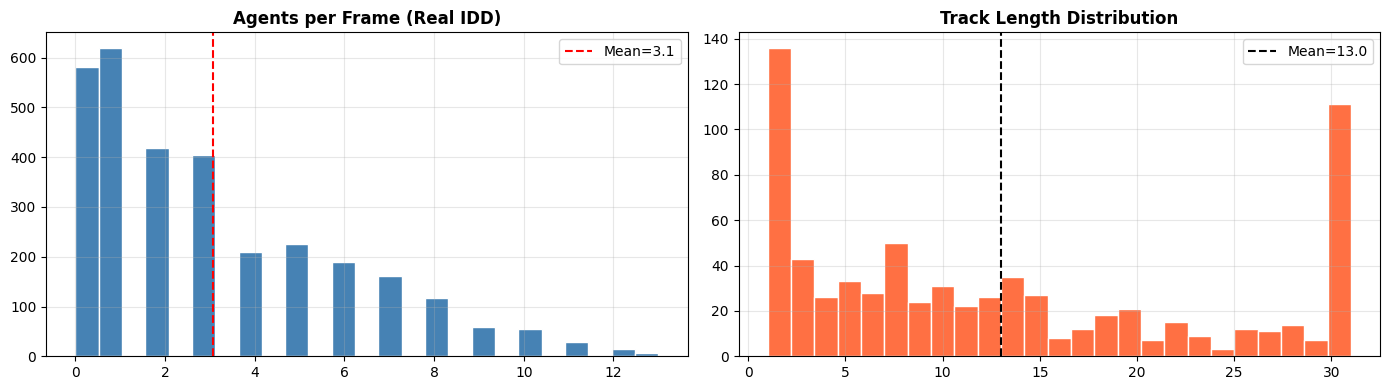

[SA-TJA] Real IDD data fully loaded. Sections 6–end run unchanged from here.


In [ ]:
#16
all_agents_flat = [a for frame in TRACKED_SEQUENCES for a in frame]
class_counts_global = defaultdict(int)
for a in all_agents_flat:
    class_counts_global[a['class']] += 1
total_global = max(sum(class_counts_global.values()), 1)

agents_per_frame = [len(f) for f in TRACKED_SEQUENCES]
print("=" * 65)
print("SA-TJA REAL IDD DATASET VERIFICATION")
print("=" * 65)
print(f"  Sequences     : {len(IDD_SEQUENCE_META)}")
print(f"  Total frames  : {len(TRACKED_SEQUENCES)}")
print(f"  Agents/frame  : min={min(agents_per_frame)}, "
      f"max={max(agents_per_frame)}, "
      f"mean={np.mean(agents_per_frame):.1f}")
print(f"\n  Class distribution:")
for cls, cnt in sorted(class_counts_global.items(), key=lambda x: -x[1]):
    bar = '█' * int(30 * cnt / total_global)
    print(f"    {cls:20s}: {bar} {cnt:5d} ({100*cnt/total_global:.1f}%)")

all_speeds_flat = [s for m in TRAJECTORY_META.values() for s in m['speeds']]
if all_speeds_flat:
    sp = np.array(all_speeds_flat)
    print(f"\n  Speed (norm)  : mean={sp.mean():.4f}, std={sp.std():.4f}, "
          f"max={sp.max():.4f}")
    if sp.std() < 0.005:
        print("  ⚠️  Speed std very low — verify pixel displacements are non-zero")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(agents_per_frame, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(agents_per_frame), color='red', ls='--',
                label=f'Mean={np.mean(agents_per_frame):.1f}')
axes[0].set_title('Agents per Frame (Real IDD)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)
tl_vals = list(track_lengths.values())
axes[1].hist(tl_vals, bins=25, color='#FF7043', edgecolor='white')
axes[1].axvline(np.mean(tl_vals), color='black', ls='--',
                label=f'Mean={np.mean(tl_vals):.1f}')
axes[1].set_title('Track Length Distribution', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(
    BASE_DIR/'outputs'/'visualizations'/'real_idd_stats.png', dpi=120)
plt.show()
print("[SA-TJA] Real IDD data fully loaded. "
      "Sections 6–end run unchanged from here.")

[SA-TJA] State vectors computed for 593 agents.
  State dimension: 11
  State fields: x, y, vx, vy, ax, ay, sin_h, cos_h, speed, jerk, class


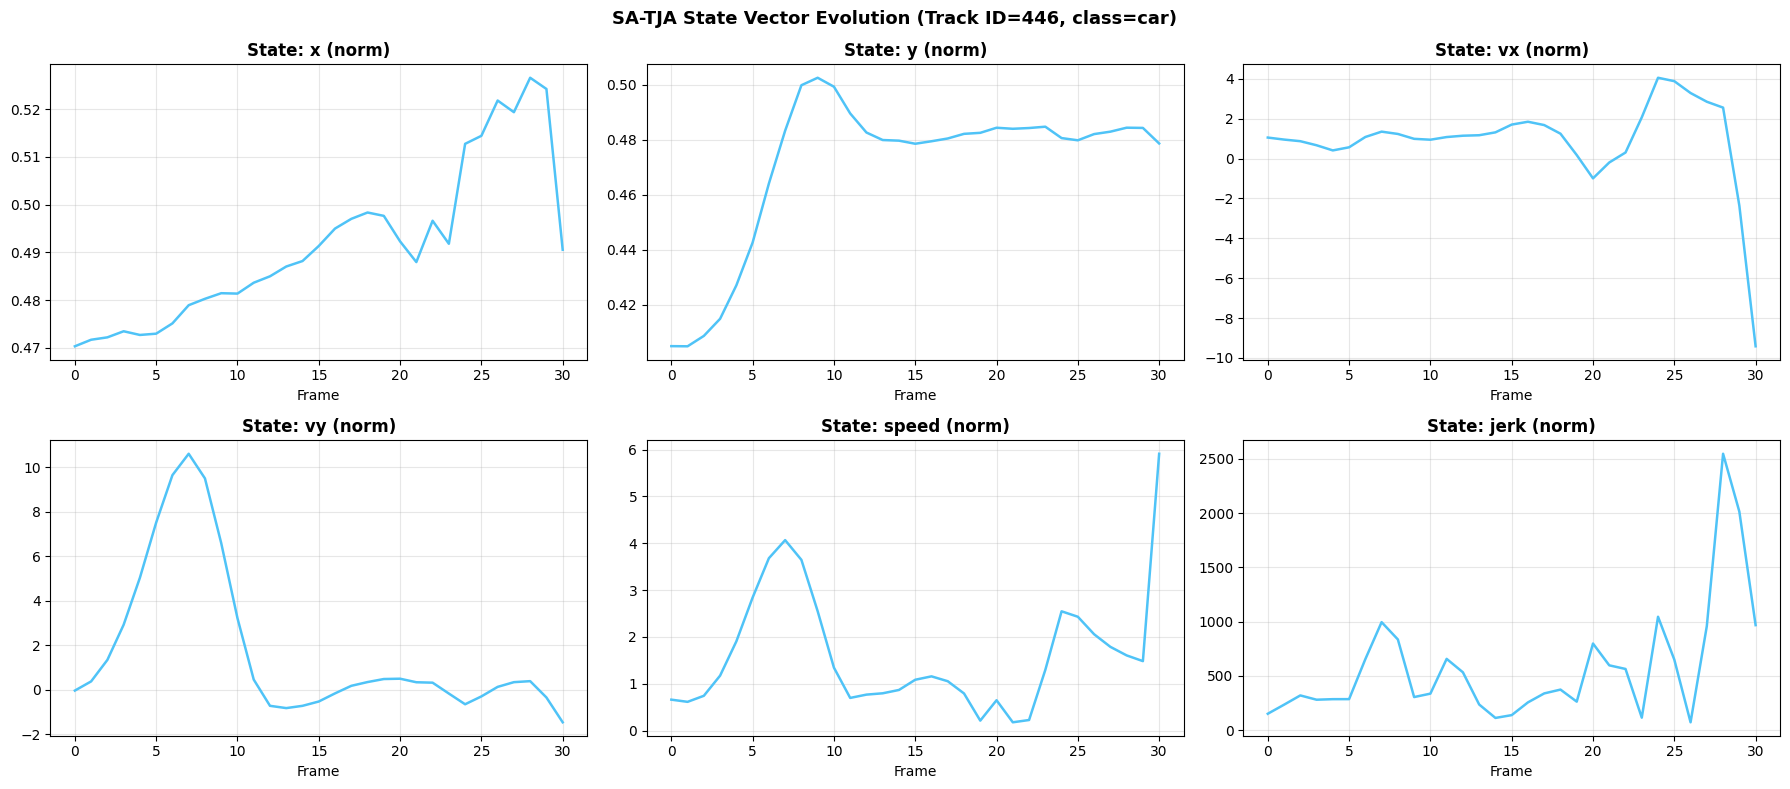

[SA-TJA] Motion representation complete.


In [ ]:
#17

class MotionProcessor:
    """
    Computes full motion state for tracked agents.
    Uses finite-difference velocity/acceleration estimation
    with optional Kalman filtering for smoothing.

    State vector: [x, y, vx, vy, ax, ay, heading, speed, jerk, class_id]
    """
    def __init__(self, fps: float = 30.0, smoothing: bool = True):
        self.dt = 1.0 / fps
        self.smoothing = smoothing

        self.kf_Q = np.eye(4) * 0.1
        self.kf_R = np.eye(2) * 1.0

    def compute_velocity(self, positions: np.ndarray) -> np.ndarray:
        """
        Finite difference velocity estimation.
        positions: (T, 2)
        returns: (T, 2) velocity vectors
        """
        if len(positions) < 2:
            return np.zeros_like(positions)
        vel = np.gradient(positions, self.dt, axis=0)
        if self.smoothing and len(positions) >= 5:

            alpha = 0.3
            for t in range(1, len(vel)):
                vel[t] = alpha * vel[t] + (1 - alpha) * vel[t-1]
        return vel

    def compute_acceleration(self, velocities: np.ndarray) -> np.ndarray:
        if len(velocities) < 2:
            return np.zeros_like(velocities)
        return np.gradient(velocities, self.dt, axis=0)

    def compute_heading(self, velocities: np.ndarray) -> np.ndarray:
        vx, vy = velocities[:, 0], velocities[:, 1]
        heading = np.arctan2(vy, vx)
        return heading

    def compute_speed(self, velocities: np.ndarray) -> np.ndarray:
        return np.linalg.norm(velocities, axis=1)

    def compute_jerk(self, accelerations: np.ndarray) -> np.ndarray:
        if len(accelerations) < 2:
            return np.zeros(len(accelerations))
        jerk_vec = np.gradient(accelerations, self.dt, axis=0)
        return np.linalg.norm(jerk_vec, axis=1)

    def build_state_sequence(self, track_id: int, trajectory: np.ndarray,
                              class_id: int) -> np.ndarray:
        """
        Build full state matrix for an agent trajectory.
        Returns: (T, STATE_DIM) where STATE_DIM = 10
        State: [x, y, vx, vy, ax, ay, sin(h), cos(h), speed, jerk, class]
        """
        T = len(trajectory)
        if T < 2:
            return np.zeros((T, 11))

        pos = trajectory  # (T, 2)
        vel = self.compute_velocity(pos)
        acc = self.compute_acceleration(vel)
        heading = self.compute_heading(vel)
        speed = self.compute_speed(vel)
        jerk = self.compute_jerk(acc)

        state = np.column_stack([
            pos[:, 0] / 1280.0,
            pos[:, 1] / 720.0,
            vel[:, 0] / 50.0,
            vel[:, 1] / 30.0,
            acc[:, 0] / 20.0,
            acc[:, 1] / 15.0,
            np.sin(heading),
            np.cos(heading),
            speed / 80.0,
            jerk / 50.0,
            np.full(T, class_id / 6.0),
        ])
        return state.astype(np.float32)


STATE_DIM = 11
motion_proc = MotionProcessor(fps=30.0, smoothing=True)

AGENT_STATES: Dict[int, np.ndarray] = {}

for tid, traj in TRAJECTORIES.items():
    meta = TRAJECTORY_META[tid]
    state_seq = motion_proc.build_state_sequence(tid, traj, meta['class_id'])
    AGENT_STATES[tid] = state_seq

print(f"[SA-TJA] State vectors computed for {len(AGENT_STATES)} agents.")
print(f"  State dimension: {STATE_DIM}")
print(f"  State fields: x, y, vx, vy, ax, ay, sin_h, cos_h, speed, jerk, class")

sample_tid = max(AGENT_STATES, key=lambda t: len(AGENT_STATES[t]))
sample_state = AGENT_STATES[sample_tid]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
titles = ['x (norm)', 'y (norm)', 'vx (norm)', 'vy (norm)', 'speed (norm)', 'jerk (norm)']
state_indices = [0, 1, 2, 3, 8, 9]

for ax, idx, title in zip(axes.flat, state_indices, titles):
    ax.plot(sample_state[:, idx], color='#4FC3F7', lw=1.8)
    ax.set_title(f'State: {title}', fontweight='bold')
    ax.grid(alpha=0.3); ax.set_xlabel('Frame')

plt.suptitle(f'SA-TJA State Vector Evolution (Track ID={sample_tid}, '
             f'class={TRAJECTORY_META[sample_tid]["class"]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'state_vectors.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("[SA-TJA] Motion representation complete.")


 SECTION 5: MULTI-AGENT INTERACTION MODEL

Building graphs: 100%|██████████| 100/100 [00:00<00:00, 1040.42it/s]


[SA-TJA] Built 100 scene interaction graphs.
  Sample graph (frame 5):
    Nodes: 8
    Edges: 18
    Node feat dim: (8, 11)
    Edge feat dim: (18, 8)
    Avg local density: 2.25 neighbors/agent


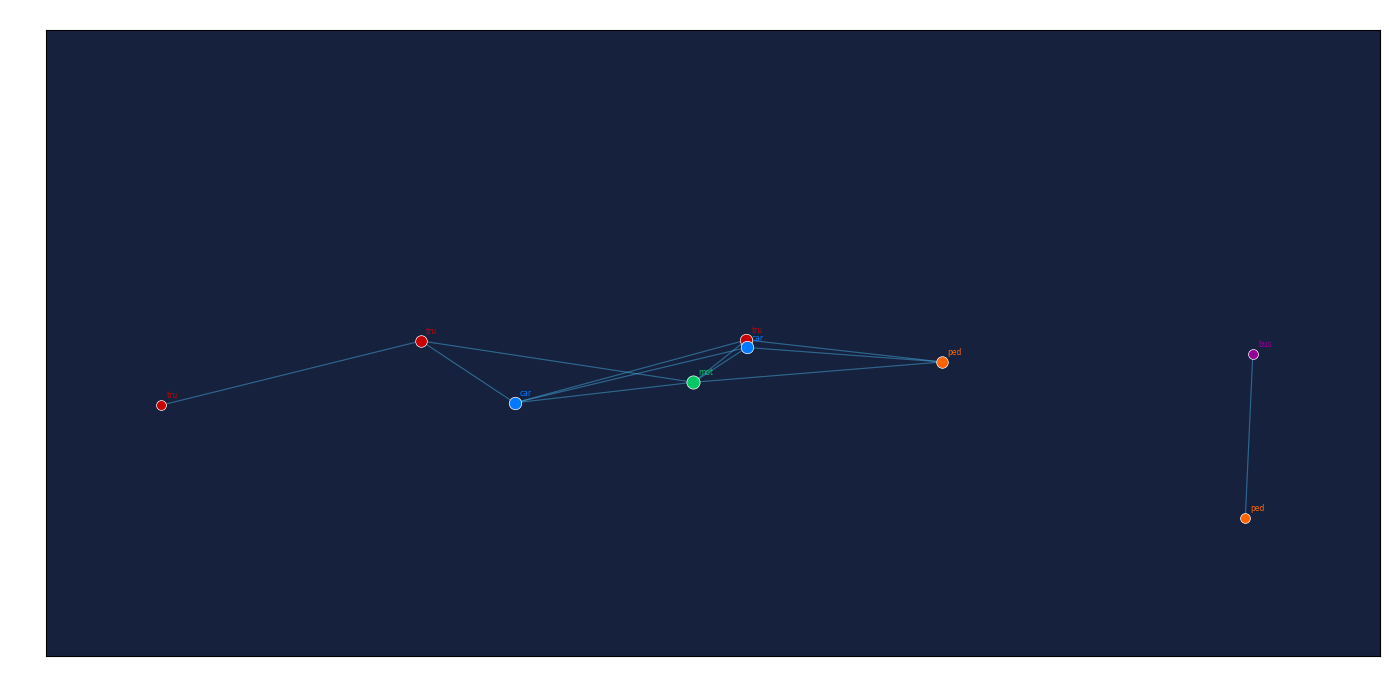

[SA-TJA] Interaction modeling complete.


In [ ]:
#18
class InteractionFeatureExtractor:
    """
    Extracts interaction features between agents in a scene.
    Key for Indian traffic where behavior is highly coupled.

    Features per agent pair:
    - Euclidean distance
    - Relative velocity
    - Relative heading
    - Approach rate (time-to-collision proxy)
    - Lateral gap
    - Longitudinal gap
    """

    INTERACTION_FEAT_DIM = 8

    def __init__(self, interaction_radius_px: float = 250.0, max_neighbors: int = 10):

        self.radius = interaction_radius_px
        self.max_neighbors = max_neighbors

    def compute_pairwise_features(self,
                                   ego: Dict, other: Dict,
                                   ego_state: np.ndarray,
                                   other_state: np.ndarray) -> np.ndarray:
        """
        Compute 8-dim interaction feature vector between ego and one neighbor.
        """
        dx = other['center'][0] - ego['center'][0]
        dy = other['center'][1] - ego['center'][1]
        dist = np.sqrt(dx**2 + dy**2) + 1e-6

        ego_vx, ego_vy = ego_state[2], ego_state[3]
        other_vx, other_vy = other_state[2], other_state[3]
        rel_vx = other_vx - ego_vx
        rel_vy = other_vy - ego_vy

        ego_heading = np.arctan2(ego_state[6], ego_state[7])
        other_heading = np.arctan2(other_state[6], other_state[7])
        rel_heading = other_heading - ego_heading

        pos_vec = np.array([dx, dy]) / dist
        vel_vec = np.array([rel_vx, rel_vy])
        approach_rate = np.dot(pos_vec, vel_vec)

        ego_fwd = np.array([np.cos(ego_heading), np.sin(ego_heading)])
        ego_lat = np.array([-np.sin(ego_heading), np.cos(ego_heading)])
        long_gap = np.dot([dx, dy], ego_fwd) / 1280.0
        lat_gap  = np.dot([dx, dy], ego_lat) / 720.0

        feat = np.array([
            dist / 500.0,
            rel_vx,
            rel_vy,
            np.sin(rel_heading),
            np.cos(rel_heading),
            approach_rate,
            long_gap,
            lat_gap,
        ], dtype=np.float32)
        return feat

    def build_neighbor_graph(self, frame_agents: List[Dict],
                              agent_states: Dict[int, np.ndarray],
                              frame_idx: int) -> Dict:
        """
        Build dynamic interaction graph for a scene.
        Returns adjacency structure with features.
        """
        n = len(frame_agents)
        if n == 0:
            return {'agents': [], 'edges': [], 'node_features': np.zeros((0, STATE_DIM)),
                    'edge_features': np.zeros((0, self.INTERACTION_FEAT_DIM)),
                    'edge_index': np.zeros((2, 0), dtype=np.int64)}

        centers = np.array([a['center'] for a in frame_agents])
        tids = [a['track_id'] for a in frame_agents]
        dists = cdist(centers, centers)

        edges = []
        edge_feats = []
        node_feats = []

        for i, agent_i in enumerate(frame_agents):
            tid_i = tids[i]
            state_i = agent_states.get(tid_i, np.zeros(STATE_DIM))
            if state_i.ndim == 2:
                state_i = state_i[-1]
            node_feats.append(state_i)

            neighbor_dists = dists[i].copy()
            neighbor_dists[i] = np.inf
            nearby_idx = np.where(neighbor_dists < self.radius)[0]

            if len(nearby_idx) > self.max_neighbors:
                nearby_idx = nearby_idx[np.argsort(neighbor_dists[nearby_idx])[:self.max_neighbors]]

            for j in nearby_idx:
                tid_j = tids[j]
                state_j = agent_states.get(tid_j, np.zeros(STATE_DIM))
                if state_j.ndim == 2:
                    state_j = state_j[-1]
                feat = self.compute_pairwise_features(agent_i, frame_agents[j],
                                                      state_i, state_j)
                edges.append((i, j))
                edge_feats.append(feat)

        node_features = np.array(node_feats)
        edge_index = np.array(edges, dtype=np.int64).T if edges else np.zeros((2, 0), dtype=np.int64)
        edge_features = np.array(edge_feats) if edge_feats else np.zeros((0, self.INTERACTION_FEAT_DIM))

        densities = np.sum(dists < self.radius, axis=1) - 1

        return {
            'agents': frame_agents,
            'n_agents': n,
            'track_ids': tids,
            'node_features': node_features.astype(np.float32),
            'edge_index': edge_index,
            'edge_features': edge_features.astype(np.float32),
            'centers': centers,
            'densities': densities,
            'frame_idx': frame_idx,
        }

    def compute_local_density(self, frame_agents: List[Dict]) -> np.ndarray:
        """Local density (neighbors within radius) per agent."""
        if not frame_agents:
            return np.array([])
        centers = np.array([a['center'] for a in frame_agents])
        dists = cdist(centers, centers)
        return np.sum(dists < self.radius, axis=1) - 1


interaction_extractor = InteractionFeatureExtractor(interaction_radius_px=280.0, max_neighbors=10)

SCENE_GRAPHS: List[Dict] = []
for frame_idx, tracked_frame in enumerate(tqdm(TRACKED_SEQUENCES[:100], desc='Building graphs')):
    graph = interaction_extractor.build_neighbor_graph(tracked_frame, AGENT_STATES, frame_idx)
    SCENE_GRAPHS.append(graph)

print(f"\n[SA-TJA] Built {len(SCENE_GRAPHS)} scene interaction graphs.")
sample_graph = SCENE_GRAPHS[5]
print(f"  Sample graph (frame 5):")
print(f"    Nodes: {sample_graph['n_agents']}")
print(f"    Edges: {sample_graph['edge_index'].shape[1]}")
print(f"    Node feat dim: {sample_graph['node_features'].shape}")
print(f"    Edge feat dim: {sample_graph['edge_features'].shape}")
print(f"    Avg local density: {np.mean(sample_graph['densities']):.2f} neighbors/agent")

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor('#16213E'); ax.set_xlim(0,1280); ax.set_ylim(720,0)

g = SCENE_GRAPHS[0]
centers = g['centers']
edge_idx = g['edge_index']

for k in range(edge_idx.shape[1]):
    i, j = edge_idx[0, k], edge_idx[1, k]
    ax.plot([centers[i,0], centers[j,0]], [centers[i,1], centers[j,1]],
            color='#4FC3F7', alpha=0.25, lw=0.8)

for i, agent in enumerate(g['agents']):
    cls = agent['class']
    color = CLASS_COLORS_MPL.get(cls, '#BDBDBD')
    cx, cy = agent['center']
    density = g['densities'][i]
    ax.scatter([cx], [cy], color=color, s=40 + density*10, zorder=5, edgecolors='white', lw=0.5)
    ax.text(cx+5, cy-8, f"{cls[:3]}", color=color, fontsize=5.5)

ax.set_title(f'SA-TJA Interaction Graph (Frame 0) | {g["n_agents"]} nodes | '
             f'{edge_idx.shape[1]} edges',
             color='white', fontweight='bold', fontsize=11)
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'interaction_graph.png',
            dpi=120, bbox_inches='tight', facecolor='#16213E')
plt.show()
print("[SA-TJA] Interaction modeling complete.")


SECTION 6: INTENT PREDICTION NETWORK


  [IntentDataset] Raw distribution before balancing:
    continue       : 273
    slow_stop      : 0
    merge_left     : 133
    merge_right    : 148
    overtake       : 88
    yield          : 52
  [IntentDataset] After balancing (200/class):
    continue       : 200
    slow_stop      : 200
    merge_left     : 200
    merge_right    : 200
    overtake       : 200
    yield          : 200
[SA-TJA] Intent dataset: 1200 samples
  Train: 960 | Val: 240
  Sanity check passed. Labels seen: [0, 1, 2, 3, 4, 5]
  Parameters: 834,502

[SA-TJA] Training IntentPredictionNetwork...
  Epoch   5/60 | Train Loss: 2.3197 | Val Loss: 1.6469 | Val Acc: 0.475 | LR: 1.97e-04
  Epoch  10/60 | Train Loss: 1.4240 | Val Loss: 1.3655 | Val Acc: 0.558 | LR: 1.87e-04
  Epoch  15/60 | Train Loss: 1.1302 | Val Loss: 1.1335 | Val Acc: 0.617 | LR: 1.72e-04
  Epoch  20/60 | Train Loss: 1.0906 | Val Loss: 1.0711 | Val Acc: 0.629 | LR: 1.53e-04
  Epoch  25/60 | Train Loss: 0.9514 | Val Loss: 1.0132 | Val Acc: 0.650

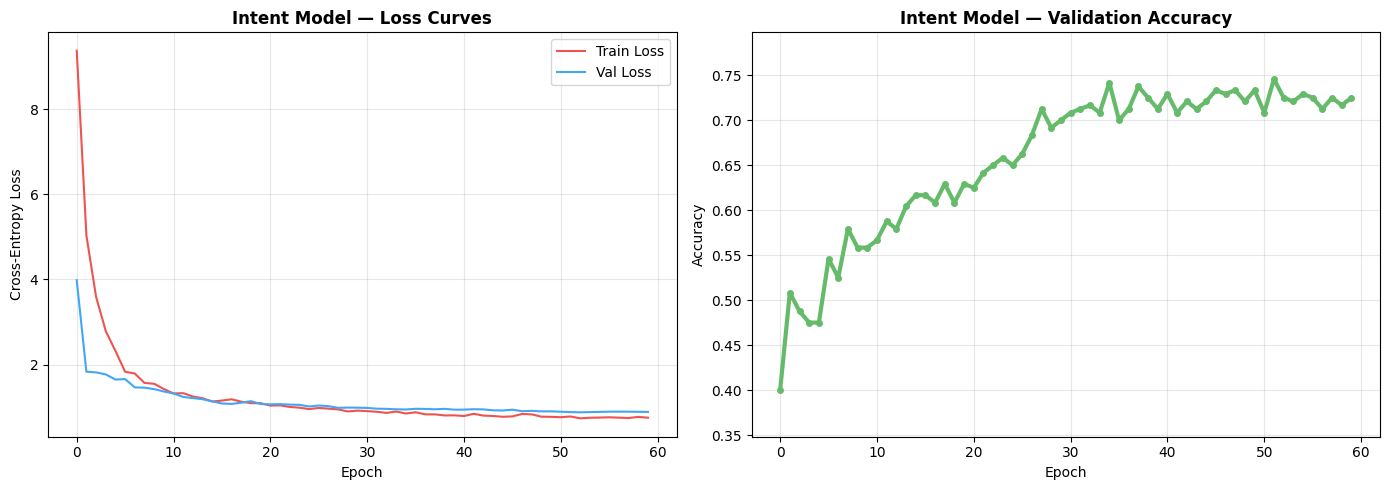

[SA-TJA] Best Val Acc achieved: 0.746


In [ ]:
#20
def infer_intent_label_v2(traj, future_traj, speeds):
    """
    Uses raw pixel-space cumulative displacement.
    Produces a balanced distribution across all 6 classes.
    """
    if len(traj) < 3 or len(future_traj) < 2:
        return 0

    dx = future_traj[-1, 0] - future_traj[0, 0]
    dy = future_traj[-1, 1] - future_traj[0, 1]
    total_disp = np.sqrt(dx**2 + dy**2) + 1e-6

    speed_arr    = np.array(speeds, dtype=np.float32)
    speed_mean   = float(np.mean(speed_arr))   if len(speed_arr) > 0 else 0.0
    speed_last   = float(speed_arr[-1])        if len(speed_arr) > 0 else 0.0
    speed_first  = float(speed_arr[0])         if len(speed_arr) > 0 else 0.0
    speed_change = speed_last - speed_first

    lateral_px = abs(dx)
    forward_px = abs(dy)

    if speed_mean < 2.0 and total_disp < 15.0:
        return 1
    if speed_change < -10 and total_disp < 25:
        return 5
    MERGE_PX  = 60.0
    SPEED_OVT = 25.0
    if lateral_px > MERGE_PX:
        if speed_mean > SPEED_OVT and forward_px > MERGE_PX:
            return 4
        return 2 if dx < 0 else 3

    return 0
class IntentDataset(Dataset):
    MAX_PER_CLASS = 200

    def __init__(self):
        self.samples = []
        self._build()

    def _build(self):
        raw = []
        for tid, traj in TRAJECTORIES.items():
            T = len(traj)
            if T < OBS_HORIZON + 5:
                continue
            state_seq = AGENT_STATES.get(tid)
            if state_seq is None or len(state_seq) < OBS_HORIZON + 5:
                continue
            meta = TRAJECTORY_META[tid]

            for t in range(OBS_HORIZON, T - PRED_HORIZON):
                obs_states  = state_seq[t - OBS_HORIZON:t]
                future_traj = traj[t:t + PRED_HORIZON]

                if tid in registry.tracks:
                    hist = list(registry.tracks[tid].history)
                    raw_speeds = np.array([
                        np.linalg.norm([h['vx'], h['vy']])
                        for h in hist[max(0, t - OBS_HORIZON):t]
                    ])
                else:
                    raw_speeds = meta['speeds'][t - OBS_HORIZON:t] * 50.0

                intent_label = infer_intent_label_v2(
                    traj[t - OBS_HORIZON:t], future_traj,
                    raw_speeds if len(raw_speeds) > 0 else np.zeros(OBS_HORIZON),
                )

                if t < len(SCENE_GRAPHS):
                    graph = SCENE_GRAPHS[t]
                    if tid in graph['track_ids']:
                        aidx    = graph['track_ids'].index(tid)
                        node_f  = graph['node_features'][aidx]
                        density = float(graph['densities'][aidx]) / 10.0
                    else:
                        node_f  = obs_states[-1]
                        density = 0.0
                else:
                    node_f  = obs_states[-1]
                    density = 0.0

                if not np.isfinite(obs_states).all():
                    continue

                raw.append({
                    'obs_states':      obs_states.astype(np.float32),
                    'agent_node_feat': node_f.astype(np.float32),
                    'local_density':   density,
                    'class_id':        meta['class_id'],
                    'intent_label':    intent_label,
                })

        by_class = defaultdict(list)
        for s in raw:
            by_class[s['intent_label']].append(s)

        print('  [IntentDataset] Raw distribution before balancing:')
        for ci in range(N_INTENTS):
            print(f'    {INTENT_CLASSES[ci]:15s}: {len(by_class[ci])}')


        donor_pool = [
            s for s in raw
            if np.isfinite(s['obs_states']).all()
            and s['obs_states'].std() > 1e-4]
        if len(donor_pool) == 0:
            donor_pool = raw

        balanced = []
        for ci in range(N_INTENTS):
            real_samples = by_class[ci]
            pool = real_samples[:]

            target = self.MAX_PER_CLASS

            if len(real_samples) == 0:
                while len(pool) < target:
                    base = random.choice(donor_pool)
                    aug  = base.copy()
                    aug['obs_states'] = np.clip(
                        base['obs_states'] +
                        np.random.normal(0, 0.08,
                                         base['obs_states'].shape
                                         ).astype(np.float32),
                        -1.0, 1.0
                    )
                    aug['agent_node_feat'] = np.clip(
                        base['agent_node_feat'] +
                        np.random.normal(0, 0.05,
                                         base['agent_node_feat'].shape
                                         ).astype(np.float32),
                        -1.0, 1.0
                    )
                    aug['intent_label'] = ci
                    pool.append(aug)

            elif len(real_samples) < target:
                while len(pool) < target:
                    base = random.choice(real_samples)
                    aug  = base.copy()
                    aug['obs_states'] = np.clip(
                        base['obs_states'] +
                        np.random.normal(0, 0.02,
                                         base['obs_states'].shape
                                         ).astype(np.float32),
                        -1.0, 1.0
                    )
                    pool.append(aug)


            random.shuffle(pool)
            balanced.extend(pool[:target])

        random.shuffle(balanced)

        clean = [
            s for s in balanced
            if np.isfinite(s['obs_states']).all()
            and np.isfinite(s['agent_node_feat']).all()
        ]
        removed = len(balanced) - len(clean)
        if removed:
            print(f'  [IntentDataset] Removed {removed} NaN samples.')

        self.samples = clean

        print(f'  [IntentDataset] After balancing ({self.MAX_PER_CLASS}/class):')
        final_counts = defaultdict(int)
        for s in self.samples:
            final_counts[s['intent_label']] += 1
        for ci in range(N_INTENTS):
            print(f'    {INTENT_CLASSES[ci]:15s}: {final_counts[ci]}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (
            torch.tensor(s['obs_states']),
            torch.tensor(s['agent_node_feat']),
            torch.tensor([s['local_density']], dtype=torch.float32),
            torch.tensor(s['intent_label'],    dtype=torch.long),
        )


class TemporalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, n_heads,
                                             dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return self.norm(x + self.dropout(out))


class IntentPredictionNetwork(nn.Module):
    def __init__(self, state_dim=STATE_DIM, d_model=128, n_layers=4,
                 n_heads=4, n_intents=N_INTENTS, dropout=0.15):
        super().__init__()
        self.d_model    = d_model
        self.input_proj = nn.Sequential(
            nn.Linear(state_dim, d_model),
            nn.ReLU(),
            nn.LayerNorm(d_model),
        )
        self.pos_enc = nn.Parameter(
            torch.randn(1, OBS_HORIZON, d_model) * 0.02
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer,
                                                  num_layers=n_layers)
        self.ctx_proj = nn.Sequential(
            nn.Linear(state_dim + 1, 64),
            nn.GELU(),
            nn.Linear(64, d_model // 2),
            nn.GELU(),
        )
        self.head = nn.Sequential(
            nn.Linear(d_model + d_model // 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_intents),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, obs_states, node_feat, density, return_features=False):
        x = self.input_proj(obs_states)
        x = x + self.pos_enc[:, :x.shape[1], :]
        x = self.transformer(x)
        temporal_feat = x[:, -1, :]
        ctx_in   = torch.cat([node_feat, density], dim=-1)
        ctx_feat = self.ctx_proj(ctx_in)
        fused    = torch.cat([temporal_feat, ctx_feat], dim=-1)
        logits   = self.head(fused)
        if return_features:
            return logits, fused
        return logits

    def predict_proba(self, obs_states, node_feat, density, n_mc_samples=20):
        self.train()
        mc_probs = []
        with torch.no_grad():
            for _ in range(n_mc_samples):
                logits = self.forward(obs_states, node_feat, density)
                mc_probs.append(F.softmax(logits, dim=-1).unsqueeze(0))
        mc_probs = torch.cat(mc_probs, dim=0)
        mean_probs      = mc_probs.mean(dim=0)
        epistemic_unc   = mc_probs.var(dim=0).sum(dim=-1)
        return mean_probs, epistemic_unc


def train_intent_model(model, train_loader, val_loader,n_epochs=60, lr=2e-4, device=DEVICE):
    label_counts = np.bincount(
        [s['intent_label'] for s in intent_dataset.samples],
        minlength=N_INTENTS
    ).astype(np.float32)
    label_counts    = np.maximum(label_counts, 1)
    class_weights   = torch.tensor(
        (1.0 / label_counts) / (1.0 / label_counts).sum() * N_INTENTS,
        dtype=torch.float32
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr / 20
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05,
                                    weight=class_weights)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(n_epochs):
        model.train()
        train_loss  = 0.0
        n_train_eff = 0
        for obs, node_f, dens, label in train_loader:
            obs, node_f, dens, label = (
                obs.to(device), node_f.to(device),
                dens.to(device), label.to(device)
            )
            optimizer.zero_grad()
            logits = model(obs, node_f, dens)

            if not torch.isfinite(logits).all():
                print(f'  [WARN] NaN logits at epoch {epoch+1}')
                continue

            loss = criterion(logits, label)
            if not torch.isfinite(loss):
                print(f'  [WARN] NaN loss at epoch {epoch+1}')
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss  += loss.item() * len(label)
            n_train_eff += len(label)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for obs, node_f, dens, label in val_loader:
                obs, node_f, dens, label = (
                    obs.to(device), node_f.to(device),
                    dens.to(device), label.to(device)
                )
                logits = model(obs, node_f, dens)
                if not torch.isfinite(logits).all():
                    continue
                loss = criterion(logits, label)
                if torch.isfinite(loss):
                    val_loss += loss.item() * len(label)
                preds        = logits.argmax(dim=-1)
                val_correct += (preds == label).sum().item()
                val_total   += len(label)

        t_loss = train_loss  / max(n_train_eff, 1)
        v_loss = val_loss    / max(len(val_loader.dataset), 1)
        v_acc  = val_correct / max(val_total, 1)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        scheduler.step()

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(
                model.state_dict(),
                BASE_DIR / 'models' / 'intent' / 'intent_best.pt'
            )

        if (epoch + 1) % 5 == 0:
            print(
                f'  Epoch {epoch+1:3d}/{n_epochs} | '
                f'Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | '
                f'Val Acc: {v_acc:.3f} | LR: {scheduler.get_last_lr()[0]:.2e}'
            )

    model.load_state_dict(
        torch.load(BASE_DIR / 'models' / 'intent' / 'intent_best.pt')
    )
    print(f'\n[SA-TJA] Intent model training complete. '
          f'Best Val Acc: {best_val_acc:.3f}')
    return history


intent_dataset      = IntentDataset()
print(f'[SA-TJA] Intent dataset: {len(intent_dataset)} samples')

n_train = int(0.8 * len(intent_dataset))
n_val   = len(intent_dataset) - n_train
intent_train, intent_val = random_split(
    intent_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
intent_loader_train = DataLoader(intent_train, batch_size=64,
                                  shuffle=True,  num_workers=0)
intent_loader_val   = DataLoader(intent_val,   batch_size=64,
                                  shuffle=False, num_workers=0)
print(f'  Train: {n_train} | Val: {n_val}')

_obs, _nf, _d, _lbl = next(iter(intent_loader_train))
assert torch.isfinite(_obs).all(), 'NaN in obs_states'
assert torch.isfinite(_nf).all(),  'NaN in node_feat'
assert _lbl.min() >= 0 and _lbl.max() < N_INTENTS, 'label out of range'
print(f'  Sanity check passed. Labels seen: {sorted(_lbl.unique().tolist())}')

intent_net = IntentPredictionNetwork(
    state_dim=STATE_DIM, d_model=128, n_layers=4,
    n_heads=4, n_intents=N_INTENTS, dropout=0.15
).to(DEVICE)
print(f'  Parameters: {sum(p.numel() for p in intent_net.parameters() if p.requires_grad):,}')

print('\n[SA-TJA] Training IntentPredictionNetwork...')
intent_history = train_intent_model(
    intent_net,
    intent_loader_train,
    intent_loader_val,
    n_epochs=60,
    lr=2e-4,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(intent_history['train_loss'], label='Train Loss', color='#EF5350')
axes[0].plot(intent_history['val_loss'],   label='Val Loss',   color='#42A5F5')
axes[0].set_title('Intent Model — Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(intent_history['val_acc'], color='#66BB6A', lw=3,
             marker='o', markersize=4)
axes[1].set_title('Intent Model — Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
acc_vals = intent_history['val_acc']
acc_min, acc_max = min(acc_vals), max(acc_vals)
margin = max((acc_max - acc_min) * 0.15, 0.02)
axes[1].set_ylim(max(0.0, acc_min - margin), min(1.05, acc_max + margin))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'intent_training_fixed.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f'[SA-TJA] Best Val Acc achieved: {max(intent_history["val_acc"]):.3f}')

              precision    recall  f1-score   support

    continue       0.58      0.80      0.67        45
   slow_stop       1.00      1.00      1.00        37
  merge_left       0.74      0.66      0.70        44
 merge_right       0.69      0.75      0.72        36
    overtake       0.74      0.66      0.70        44
       yield       0.88      0.62      0.72        34

    accuracy                           0.75       240
   macro avg       0.77      0.75      0.75       240
weighted avg       0.76      0.75      0.75       240



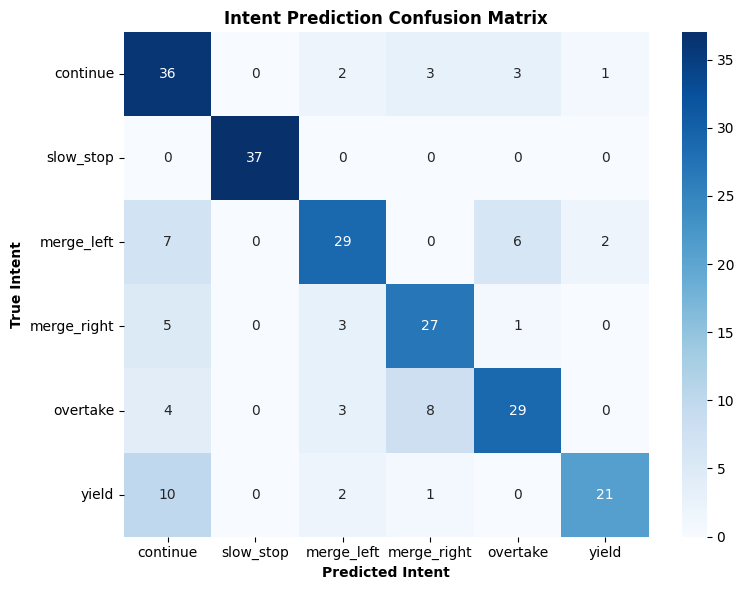

In [ ]:
#21
intent_net.eval()
all_preds, all_labels, all_probs_list = [], [], []

with torch.no_grad():
    for obs, node_f, dens, label in intent_loader_val:
        obs, node_f, dens = obs.to(DEVICE), node_f.to(DEVICE), dens.to(DEVICE)
        logits = intent_net(obs, node_f, dens)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(label.numpy())
        all_probs_list.extend(probs)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs_list)

present_labels = sorted(
    np.unique(np.concatenate([all_labels, all_preds]))
)

print(
    classification_report(
        all_labels,
        all_preds,
        labels=present_labels,
        target_names=[INTENT_CLASSES[i] for i in present_labels],
        zero_division=0
    )
)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=INTENT_CLASSES, yticklabels=INTENT_CLASSES, ax=ax)
ax.set_xlabel('Predicted Intent', fontweight='bold')
ax.set_ylabel('True Intent', fontweight='bold')
ax.set_title('Intent Prediction Confusion Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'intent_confusion.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
#22
try:
    _ = all_labels
    _ = all_preds
except NameError:
    import numpy as np
    print("WARNING: 'all_labels' or 'all_preds' not found. "
          "Please ensure the intent model evaluation cell (Cell 29/1Rs6HLBfrVFD) "
          "has been executed.")
    all_labels = np.array([])
    all_preds = np.array([])

print("Unique labels:", np.unique(all_labels))
print("Unique preds :", np.unique(all_preds))
print("INTENT_CLASSES:", INTENT_CLASSES)
print("Num classes:", len(INTENT_CLASSES))

Unique labels: [0 1 2 3 4 5]
Unique preds : [0 1 2 3 4 5]
INTENT_CLASSES: ['continue', 'slow_stop', 'merge_left', 'merge_right', 'overtake', 'yield']
Num classes: 6


[SA-TJA] Computing intent for 729 unique track IDs...


Intent probs: 100%|██████████| 729/729 [00:01<00:00, 429.02it/s]


[SA-TJA] Intent distributions computed for 729 agents.


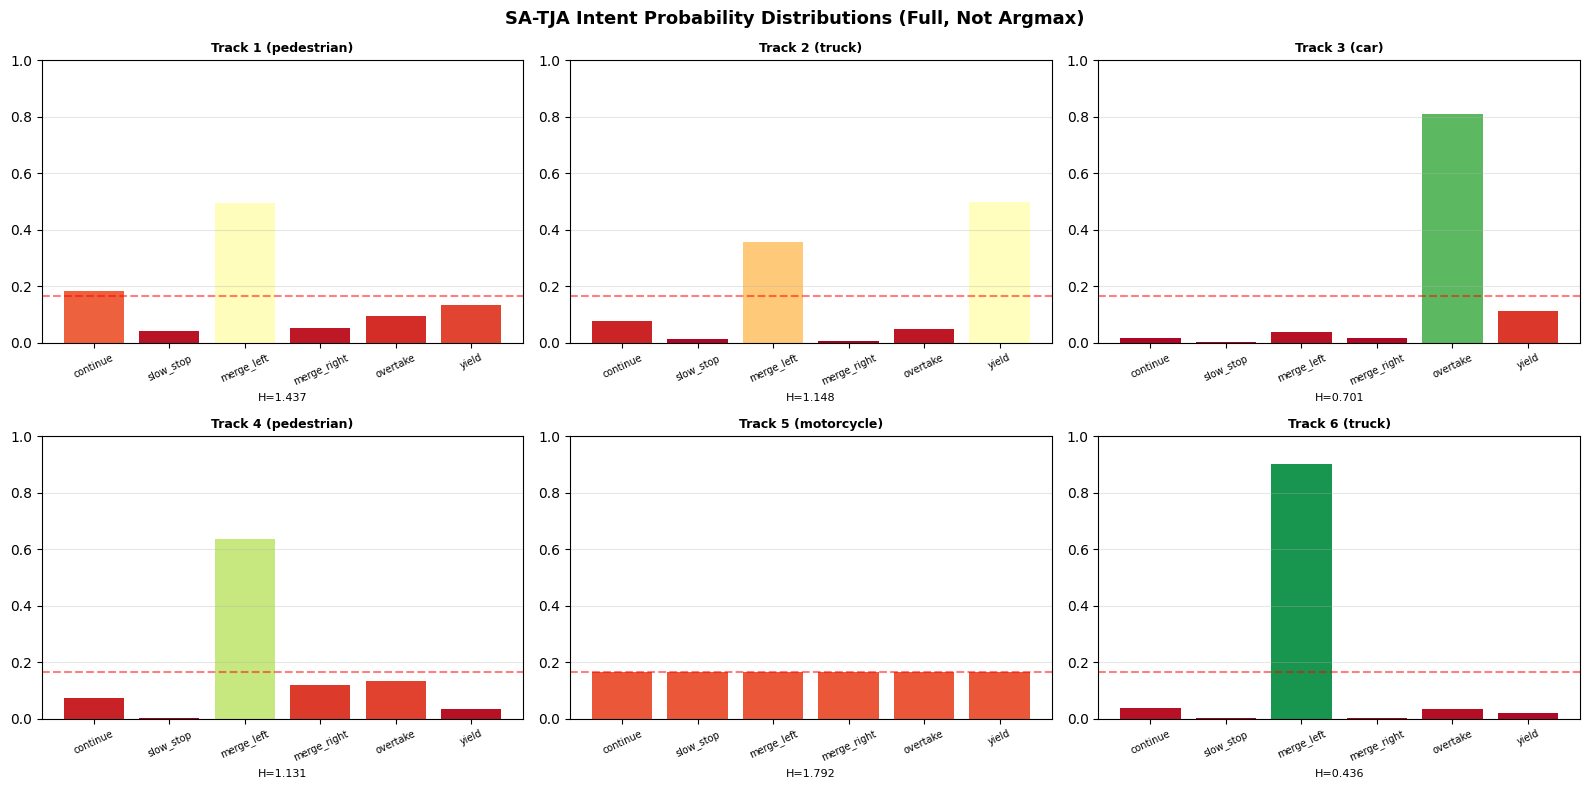

[SA-TJA] Intent probability distributions stored and visualized.


In [ ]:
#23
AGENT_INTENT_PROBS: Dict[int, np.ndarray] = {}
AGENT_INTENT_ENTROPY: Dict[int, float] = {}

intent_net.eval()
active_agent_ids = set()
for frame in TRACKED_SEQUENCES:
    for a in frame:
        active_agent_ids.add(a['track_id'])

print(f"[SA-TJA] Computing intent for {len(active_agent_ids)} unique track IDs...")

with torch.no_grad():
    for tid in tqdm(active_agent_ids, desc='Intent probs'):
        state_seq = AGENT_STATES.get(tid)
        if state_seq is None or len(state_seq) < OBS_HORIZON:
            probs = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS
        else:
            obs = torch.tensor(
                state_seq[-OBS_HORIZON:], dtype=torch.float32
            ).unsqueeze(0).to(DEVICE)

            node_f = torch.zeros((1, STATE_DIM), dtype=torch.float32, device=DEVICE)
            density = torch.zeros((1, 1), dtype=torch.float32, device=DEVICE)
            for sg in reversed(SCENE_GRAPHS):
                if tid in sg['track_ids']:
                    aidx = sg['track_ids'].index(tid)
                    node_f = torch.tensor(
                        sg['node_features'][aidx], dtype=torch.float32
                    ).unsqueeze(0).to(DEVICE)
                    density = torch.tensor(
                        [[sg['densities'][aidx] / 10.0]], dtype=torch.float32
                    ).to(DEVICE)
                    break

            logits = intent_net(obs.float(), node_f.float(), density.float())
            probs  = F.softmax(logits, dim=-1).cpu().numpy()[0]

        ent = float(scipy_entropy(probs))
        AGENT_INTENT_PROBS[tid] = probs
        AGENT_INTENT_ENTROPY[tid] = ent

print(f"[SA-TJA] Intent distributions computed for {len(AGENT_INTENT_PROBS)} agents.")

sample_agents = list(AGENT_INTENT_PROBS.items())[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, (tid, probs) in zip(axes.flat, sample_agents):

    ax.bar(
        INTENT_CLASSES,
        probs,
        color=plt.cm.RdYlGn(np.array(probs))
    )

    ax.set_ylim(0, 1)

    ax.set_title(
        f"Track {tid} "
        f"({registry.tracks[tid].agent_class if tid in registry.tracks else '?'})",
        fontweight='bold',
        fontsize=9
    )

    ax.tick_params(axis='x', rotation=25, labelsize=7)

    ax.axhline(
        1 / N_INTENTS,
        color='red',
        ls='--',
        alpha=0.5,
        label='Uniform prior'
    )

    entropy = AGENT_INTENT_ENTROPY.get(tid, 0.0)

    ax.set_xlabel(
        f"H={entropy:.3f}",
        fontsize=8
    )

    ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    'SA-TJA Intent Probability Distributions (Full, Not Argmax)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    BASE_DIR / 'outputs' / 'visualizations' / 'intent_distributions.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print("[SA-TJA] Intent probability distributions stored and visualized.")

---
# SECTION 7: UNCERTAINTY ESTIMATION
---

[SA-TJA] Uncertainty estimation complete for 729 agents.
  Aleatoric uncertainty — mean: 0.747, max: 1.000
  Predictive uncertainty — mean: 0.656, max: 0.917


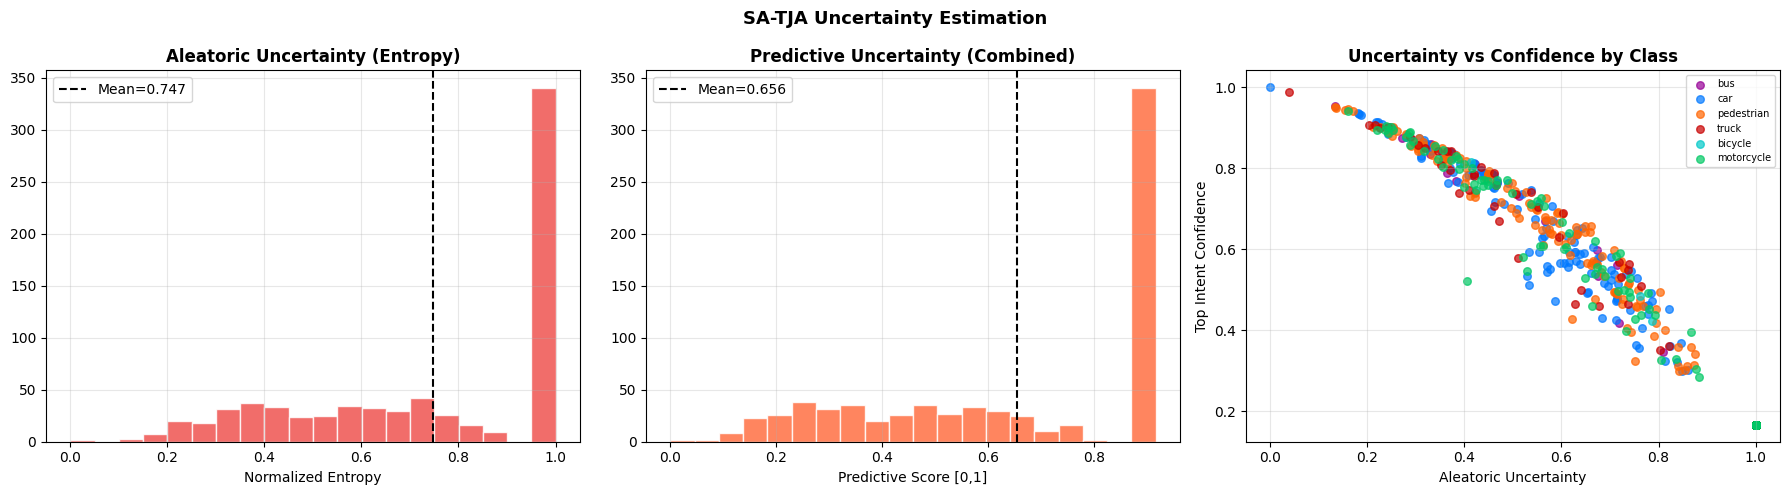

[SA-TJA] Uncertainty visualization complete.


In [ ]:
#24
class UncertaintyEstimator:
    """
    Multi-source uncertainty estimator for SA-TJA agents.
    Supports:
    - Aleatoric uncertainty (entropy of softmax output)
    - Epistemic uncertainty (MC Dropout variance)
    - Trajectory uncertainty (spread of predicted future paths)
    """
    def __init__(self, n_mc_samples: int = 20):
        self.n_mc = n_mc_samples

    def compute_entropy(self, probs: np.ndarray) -> float:
        """
        Shannon entropy of intent distribution.
        Max entropy = log(N_INTENTS): agent is completely unpredictable.
        Zero entropy: deterministic intent.
        """
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        H = -np.sum(probs * np.log(probs))
        H_max = np.log(len(probs))
        return float(H / H_max)
    def compute_epistemic_uncertainty(self, model: nn.Module,
                                       obs_states: torch.Tensor,
                                       node_feat: torch.Tensor,
                                       density: torch.Tensor) -> Dict:
        """
        MC Dropout: run model N times in train mode, measure variance.
        Epistemic uncertainty = model's 'knowledge uncertainty'.
        """
        model.train()
        probs_mc = []
        with torch.no_grad():
            for _ in range(self.n_mc):
                logits = model(obs_states, node_feat, density)
                probs = F.softmax(logits, dim=-1).cpu().numpy()
                probs_mc.append(probs)
        model.eval()

        probs_mc = np.array(probs_mc)
        mean_probs = probs_mc.mean(axis=0)
        epistemic_var = probs_mc.var(axis=0).sum(axis=-1)

        return {
            'mean_probs': mean_probs,
            'epistemic_variance': epistemic_var,
            'aleatoric_entropy': np.array([
                self.compute_entropy(p) for p in mean_probs
            ]),
        }

    def compute_agent_uncertainty_scores(self,
                                          intent_probs: Dict[int, np.ndarray]) -> Dict[int, Dict]:
        """Compute and store all uncertainty metrics per agent."""
        results = {}
        for tid, probs in intent_probs.items():
            aleatoric = self.compute_entropy(probs)
            prob_variance = float(np.var(probs))
            max_prob = float(np.max(probs))
            predictive_unc = (aleatoric + (1 - max_prob)) / 2.0

            results[tid] = {
                'aleatoric': aleatoric,
                'max_prob': max_prob,
                'prob_variance': prob_variance,
                'predictive': predictive_unc,
                'intent_probs': probs,
            }
        return results


uncertainty_estimator = UncertaintyEstimator(n_mc_samples=20)

AGENT_UNCERTAINTY: Dict[int, Dict] = uncertainty_estimator.compute_agent_uncertainty_scores(
    AGENT_INTENT_PROBS
)

print(f"[SA-TJA] Uncertainty estimation complete for {len(AGENT_UNCERTAINTY)} agents.")

aleatoric_scores = [v['aleatoric'] for v in AGENT_UNCERTAINTY.values()]
predictive_scores = [v['predictive'] for v in AGENT_UNCERTAINTY.values()]
print(f"  Aleatoric uncertainty — mean: {np.mean(aleatoric_scores):.3f}, "
      f"max: {max(aleatoric_scores):.3f}")
print(f"  Predictive uncertainty — mean: {np.mean(predictive_scores):.3f}, "
      f"max: {max(predictive_scores):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(aleatoric_scores, bins=20, color='#EF5350', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(aleatoric_scores), color='black', ls='--',
                label=f'Mean={np.mean(aleatoric_scores):.3f}')
axes[0].set_title('Aleatoric Uncertainty (Entropy)', fontweight='bold')
axes[0].set_xlabel('Normalized Entropy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(predictive_scores, bins=20, color='#FF7043', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(predictive_scores), color='black', ls='--',
                label=f'Mean={np.mean(predictive_scores):.3f}')
axes[1].set_title('Predictive Uncertainty (Combined)', fontweight='bold')
axes[1].set_xlabel('Predictive Score [0,1]'); axes[1].legend(); axes[1].grid(alpha=0.3)

max_probs = [v['max_prob'] for v in AGENT_UNCERTAINTY.values()]
classes = [registry.tracks[tid].agent_class if tid in registry.tracks else 'unknown'
           for tid in AGENT_UNCERTAINTY.keys()]
for cls in set(classes):
    idx = [i for i, c in enumerate(classes) if c == cls]
    ax_u = [aleatoric_scores[i] for i in idx]
    ax_c = [max_probs[i] for i in idx]
    axes[2].scatter(ax_u, ax_c, label=cls,
                    color=CLASS_COLORS_MPL.get(cls, '#808080'), alpha=0.7, s=30)
axes[2].set_xlabel('Aleatoric Uncertainty')
axes[2].set_ylabel('Top Intent Confidence')
axes[2].set_title('Uncertainty vs Confidence by Class', fontweight='bold')
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

plt.suptitle('SA-TJA Uncertainty Estimation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'uncertainty.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("[SA-TJA] Uncertainty visualization complete.")

In [ ]:
#25
TRAJ_OBS_HORIZON=6
TRAJ_PRED_HORIZON=10

class TrajectoryForecastDataset(Dataset):
    def __init__(self,trajectories,agent_states,intent_probs_dict,obs_h=TRAJ_OBS_HORIZON,pred_h=TRAJ_PRED_HORIZON):
        self.samples=[]; self._build(trajectories,agent_states,intent_probs_dict,obs_h,pred_h)

    def _build(self,trajectories,agent_states,intent_probs_dict,obs_h,pred_h):
        for tid,traj in trajectories.items():
            T=len(traj)
            if T<obs_h+pred_h: continue
            state_seq=agent_states.get(tid)
            if state_seq is None or len(state_seq)<obs_h+pred_h: continue

            for t in range(obs_h,T-pred_h,1):
                obs_pos=traj[t-obs_h:t].copy(); future_pos=traj[t:t+pred_h].copy(); obs_state=state_seq[t-obs_h:t]
                anchor=obs_pos[-1].copy()
                obs_pos_norm=obs_pos-anchor; future_pos_norm=future_pos-anchor
                intent_probs=intent_probs_dict.get(tid,np.ones(N_INTENTS)/N_INTENTS)

                self.samples.append({'obs_pos':obs_pos_norm.astype(np.float32)/200.0,
                                     'obs_state':obs_state.astype(np.float32),
                                     'intent_probs':intent_probs.astype(np.float32),
                                     'future_pos':future_pos_norm.astype(np.float32)/200.0,
                                     'anchor':anchor.astype(np.float32),
                                     'track_id':tid})

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        s=self.samples[idx]
        return (torch.tensor(s['obs_pos']),torch.tensor(s['obs_state']),torch.tensor(s['intent_probs']),torch.tensor(s['future_pos']))

traj_dataset=TrajectoryForecastDataset(TRAJECTORIES,AGENT_STATES,AGENT_INTENT_PROBS)

print(f"[SA-TJA] Trajectory forecast dataset: {len(traj_dataset)} samples")

n_traj_train=int(0.8*len(traj_dataset))
n_traj_val=len(traj_dataset)-n_traj_train

traj_train,traj_val=random_split(traj_dataset,[n_traj_train,n_traj_val])

traj_loader_train=DataLoader(traj_train,batch_size=32,shuffle=True,num_workers=2)

traj_loader_val=DataLoader(traj_val,batch_size=32,shuffle=False,num_workers=2)

print(f"  Train: {n_traj_train} | Val: {n_traj_val}")

[SA-TJA] Trajectory forecast dataset: 2421 samples
  Train: 1936 | Val: 485


In [ ]:
#26
N_TRAJ_MODES=5

class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len=200):
        super().__init__(); pe=torch.zeros(max_len,d_model); pos=torch.arange(0,max_len,dtype=torch.float).unsqueeze(1); div=torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.0)/d_model)); pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div[:d_model//2]); self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return x+self.pe[:,:x.shape[1],:]

class TrajectoryForecastNetwork(nn.Module):
    def __init__(self,pos_dim=2,state_dim=STATE_DIM,intent_dim=N_INTENTS,d_model=128,n_heads=4,n_enc_layers=2,n_dec_layers=3,pred_horizon=TRAJ_PRED_HORIZON,n_modes=N_TRAJ_MODES,dropout=0.1):
        super().__init__(); self.pred_horizon=pred_horizon; self.n_modes=n_modes; self.d_model=d_model
        self.pos_emb=nn.Sequential(nn.Linear(pos_dim+state_dim,d_model),nn.LayerNorm(d_model))
        self.encoder_lstm=nn.LSTM(d_model,d_model,n_enc_layers,batch_first=True,dropout=dropout if n_enc_layers>1 else 0,bidirectional=True)
        self.enc_proj=nn.Linear(d_model*2,d_model)
        self.intent_emb=nn.Sequential(nn.Linear(intent_dim,64),nn.GELU(),nn.Linear(64,d_model))
        self.mode_queries=nn.Parameter(torch.randn(n_modes,d_model)*0.02)
        self.pos_enc=PositionalEncoding(d_model,max_len=pred_horizon+20)
        decoder_layer=nn.TransformerDecoderLayer(d_model=d_model,nhead=n_heads,dim_feedforward=d_model*4,dropout=dropout,batch_first=True,norm_first=True)
        self.decoder=nn.TransformerDecoder(decoder_layer,num_layers=n_dec_layers)
        self.traj_head=nn.Sequential(nn.Linear(d_model,d_model//2),nn.GELU(),nn.Linear(d_model//2,pred_horizon*2))
        self.mode_prob_head=nn.Linear(d_model,1); self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self,obs_pos,obs_state,intent_probs):
        B=obs_pos.shape[0]
        enc_emb=self.pos_emb(torch.cat([obs_pos,obs_state],dim=-1))
        enc_out,_=self.encoder_lstm(enc_emb)
        memory=torch.cat([self.intent_emb(intent_probs).unsqueeze(1),self.enc_proj(enc_out)],dim=1)
        mode_q=self.pos_enc(self.mode_queries.unsqueeze(0).expand(B,-1,-1))
        decoded=self.decoder(mode_q,memory)
        traj_preds=self.traj_head(decoded).view(B,self.n_modes,self.pred_horizon,2)
        mode_probs=F.softmax(self.mode_prob_head(decoded).squeeze(-1),dim=-1)
        return traj_preds,mode_probs

    def predict(self,obs_pos,obs_state,intent_probs):
        self.eval()
        with torch.no_grad(): traj_preds,mode_probs=self.forward(obs_pos,obs_state,intent_probs)
        B=obs_pos.shape[0]; best_mode_idx=mode_probs.argmax(dim=-1)
        best_traj=traj_preds[torch.arange(B),best_mode_idx]
        mean_traj=(traj_preds*mode_probs.unsqueeze(-1).unsqueeze(-1)).sum(dim=1)
        traj_var=((traj_preds-mean_traj.unsqueeze(1))**2).sum(dim=(-1,-2))
        traj_unc=(traj_var*mode_probs).sum(dim=-1)
        return {'best_traj':best_traj.cpu().numpy(),'all_modes':traj_preds.cpu().numpy(),'mode_probs':mode_probs.cpu().numpy(),'traj_uncertainty':traj_unc.cpu().numpy(),'mean_traj':mean_traj.cpu().numpy()}

traj_net=TrajectoryForecastNetwork(pos_dim=2,state_dim=STATE_DIM,intent_dim=N_INTENTS,d_model=128,n_heads=4,n_enc_layers=2,n_dec_layers=3,pred_horizon=TRAJ_PRED_HORIZON,n_modes=N_TRAJ_MODES,dropout=0.1).to(DEVICE)

print(f"[SA-TJA] TrajectoryForecastNetwork initialized.")
print(f"  Parameters: {sum(p.numel() for p in traj_net.parameters() if p.requires_grad):,}")
print(f"  Architecture: BiLSTM Encoder + Intent Conditioning + Transformer Decoder ({N_TRAJ_MODES} modes)")

[SA-TJA] TrajectoryForecastNetwork initialized.
  Parameters: 1,507,221
  Architecture: BiLSTM Encoder + Intent Conditioning + Transformer Decoder (5 modes)


[SA-TJA] Training TrajectoryForecastNetwork...
  Epoch   5/30 | Loss: 1.0917 | Val ADE: 0.1864 | Val FDE: 0.2913
  Epoch  10/30 | Loss: 1.0460 | Val ADE: 0.1381 | Val FDE: 0.2194
  Epoch  15/30 | Loss: 1.0145 | Val ADE: 0.1218 | Val FDE: 0.2001
  Epoch  20/30 | Loss: 0.9749 | Val ADE: 0.1029 | Val FDE: 0.1781
  Epoch  25/30 | Loss: 0.8649 | Val ADE: 0.0988 | Val FDE: 0.1696
  Epoch  30/30 | Loss: 0.9887 | Val ADE: 0.1018 | Val FDE: 0.1743

[SA-TJA] Trajectory model training complete. Best Val ADE: 0.0952


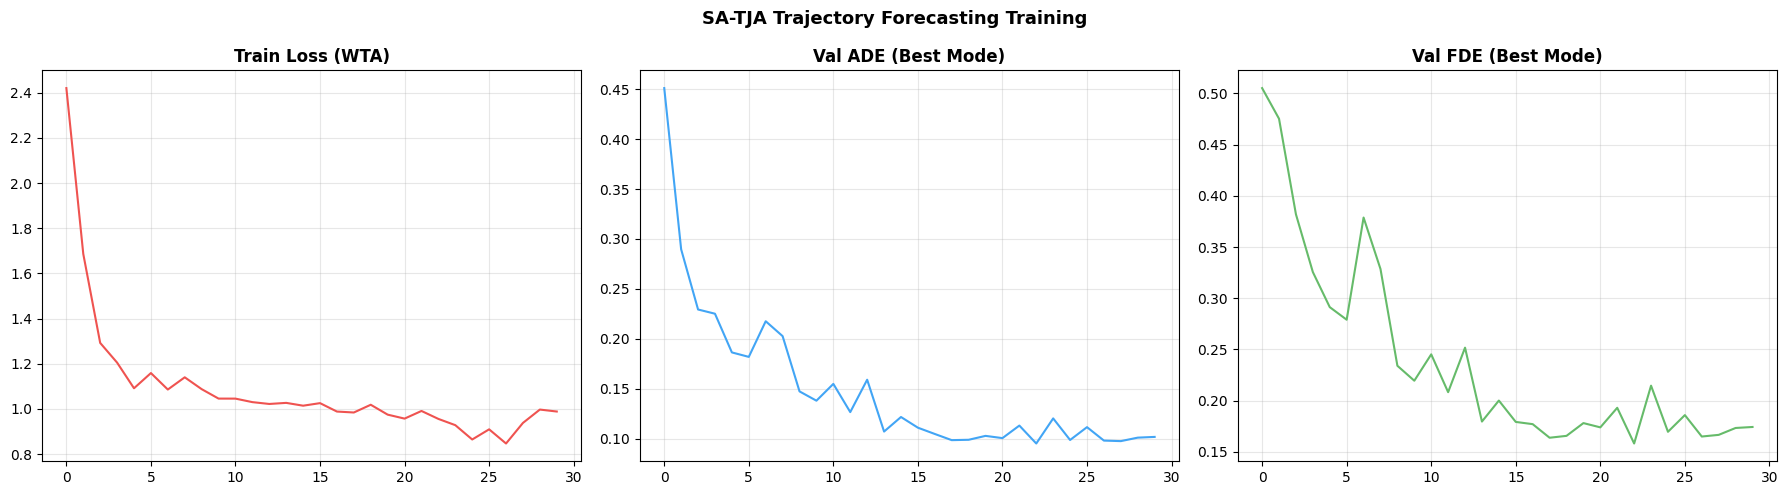

In [ ]:
#27
def wta_trajectory_loss(traj_preds,mode_probs,future_pos):
    B,K,T,_=traj_preds.shape
    gt_expanded=future_pos.unsqueeze(1).expand(-1,K,-1,-1)

    ade_per_mode=(((traj_preds-gt_expanded)**2).sum(dim=-1).sqrt().mean(dim=-1))

    best_mode_idx=ade_per_mode.argmin(dim=-1)
    best_ade=ade_per_mode[torch.arange(B),best_mode_idx]

    regression_loss=best_ade.mean()

    mode_loss=F.cross_entropy(mode_probs.log(),best_mode_idx)

    best_traj=traj_preds[torch.arange(B),best_mode_idx]

    fde=(((best_traj[:,-1]-future_pos[:,-1])**2).sum(dim=-1).sqrt().mean())

    total=regression_loss+0.5*mode_loss+0.3*fde

    return total,regression_loss.item(),fde.item()

def ade_in_pixels(ade_norm):
    """Convert normalized ADE back to pixel units."""
    return ade_norm * 200.0

def train_trajectory_model(model,train_loader,val_loader,n_epochs=30,lr=3e-4,device=DEVICE):
    optimizer=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)

    scheduler=optim.lr_scheduler.OneCycleLR(
        optimizer,max_lr=lr,epochs=n_epochs,steps_per_epoch=len(train_loader)
    )

    history={'train_loss':[],'val_ade':[],'val_fde':[]}

    best_val_ade=float('inf')

    for epoch in range(n_epochs):

        model.train()
        epoch_loss=0.0

        for obs_pos,obs_state,intent_probs,future_pos in train_loader:

            obs_pos=obs_pos.to(device)
            obs_state=obs_state.to(device)
            intent_probs=intent_probs.to(device)
            future_pos=future_pos.to(device)

            optimizer.zero_grad()

            traj_preds,mode_probs=model(obs_pos,obs_state,intent_probs)

            loss,_,_=wta_trajectory_loss(traj_preds,mode_probs,future_pos)

            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(),1.0)

            optimizer.step()
            scheduler.step()

            epoch_loss+=loss.item()

        model.eval()

        val_ade=0.0
        val_fde=0.0
        val_count=0

        with torch.no_grad():

            for obs_pos,obs_state,intent_probs,future_pos in val_loader:

                obs_pos=obs_pos.to(device)
                obs_state=obs_state.to(device)
                intent_probs=intent_probs.to(device)
                future_pos=future_pos.to(device)

                traj_preds,mode_probs=model(obs_pos,obs_state,intent_probs)

                B,K,T,_=traj_preds.shape

                gt_exp=future_pos.unsqueeze(1).expand(-1,K,-1,-1)

                ade_per_mode=(((traj_preds-gt_exp)**2).sum(-1).sqrt().mean(-1))

                best_idx=ade_per_mode.argmin(dim=-1)

                best_traj=traj_preds[torch.arange(B),best_idx]

                ade=(((traj_preds[torch.arange(B),best_idx]-future_pos)**2).sum(-1).sqrt().mean(-1).mean())

                fde=(((best_traj[:,-1]-future_pos[:,-1])**2).sum(-1).sqrt().mean())

                val_ade+=ade.item()*B
                val_fde+=fde.item()*B
                val_count+=B

        val_ade/=max(val_count,1)
        val_fde/=max(val_count,1)

        history['train_loss'].append(epoch_loss/len(train_loader))
        history['val_ade'].append(val_ade)
        history['val_fde'].append(val_fde)

        if val_ade<best_val_ade:
            best_val_ade=val_ade
            torch.save(model.state_dict(),BASE_DIR/'models'/'trajectory'/'traj_best.pt')

        if (epoch+1)%5==0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | Loss: {epoch_loss/len(train_loader):.4f} | Val ADE: {val_ade:.4f} | Val FDE: {val_fde:.4f}")

    model.load_state_dict(torch.load(BASE_DIR/'models'/'trajectory'/'traj_best.pt'))

    print(f"\n[SA-TJA] Trajectory model training complete. Best Val ADE: {best_val_ade:.4f}")

    return history


print("[SA-TJA] Training TrajectoryForecastNetwork...")

if len(traj_dataset)>50:
    traj_history=train_trajectory_model(traj_net,traj_loader_train,traj_loader_val,n_epochs=30,lr=3e-4)
else:
    traj_history=train_trajectory_model(traj_net,traj_loader_train,traj_loader_val,n_epochs=5,lr=3e-4)

fig,axes=plt.subplots(1,3,figsize=(18,5))

axes[0].plot(traj_history['train_loss'],color='#EF5350')
axes[0].set_title('Train Loss (WTA)',fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(traj_history['val_ade'],color='#42A5F5')
axes[1].set_title('Val ADE (Best Mode)',fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(traj_history['val_fde'],color='#66BB6A')
axes[2].set_title('Val FDE (Best Mode)',fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('SA-TJA Trajectory Forecasting Training',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'visualizations'/'traj_training.png',dpi=120,bbox_inches='tight')
plt.show()

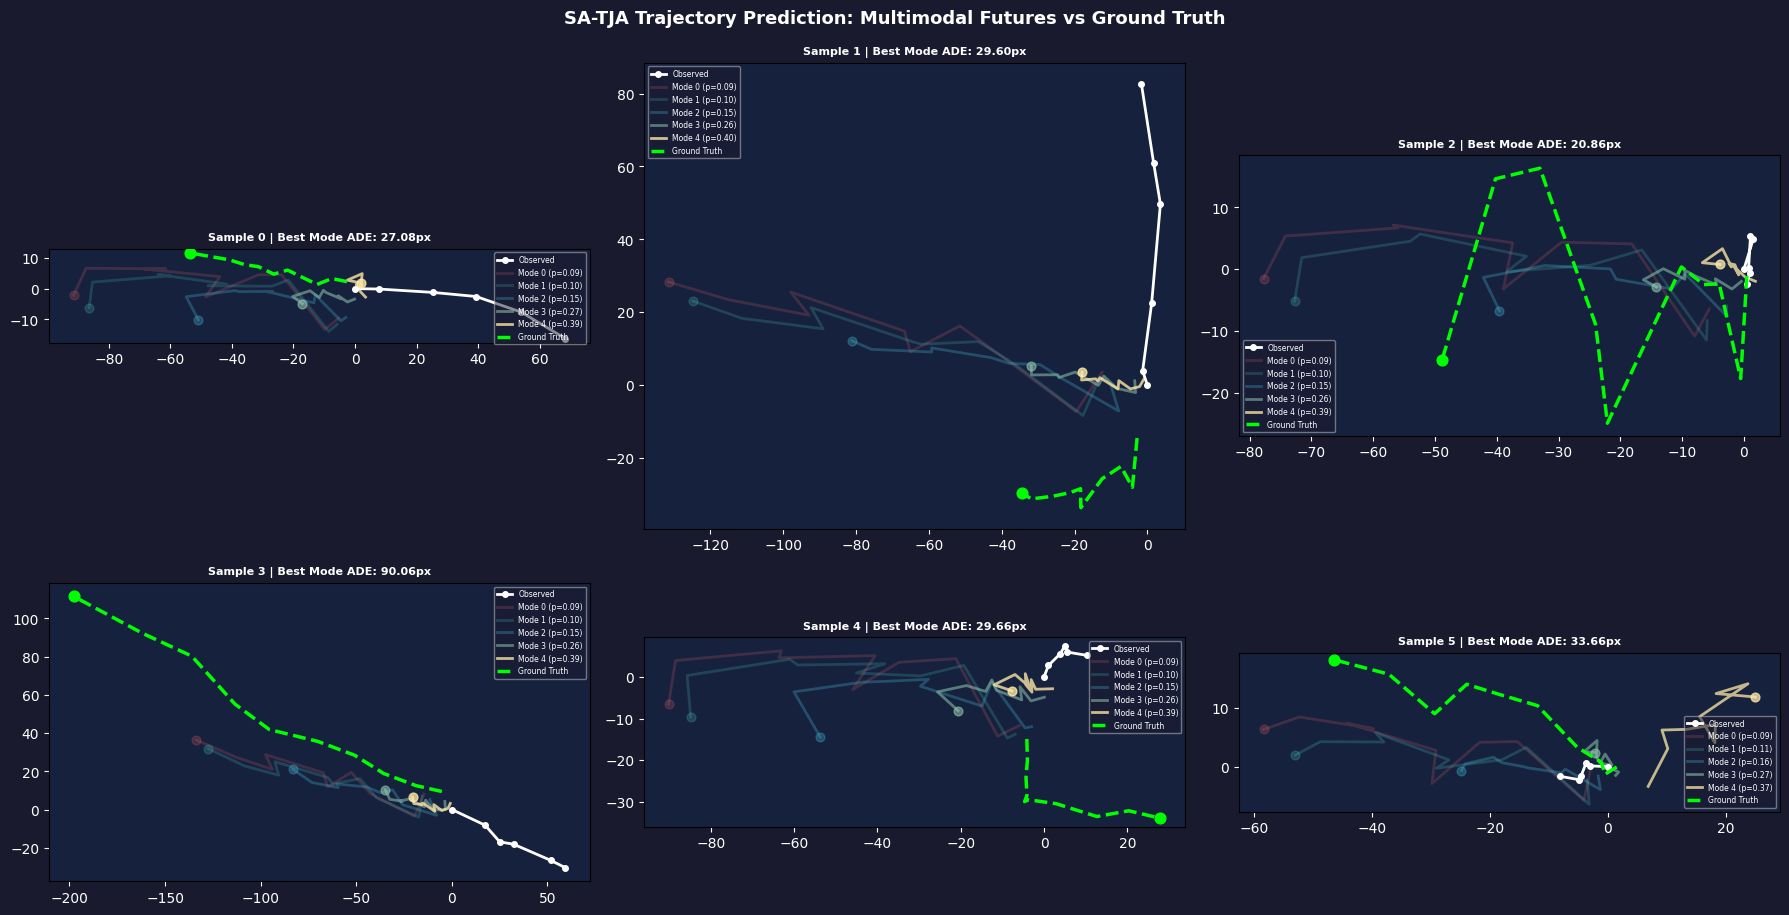

[SA-TJA] Trajectory prediction visualization complete.


In [ ]:
#28
traj_net.eval()

val_iter=iter(traj_loader_val)

obs_pos,obs_state,intent_probs,future_pos=next(val_iter)

obs_pos=obs_pos.to(DEVICE)
obs_state=obs_state.to(DEVICE)
intent_probs=intent_probs.to(DEVICE)

with torch.no_grad():
    traj_preds,mode_probs=traj_net(obs_pos,obs_state,intent_probs)

obs_np=obs_pos.cpu().numpy()*200.0
gt_np=future_pos.cpu().numpy()*200.0
pred_np=traj_preds.cpu().numpy()*200.0
mprob_np=mode_probs.cpu().numpy()

n_viz=min(6,len(obs_np))
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.patch.set_facecolor('#1A1A2E')
mode_colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
for i,ax in enumerate(axes.flat[:n_viz]):
    ax.set_facecolor('#16213E')
    obs_i=obs_np[i]
    gt_i=gt_np[i]
    pred_i=pred_np[i]
    probs_i=mprob_np[i]

    ax.plot(obs_i[:,0],obs_i[:,1],'w-o',lw=2,ms=4,label='Observed',zorder=3)

    for k in range(N_TRAJ_MODES):

        alpha=float(probs_i[k])*2.0
        alpha=np.clip(alpha,0.15,1.0)

        ax.plot(pred_i[k,:,0],pred_i[k,:,1],color=mode_colors[k],lw=2.0,alpha=alpha,label=f'Mode {k} (p={probs_i[k]:.2f})')
        ax.scatter([pred_i[k,-1,0]],[pred_i[k,-1,1]],color=mode_colors[k],s=40,alpha=alpha,zorder=4)
    ax.plot(gt_i[:,0],gt_i[:,1],'lime',lw=2.5,ls='--',ms=4,label='Ground Truth',zorder=5)

    ax.scatter([gt_i[-1,0]],[gt_i[-1,1]],color='lime',s=60,zorder=6)
    best_k=probs_i.argmax()
    ade=float(np.sqrt(((pred_i[best_k]-gt_i)**2).sum(axis=-1)).mean())
    ax.set_title(f'Sample {i} | Best Mode ADE: {ade:.2f}px',color='white',fontsize=8,fontweight='bold')
    ax.legend(fontsize=5.5,framealpha=0.5,facecolor='#1A1A2E',labelcolor='white')
    ax.set_aspect('equal')
    ax.tick_params(colors='white')

plt.suptitle('SA-TJA Trajectory Prediction: Multimodal Futures vs Ground Truth',color='white',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'visualizations'/'traj_pred_vs_actual.png',dpi=120,bbox_inches='tight',facecolor='#1A1A2E')
plt.show()
print("[SA-TJA] Trajectory prediction visualization complete.")

In [ ]:
#29
CHAOS_FEATURES=[
    'agent_density',
    'speed_variance',
    'acceleration_variance',
    'heading_variance',
    'approach_rate_mean',
    'near_conflict_count',
    'lateral_jerk_mean',
    'density_gradient',
    'interaction_edge_density',
    'intent_entropy_mean',
]

CHAOS_FEAT_DIM=len(CHAOS_FEATURES)

def extract_chaos_features(scene_graph:Dict,agent_states:Dict,agent_uncertainty:Dict)->np.ndarray:

    agents=scene_graph['agents']
    n=len(agents)

    if n==0:
        return np.zeros(CHAOS_FEAT_DIM,dtype=np.float32)

    centers=scene_graph['centers']
    tids=scene_graph['track_ids']

    states=[]

    for tid in tids:
        s=agent_states.get(tid,np.zeros(STATE_DIM))
        states.append(s[-1] if s.ndim==2 else s)

    states=np.array(states)

    area=1280.0*720.0
    density = n / area * 10000.0
    density_norm = np.clip(density / 2.0, 0, 1)

    speeds=states[:,8] if states.shape[1]>8 else np.zeros(n)
    speed_var=float(np.var(speeds)) if n>1 else 0.0

    ax_vals=states[:,4] if states.shape[1]>4 else np.zeros(n)
    ay_vals=states[:,5] if states.shape[1]>5 else np.zeros(n)

    acc_mag=np.sqrt(ax_vals**2+ay_vals**2)
    acc_var=float(np.var(acc_mag)) if n>1 else 0.0

    sin_h=states[:,6] if states.shape[1]>6 else np.zeros(n)
    cos_h=states[:,7] if states.shape[1]>7 else np.zeros(n)

    headings=np.arctan2(sin_h,cos_h)

    S=np.mean(np.sin(headings))
    C=np.mean(np.cos(headings))

    heading_var=float(1.0-np.sqrt(S**2+C**2))

    edge_feats=scene_graph['edge_features']

    if len(edge_feats)>0:
        approach_rate_mean=float(np.abs(edge_feats[:,5]).mean())
    else:
        approach_rate_mean=0.0

    dists=cdist(centers,centers)

    np.fill_diagonal(dists,np.inf)

    frame_diag = np.sqrt(1280**2 + 720**2)
    conflict_radius = frame_diag * 0.07
    near_conflicts = int(np.sum(dists < conflict_radius) / 2)
    near_conflict_norm = near_conflicts / max(n * (n-1) / 2, 1)

    lateral_jerk=float(np.mean(np.abs(ay_vals)))

    local_dens=scene_graph.get('densities',np.zeros(n))

    density_grad=float(np.std(local_dens))/max(np.mean(local_dens)+1,1)

    n_edges=scene_graph['edge_index'].shape[1] if scene_graph['edge_index'].ndim==2 else 0

    edge_density=n_edges/max(n,1)

    entropies=[agent_uncertainty.get(tid,{}).get('aleatoric',0.5) for tid in tids]

    entropy_mean=float(np.mean(entropies))

    feat=np.array([
        np.clip(density/5.0,0,1),
        np.clip(speed_var/0.5,0,1),
        np.clip(acc_var/0.3,0,1),
        np.clip(heading_var,0,1),
        np.clip(approach_rate_mean/2.0,0,1),
        np.clip(near_conflict_norm/3.0,0,1),
        np.clip(lateral_jerk/0.5,0,1),
        np.clip(density_grad,0,1),
        np.clip(edge_density/8.0,0,1),
        np.clip(entropy_mean,0,1),
    ],dtype=np.float32)

    return feat

In [ ]:
#30
print("[SA-TJA] Extracting chaos features from scene graphs...")

CHAOS_FEAT_DATA=[]


for sg in tqdm(SCENE_GRAPHS,desc='Chaos features'):
    feat=extract_chaos_features(sg,AGENT_STATES,AGENT_UNCERTAINTY)
    CHAOS_FEAT_DATA.append(feat)

CHAOS_FEAT_DATA=np.array(CHAOS_FEAT_DATA)

from sklearn.decomposition import PCA

pca=PCA(n_components=1)

def compute_calibrated_chaos_label(feat: np.ndarray) -> float:
    """
    Interpretable chaos score using domain-knowledge weights.
    Feature vector layout (CHAOS_FEATURES):
    [0] agent_density        [1] speed_variance
    [2] acceleration_variance [3] heading_variance
    [4] approach_rate_mean   [5] near_conflict_count
    [6] lateral_jerk_mean    [7] density_gradient
    [8] interaction_edge_density [9] intent_entropy_mean
    """
    weights = np.array([
        0.20,
        0.12,
        0.10,
        0.12,
        0.10,
        0.15,
        0.08,
        0.05,
        0.04,
        0.04,
    ], dtype=np.float32)
    raw = float(np.dot(weights, feat))
    return float(np.clip(raw * 100.0, 0.0, 100.0))

chaos_scores_calibrated = np.array(
    [compute_calibrated_chaos_label(f) for f in CHAOS_FEAT_DATA]
)

print(f"Calibrated chaos: min={chaos_scores_calibrated.min():.1f}, "
      f"max={chaos_scores_calibrated.max():.1f}, "
      f"mean={chaos_scores_calibrated.mean():.1f}, "
      f"std={chaos_scores_calibrated.std():.1f}")




class ChaosNet(nn.Module):
    def __init__(self,feat_dim=CHAOS_FEAT_DIM,dropout=0.15):
        super().__init__()

        self.net=nn.Sequential(
            nn.Linear(feat_dim,64),
            nn.GELU(),
            nn.LayerNorm(64),
            nn.Dropout(dropout),

            nn.Linear(64,128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Dropout(dropout),

            nn.Linear(128,64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64,32),
            nn.GELU(),

            nn.Linear(32,1),
            nn.Sigmoid(),
        )

    def forward(self,x):
        return self.net(x)*100.0


chaos_net=ChaosNet().to(DEVICE)


class ChaosDataset(Dataset):

    def __init__(self,features,scores):
        self.X=torch.tensor(features,dtype=torch.float32)
        self.y=torch.tensor(scores,dtype=torch.float32).unsqueeze(1)

    def __len__(self): return len(self.X)

    def __getitem__(self,i): return self.X[i],self.y[i]
chaos_ds = ChaosDataset(CHAOS_FEAT_DATA, chaos_scores_calibrated)

[SA-TJA] Extracting chaos features from scene graphs...


Chaos features: 100%|██████████| 100/100 [00:00<00:00, 1976.93it/s]


Calibrated chaos: min=8.2, max=56.4, mean=43.7, std=14.1


In [ ]:
#31
chaos_ds=ChaosDataset(CHAOS_FEAT_DATA,chaos_scores_calibrated)
n_c_train=int(0.8*len(chaos_ds))
c_train,c_val=random_split(chaos_ds,[n_c_train,len(chaos_ds)-n_c_train])
c_loader_tr=DataLoader(c_train,batch_size=32,shuffle=True)
c_loader_val=DataLoader(c_val,batch_size=32)
optim_c=optim.Adam(chaos_net.parameters(),lr=3e-3)
criterion_c=nn.MSELoss()
chaos_train_losses=[]
for epoch in range(50):
    chaos_net.train()
    epoch_loss=0
    for xb,yb in c_loader_tr:
        xb=xb.to(DEVICE)
        yb=yb.to(DEVICE)
        optim_c.zero_grad()
        pred=chaos_net(xb)
        loss=criterion_c(pred,yb)
        loss.backward()
        optim_c.step()
        epoch_loss+=loss.item()
    chaos_train_losses.append(epoch_loss)
chaos_net.eval()

preds_chaos=[]
gt_chaos=[]
with torch.no_grad():
    for xb,yb in c_loader_val:
        pred=chaos_net(xb.to(DEVICE)).cpu().numpy()
        preds_chaos.extend(pred.flatten())
        gt_chaos.extend(yb.numpy().flatten())
rmse=np.sqrt(mean_squared_error(gt_chaos,preds_chaos))
torch.save(chaos_net.state_dict(),BASE_DIR/'models'/'chaos'/'chaos_best.pt')
print(f"\n[SA-TJA] Chaos model trained. Val RMSE: {rmse:.3f}")
chaos_net.eval()
with torch.no_grad():
    all_chaos=chaos_net(torch.tensor(CHAOS_FEAT_DATA).to(DEVICE)).cpu().numpy().flatten()
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].plot(all_chaos,color='#FF6B35',lw=1.5,alpha=0.8)
axes[0].fill_between(range(len(all_chaos)),all_chaos,alpha=0.2,color='#FF6B35')
axes[0].set_title('Learned Chaos Score Over Time',fontweight='bold')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Chaos Score (0-100)')
axes[0].grid(alpha=0.3)
axes[1].scatter(gt_chaos,preds_chaos,alpha=0.5,s=15,color='#4FC3F7')
lim_min=min(min(gt_chaos),min(preds_chaos))
lim_max=max(max(gt_chaos),max(preds_chaos))
axes[1].plot([lim_min,lim_max],[lim_min,lim_max],'r--')
axes[1].set_title(f'Chaos Prediction vs Ground Truth (RMSE={rmse:.2f})',fontweight='bold')
axes[1].set_xlabel('Pseudo GT Chaos')
axes[1].set_ylabel('Predicted Chaos')
axes[1].grid(alpha=0.3)
plt.suptitle('SA-TJA Traffic Chaos Model',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'visualizations'/'chaos_model.png',dpi=120,bbox_inches='tight')
plt.show()
FRAME_CHAOS_SCORES=all_chaos
print(f"[SA-TJA] Chaos scores computed for {len(FRAME_CHAOS_SCORES)} frames.")

In [ ]:
#32
GAP_FEATURES=[
    'gap_distance',
    'ego_speed',
    'other_speed',
    'closing_speed',
    'other_class_id',
    'local_density',
    'chaos_score',
    'ego_intent_entropy',
    'other_intent_max',
    'lat_offset',
    'gap_width',
    'time_pressure',
]

GAP_FEAT_DIM=len(GAP_FEATURES)
def generate_gap_dataset(tracked_sequences,scene_graphs,agent_states,agent_uncertainty,chaos_scores,n_gaps_per_frame:int=5)->List[Dict]:
    samples=[]
    for frame_idx in range(min(len(tracked_sequences)-1,len(scene_graphs))):
        frame=tracked_sequences[frame_idx]
        next_frame=tracked_sequences[frame_idx+1]
        if not frame or not next_frame: continue
        sg=scene_graphs[frame_idx]
        current_chaos=chaos_scores[frame_idx] if frame_idx<len(chaos_scores) else 50.0
        centers=sg['centers']
        dists=cdist(centers,centers)
        np.fill_diagonal(dists,np.inf)

        for i,agent_i in enumerate(frame[:n_gaps_per_frame]):

            tid_i=agent_i['track_id']

            state_i=agent_states.get(tid_i,np.zeros(STATE_DIM))

            if state_i.ndim==2: state_i=state_i[-1]

            unc_i=agent_uncertainty.get(tid_i,{})
            ego_speed=float(state_i[8]) if len(state_i)>8 else 0.0
            ego_entropy=float(unc_i.get('aleatoric',0.5))
            if len(dists)<=i: continue
            row=dists[i]
            sorted_neighbors=np.argsort(row)
            sorted_neighbors=sorted_neighbors[sorted_neighbors!=i]
            if len(sorted_neighbors)==0: continue
            j=sorted_neighbors[0]
            if j>=len(frame): continue
            agent_j=frame[j]
            tid_j=agent_j['track_id']
            state_j=agent_states.get(tid_j,np.zeros(STATE_DIM))
            if state_j.ndim==2: state_j=state_j[-1]

            other_speed=float(state_j[8]) if len(state_j)>8 else 0.0

            other_intent=agent_uncertainty.get(tid_j,{}).get('max_prob',0.5)
            gap_dist=float(dists[i,j])
            closing_speed=ego_speed-other_speed

            cx_i,cy_i=agent_i['center']
            cx_j,cy_j=agent_j['center']
            lat_offset=(cx_j-cx_i)/200.0
            local_dens=float(sg['densities'][i])/10.0 if i<len(sg['densities']) else 0.5
            w_j=agent_j.get('bbox',[0,0,100,100])
            gap_width=max(0,gap_dist-(w_j[2]-w_j[0]))
            next_agent_i=next((a for a in next_frame if a['track_id']==tid_i),None)
            if next_agent_i:
                dx_move=next_agent_i['center'][0]-cx_i
                dy_move=next_agent_i['center'][1]-cy_i

                gap_vec=np.array([cx_j-cx_i,cy_j-cy_i])
                gap_unit=gap_vec/(np.linalg.norm(gap_vec)+1e-6)
                move_toward=np.dot([dx_move,dy_move],gap_unit)
                label=1 if move_toward>2.0 else 0
            else:
                label=0
            feat=np.array([
                np.clip(gap_dist/300.0,0,1),
                np.clip(ego_speed,0,1),
                np.clip(other_speed,0,1),
                np.clip(closing_speed/0.5+0.5,0,1),
                agent_j['class_id']/6.0,
                np.clip(local_dens,0,1),
                float(current_chaos)/100.0,
                np.clip(ego_entropy,0,1),
                np.clip(other_intent,0,1),
                np.clip(lat_offset+0.5,0,1),
                np.clip(gap_width/200.0,0,1),
                0.5,],dtype=np.float32)

            samples.append({'features':feat,'label':label})
    return samples

In [ ]:
#33
print("[SA-TJA] Generating gap acceptance dataset...")
gap_samples=generate_gap_dataset(
    TRACKED_SEQUENCES,
    SCENE_GRAPHS,
    AGENT_STATES,
    AGENT_UNCERTAINTY,
    FRAME_CHAOS_SCORES,
    n_gaps_per_frame=8)
print(f"  Gap samples: {len(gap_samples)}")
n_accepted=sum(s['label'] for s in gap_samples)
print(f"  Accepted: {n_accepted} ({100*n_accepted/max(len(gap_samples),1):.1f}%)")
print(f"  Rejected: {len(gap_samples)-n_accepted} ({100*(len(gap_samples)-n_accepted)/max(len(gap_samples),1):.1f}%)")

In [ ]:
#34
class GapAcceptanceNet(nn.Module):
    def __init__(self,feat_dim=GAP_FEAT_DIM,dropout=0.15):
        super().__init__()

        self.net=nn.Sequential(
            nn.Linear(feat_dim,128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Dropout(dropout),

            nn.Linear(128,256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout),
            nn.Linear(256,128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128,64),
            nn.GELU(),
            nn.Linear(64,1),
        )
    def forward(self,x):
        return self.net(x)


class GapDataset(Dataset):
    def __init__(self,samples):
        self.X=torch.tensor(np.array([s['features'] for s in samples]),dtype=torch.float32)
        self.y=torch.tensor(np.array([s['label'] for s in samples]),dtype=torch.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.y[i]
gap_net=GapAcceptanceNet().to(DEVICE)

In [ ]:
#35
if gap_samples:
    gap_ds=GapDataset(gap_samples)
    n_g_tr=int(0.8*len(gap_ds))
    g_tr,g_val=random_split(gap_ds,[n_g_tr,len(gap_ds)-n_g_tr])
    g_loader_tr=DataLoader(g_tr,batch_size=64,shuffle=True)
    g_loader_val=DataLoader(g_val,batch_size=64)
    optim_g=optim.AdamW(gap_net.parameters(),lr=3e-4,weight_decay=1e-4)
    scheduler_g=optim.lr_scheduler.StepLR(optim_g,step_size=15,gamma=0.5)
    crit_g=nn.BCEWithLogitsLoss()
    for epoch in range(40):
        gap_net.train()
        for xb,yb in g_loader_tr:
            xb=xb.to(DEVICE)
            yb=yb.to(DEVICE).unsqueeze(1)
            optim_g.zero_grad()
            loss=crit_g(gap_net(xb),yb)
            loss.backward()
            optim_g.step()
        scheduler_g.step()
    gap_net.eval()
    correct=0
    total=0
    with torch.no_grad():
        for xb,yb in g_loader_val:
            logits=gap_net(xb.to(DEVICE)).cpu()
            preds=(torch.sigmoid(logits)>0.5).float().squeeze()
            correct+=(preds==yb).sum().item()
            total+=len(yb)
    acc=correct/max(total,1)
    torch.save(gap_net.state_dict(),BASE_DIR/'models'/'gap_acceptance'/'gap_best.pt')
    print(f"[SA-TJA] Gap acceptance model trained. Val Acc: {acc:.3f}")
    print(f"  Model replaces all fixed following distances.")
    print(f"  P(accept_gap) now depends on: velocity, density, class, chaos, intent...")
else:
    print("[SA-TJA] No gap samples generated. Check sequence length.")

In [ ]:
#36
TSI_INPUT_DIM=12

def extract_tsi_features(scene_graph, agent_states, agent_uncertainty,
                         chaos_score, gap_accept_prob,
                         traj_conflicts=0.0):
    agents=scene_graph['agents']
    n=max(len(agents),1)
    tids=scene_graph['track_ids']
    states=[]
    for tid in tids:
        s=agent_states.get(tid,np.zeros(STATE_DIM))
        states.append(s[-1] if s.ndim==2 else s)

    if not states:
        return np.zeros(TSI_INPUT_DIM,dtype=np.float32)
    states=np.array(states)

    if states.shape[1]>5:
        acc_y=states[:,5]
        braking_demand=float(np.mean(np.maximum(-acc_y,0)))
    else:
        braking_demand=0.0

    if states.shape[1]>4:
        acc_x=states[:,4]
        accel_demand=float(np.mean(np.maximum(acc_x,0)))
    else:
        accel_demand=0.0

    if states.shape[1]>9:
        mean_jerk=float(np.mean(states[:,9]))
    else:
        mean_jerk=0.0

    uncertainties=[agent_uncertainty.get(tid,{}).get('predictive',0.5) for tid in tids]
    mean_uncertainty=float(np.mean(uncertainties))
    max_uncertainty=float(np.max(uncertainties))
    n_edges=scene_graph['edge_index'].shape[1] if scene_graph['edge_index'].ndim==2 else 0
    interaction_complexity=n_edges/max(n,1)/8.0
    pred_confidence=1.0-mean_uncertainty
    feat=np.array([
        chaos_score/100.0,
        mean_uncertainty,
        max_uncertainty,
        interaction_complexity,
        np.clip(gap_accept_prob,0,1),
        np.clip(traj_conflicts,0,1),
        np.clip(braking_demand,0,1),
        np.clip(accel_demand,0,1),
        np.clip(mean_jerk,0,1),
        pred_confidence,
        n/50.0,
        float(n>20)*0.5+float(n>35)*0.5,
    ],dtype=np.float32)
    return feat

class TSINet(nn.Module):
    def __init__(self,input_dim=TSI_INPUT_DIM,dropout=0.15):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,64),
            nn.GELU(),
            nn.LayerNorm(64),
            nn.Dropout(dropout),
            nn.Linear(64,128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Dropout(dropout),
            nn.Linear(128,64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64,32),
            nn.GELU(),
            nn.Linear(32,1),
            nn.Sigmoid(),
        )
    def forward(self,x):
        return self.net(x)*100.0
tsi_net=TSINet().to(DEVICE)
print("[SA-TJA] Building TSI dataset...")
tsi_features_list=[]
tsi_pseudo_labels=[]
gap_net.eval()
for frame_idx,sg in enumerate(tqdm(SCENE_GRAPHS,desc='TSI features')):
    chaos=float(FRAME_CHAOS_SCORES[frame_idx]) if frame_idx<len(FRAME_CHAOS_SCORES) else 50.0
    if gap_samples and frame_idx<len(gap_samples):
        gf=torch.tensor(gap_samples[min(frame_idx,len(gap_samples)-1)]['features']).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            gap_p=float(torch.sigmoid(gap_net(gf)).cpu().item())
    else:
        gap_p=0.5
    agents=sg['agents']
    n=len(agents)
    if n>1:
        centers=sg['centers']
        dists=cdist(centers,centers)
        np.fill_diagonal(dists,np.inf)
        traj_conflict=float(np.sum(dists<60.0)/max(n*(n-1),1))
    else:
        traj_conflict=0.0
    feat=extract_tsi_features(sg,AGENT_STATES,AGENT_UNCERTAINTY,chaos,gap_p,traj_conflict)
    tsi_features_list.append(feat)
    pseudo_tsi = (
      0.35 * chaos_scores_calibrated[frame_idx] +
      0.20 * float(feat[1]) * 100 +
      0.20 * traj_conflict * 100 +
      0.15 * float(feat[5]) * 100 +
      0.10 * float(feat[3]) * 100
    )
    pseudo_tsi = np.clip(pseudo_tsi, 0, 100)
    tsi_pseudo_labels.append(pseudo_tsi)
    tsi_features_arr=np.array(tsi_features_list)
    tsi_labels_arr=np.array(tsi_pseudo_labels)

class TSIDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.y[i]
tsi_ds=TSIDataset(tsi_features_arr,tsi_labels_arr)
n_tsi_tr=int(0.8*len(tsi_ds))
tsi_tr,tsi_v=random_split(tsi_ds,[n_tsi_tr,len(tsi_ds)-n_tsi_tr])
tsi_ldr_tr=DataLoader(tsi_tr,batch_size=32,shuffle=True)
tsi_ldr_val=DataLoader(tsi_v,batch_size=32)

In [ ]:
#37
optim_tsi = optim.Adam(tsi_net.parameters(),lr=3e-3)
crit_tsi = nn.MSELoss()
for epoch in range(60):
    tsi_net.train()
    for xb, yb in tsi_ldr_tr:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optim_tsi.zero_grad()
        loss = crit_tsi(tsi_net(xb),yb)
        loss.backward()
        optim_tsi.step()


tsi_net.eval()
tsi_preds = []
tsi_gt = []

with torch.no_grad():
    for xb, yb in tsi_ldr_val:
        tsi_preds.extend(tsi_net(xb.to(DEVICE)).cpu().numpy().flatten())
        tsi_gt.extend(yb.numpy().flatten())

tsi_rmse = np.sqrt(mean_squared_error(tsi_gt,tsi_preds))
torch.save(tsi_net.state_dict(),BASE_DIR / 'models' / 'tsi' / 'tsi_best.pt')

print(f"[SA-TJA] TSI model trained. "f"Val RMSE: {tsi_rmse:.3f}")


tsi_net.eval()
with torch.no_grad():
    FRAME_TSI = tsi_net(torch.tensor(tsi_features_arr).to(DEVICE)).cpu().numpy().flatten()
    fig, axes = plt.subplots(1,2,figsize=(16, 5))

axes[0].plot(FRAME_TSI,color='#AB47BC',lw=1.5)
axes[0].plot(FRAME_CHAOS_SCORES[:len(FRAME_TSI)],color='#FF6B35',lw=1.5,alpha=0.6,ls='--')
axes[0].set_title('TSI vs Chaos Score Over Time',fontweight='bold')
axes[0].legend(['TSI (learned)', 'Chaos Score'],loc='upper right')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Score (0-100)')
axes[0].grid(alpha=0.3)

axes[1].scatter(tsi_gt,tsi_preds,alpha=0.5,s=15,color='#AB47BC')
lm = min(tsi_gt + tsi_preds)
lM = max(tsi_gt + tsi_preds)
axes[1].plot([lm, lM],[lm, lM],'r--')
axes[1].set_title(f'TSI Prediction Fit (RMSE={tsi_rmse:.2f})',fontweight='bold')
axes[1].set_xlabel('GT TSI')
axes[1].set_ylabel('Predicted TSI')
axes[1].grid(alpha=0.3)

plt.suptitle('SA-TJA Traffic Stress Index (Learned)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'tsi_model.png',dpi=120,bbox_inches='tight')
plt.show()

print(
    f"[SA-TJA] TSI range: "
    f"[{FRAME_TSI.min():.1f}, "
    f"{FRAME_TSI.max():.1f}], "
    f"mean={FRAME_TSI.mean():.1f}"
)

In [ ]:
#38
EGO_ACTIONS = [
    'maintain_speed',
    'accelerate',
    'decelerate',
    'stop',
    'shift_left',
    'shift_right',
    'merge_left',
    'merge_right',
    'overtake',
    'yield',]
N_ACTIONS = len(EGO_ACTIONS)
print(f"[SA-TJA] Ego action space: "f"{N_ACTIONS} actions")
for i, a in enumerate(EGO_ACTIONS):
    print(f"  [{i:2d}] {a}")

In [ ]:
#39
STRESS_COST_INPUT_DIM = (TSI_INPUT_DIM+ N_ACTIONS+ 4)
class StressCostNet(nn.Module):
    """
    Predicts future stress cost of taking an action
    in a given scene context.

    Learned from:
      - Braking frequency under that action
      - Acceleration demand
      - Jerk induced
      - Near-conflict exposure
      - Chaos and uncertainty after action

    Output:
      Stress cost in [0, 1]
    """

    def __init__(self,input_dim=STRESS_COST_INPUT_DIM,dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.GELU(),
            nn.LayerNorm(128),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1),
            nn.Sigmoid(),)

    def forward(self,tsi_feat,action_onehot,extra_feat):
        x = torch.cat([tsi_feat,action_onehot,extra_feat],dim=-1)
        return self.net(x)
stress_cost_net = StressCostNet().to(DEVICE)

In [ ]:
#40
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split

In [ ]:
#41
POLICY_INPUT_DIM = TSI_INPUT_DIM + N_INTENTS + 4

class StressAwarePolicyNet(nn.Module):
    """
    Stress-Aware Policy Network.

    Input : scene_context (TSI features) + predicted ego intent probs
            + extra scalars [chaos, uncertainty, gap_prob, traj_conflict]
    Output: logits over N_ACTIONS ego actions

    Trained via imitation of the min-stress action selected by StressCostNet,
    then optionally fine-tuned with policy gradient (REINFORCE).

    This replaces ALL hardcoded action selection logic.
    No fixed costs, no rule-based if-else planners.
    """
    def __init__(self, input_dim=POLICY_INPUT_DIM, d_model=256,
                 n_actions=N_ACTIONS, dropout=0.15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
        )
        self.action_head = nn.Linear(d_model // 2, n_actions)
        self.value_head  = nn.Linear(d_model // 2, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x : (B, POLICY_INPUT_DIM)
        returns action_logits (B, N_ACTIONS), state_value (B, 1)
        """
        h = self.encoder(x)
        return self.action_head(h), self.value_head(h)

    def act(self, x, deterministic=False):
        """Sample or argmax action from policy."""
        logits, value = self.forward(x)
        probs = F.softmax(logits, dim=-1)
        if deterministic:
            action = probs.argmax(dim=-1)
        else:
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()
        return action, probs, value


policy_net = StressAwarePolicyNet(
    input_dim=POLICY_INPUT_DIM,
    d_model=256,
    n_actions=N_ACTIONS,
    dropout=0.15
).to(DEVICE)

n_policy_params = sum(p.numel() for p in policy_net.parameters() if p.requires_grad)
print(f"[SA-TJA] StressAwarePolicyNet initialized.")
print(f"  Parameters : {n_policy_params:,}")
print(f"  Input dim  : {POLICY_INPUT_DIM}  (TSI={TSI_INPUT_DIM} + intents={N_INTENTS} + extra=4)")
print(f"  Output     : {N_ACTIONS} action logits + 1 state value")



In [ ]:
#42
def build_policy_dataset(tsi_feats, chaos_scores, agent_intent_probs,
                         stress_cost_net, tsi_net):
    """
    FIXED: Generate imitation learning dataset.
    Uses fixed stress cost model → diverse expert actions.
    Adds a diversity check to warn if action distribution is still collapsed.
    """
    stress_cost_net.eval()
    samples = []

    for t, feat in enumerate(tsi_feats):
        chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0

        if agent_intent_probs:
            all_probs   = np.stack(list(agent_intent_probs.values()))
            scene_intent = all_probs.mean(axis=0)
        else:
            scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

        extra = np.array([
            chaos / 100.0,
            float(feat[1]),
            float(feat[3]),
            float(feat[7]),
        ], dtype=np.float32)

        policy_input = np.concatenate([feat, scene_intent, extra])

        feat_t = torch.tensor(feat,  dtype=torch.float32).unsqueeze(0).to(DEVICE)
        ext_t  = torch.tensor(extra, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        action_costs = []
        with torch.no_grad():
            for a in range(N_ACTIONS):
                aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
                aoh[0, a] = 1.0
                cost = stress_cost_net(feat_t, aoh, ext_t).item()
                action_costs.append(cost)

        progress_bonus = np.array([
            0.08,  # maintain_speed
            0.06,  # accelerate
            0.02,  # decelerate
           -0.05,  # stop
            0.05,  # shift_left
            0.05,  # shift_right
            0.04,  # merge_left
            0.04,  # merge_right
            0.03,  # overtake
            0.01,  # yield
        ], dtype=np.float32)

        adjusted = np.array(action_costs) - progress_bonus
        best_action = int(np.argmin(adjusted))

        samples.append({
            'policy_input': policy_input.astype(np.float32),
            'best_action':  best_action,
            'action_costs': np.array(action_costs, dtype=np.float32),
        })

    action_dist = defaultdict(int)
    for s in samples:
        action_dist[EGO_ACTIONS[s['best_action']]] += 1
    n_unique = len(action_dist)
    diversity = n_unique / N_ACTIONS

    print(f"  IL samples: {len(samples)}")
    print(f"  Action diversity: {diversity:.2f}  ({'✓ GOOD' if diversity >= 0.3 else '✗ LOW — stress cost bug still active'})")
    print(f"  Expert action distribution:")
    for a, cnt in sorted(action_dist.items(), key=lambda x: -x[1]):
        bar = "█" * int(30 * cnt / len(samples))
        print(f"    {a:20s} {bar} {cnt} ({100*cnt/len(samples):.1f}%)")

    if diversity < 0.3:
        print("\n  ⚠  LOW DIVERSITY: The stress cost fix (FIX 5) may not have been applied.")
        print("     Re-run generate_stress_cost_data() and retrain StressCostNet first.")

    return samples


print("[SA-TJA] Building imitation learning dataset from StressCostNet expert...")
il_samples = build_policy_dataset(
    tsi_features_arr,
    FRAME_CHAOS_SCORES,
    AGENT_INTENT_PROBS,
    stress_cost_net,
    tsi_net
)

action_dist = {}
for s in il_samples:
    a = EGO_ACTIONS[s['best_action']]
    action_dist[a] = action_dist.get(a, 0) + 1
print(f"  IL samples: {len(il_samples)}")
print(f"  Expert action distribution:")
for a, cnt in sorted(action_dist.items(), key=lambda x: -x[1]):
    print(f"    {a:20s}: {cnt:4d} ({100*cnt/len(il_samples):.1f}%)")


class PolicyILDataset(Dataset):
    def __init__(self, samples):
        self.X  = torch.tensor(np.array([s['policy_input'] for s in samples]),  dtype=torch.float32)
        self.y  = torch.tensor(np.array([s['best_action']  for s in samples]),  dtype=torch.long)
        self.ac = torch.tensor(np.array([s['action_costs'] for s in samples]),  dtype=torch.float32)

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i], self.ac[i]


il_ds = PolicyILDataset(il_samples)
n_il_tr = int(0.8 * len(il_ds))
il_tr, il_val = random_split(il_ds, [n_il_tr, len(il_ds) - n_il_tr])
il_ldr_tr  = DataLoader(il_tr,  batch_size=32, shuffle=True)
il_ldr_val = DataLoader(il_val, batch_size=32, shuffle=False)


def train_policy_imitation(model, train_loader, val_loader,
                           n_epochs=60, lr=3e-4, device=DEVICE):
    """
    Phase 1 — Imitation Learning (Behavioural Cloning).
    Policy learns to replicate min-stress expert demonstrations.
    Loss = CrossEntropy(policy_logits, expert_action)
         + 0.3 * cost_ranking_loss  (soft ordering over action costs)
    """
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr/20)
    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb, costs in train_loader:
            xb, yb, costs = xb.to(device), yb.to(device), costs.to(device)
            optimizer.zero_grad()

            logits, _ = model(xb)
            ce = ce_loss_fn(logits, yb)

            probs = F.softmax(logits, dim=-1)
            cost_rank_loss = (probs * costs).sum(dim=-1).mean()

            loss = ce + 0.3 * cost_rank_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(yb)

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                logits, _ = model(xb.to(device))
                preds = logits.argmax(dim=-1).cpu()
                correct += (preds == yb).sum().item()
                total   += len(yb)

        val_acc = correct / max(total, 1)
        history['train_loss'].append(epoch_loss / len(train_loader.dataset))
        history['val_acc'].append(val_acc)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(),
                       BASE_DIR / 'models' / 'planner' / 'policy_il_best.pt')

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Loss: {epoch_loss/len(train_loader.dataset):.4f} | "
                  f"Val Acc: {val_acc:.3f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    model.load_state_dict(
        torch.load(BASE_DIR / 'models' / 'planner' / 'policy_il_best.pt'))
    print(f"\n[SA-TJA] Policy IL training complete. Best Val Acc: {best_val_acc:.3f}")
    return history


print("\n[SA-TJA] Training Policy Network (Imitation Learning Phase)...")
policy_il_history = train_policy_imitation(
    policy_net, il_ldr_tr, il_ldr_val,
    n_epochs=60, lr=3e-4
)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(policy_il_history['train_loss'], color='#EF5350')
axes[0].set_title('Policy IL — Training Loss', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(policy_il_history['val_acc'], color='#66BB6A', lw=2)
axes[1].set_title('Policy IL — Validation Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.suptitle('SA-TJA Stress-Aware Policy: Imitation Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'policy_il_training.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("[SA-TJA] Policy imitation learning complete.")

def compute_reinforce_reward(action_id, tsi_score, chaos_score,
                              conflict_prob, uncertainty,
                              n_agents=3):
    """
    FIXED reward function.

    Reward = progress_reward - stress_penalty

    progress_reward: positive for actions that keep traffic moving
    stress_penalty:  scaled by actual scene chaos (not fixed threshold)

    Scene-adaptive: in empty scenes, maintain/accelerate get positive reward.
    In dense scenes, decelerate/yield get positive reward.
    """
    action_name = EGO_ACTIONS[action_id]
    chaos_norm  = chaos_score / 100.0
    tsi_norm    = tsi_score   / 100.0
    density_est = min(n_agents / 10.0, 1.0)

    progress = {
        'maintain_speed': 0.40,
        'accelerate':     0.50,
        'decelerate':     0.20,
        'stop':           0.05,
        'shift_left':     0.30,
        'shift_right':    0.30,
        'merge_left':     0.35,
        'merge_right':    0.35,
        'overtake':       0.45,
        'yield':          0.15,
    }[action_name]
    if chaos_norm > 0.5:
        conservative_bonus = {
            'decelerate': +0.30,
            'stop':       +0.20,
            'yield':      +0.25,
            'maintain_speed': 0.0,
            'accelerate': -0.20,
            'overtake':   -0.30,
        }.get(action_name, 0.0)
    elif chaos_norm < 0.25:
        conservative_bonus = {
            'maintain_speed': +0.20,
            'accelerate':     +0.15,
            'decelerate':     -0.10,
            'stop':           -0.20,
            'yield':          -0.10,
        }.get(action_name, 0.0)
    else:
        conservative_bonus = 0.0

    conflict_penalty = conflict_prob * chaos_norm * {
        'maintain_speed': 0.30,
        'accelerate':     0.45,
        'decelerate':     0.10,
        'stop':           0.05,
        'shift_left':     0.35,
        'shift_right':    0.32,
        'merge_left':     0.40,
        'merge_right':    0.38,
        'overtake':       0.50,
        'yield':          0.08,
    }[action_name]

    reward = progress + conservative_bonus - tsi_norm * 0.3 - conflict_penalty
    return float(np.clip(reward, -1.0, 1.0))
def reinforce_finetune(model, tsi_feats, chaos_scores,
                       agent_intent_probs, n_episodes=50,
                       lr_pg=1e-5, gamma=0.95, device=DEVICE):
    """
    REINFORCE with baseline for policy gradient fine-tuning.
    Episodes = sequences through the frame buffer.
    """
    optimizer_pg = optim.Adam(model.parameters(), lr=lr_pg)
    pg_rewards = []

    for episode in range(n_episodes):
        log_probs_ep = []
        rewards_ep   = []
        values_ep    = []

        start = np.random.randint(0, max(1, len(tsi_feats) - 10))
        ep_frames = range(start, min(start + 10, len(tsi_feats)))

        for t in ep_frames:
            feat  = tsi_feats[t]
            chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0

            if agent_intent_probs:
                all_p = np.stack(list(agent_intent_probs.values()))
                scene_intent = all_p.mean(axis=0)
            else:
                scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

            uncertainty = float(feat[1])
            extra = np.array([chaos / 100.0, uncertainty, feat[3], feat[7]], dtype=np.float32)

            policy_input = np.concatenate([feat, scene_intent, extra])
            x = torch.tensor(policy_input, dtype=torch.float32).unsqueeze(0).to(device)

            model.train()
            action, probs, value = model.act(x, deterministic=False)
            action_id = action.item()

            log_prob = torch.log(probs[0, action_id] + 1e-8)
            log_probs_ep.append(log_prob)
            values_ep.append(value.squeeze())

            reward = compute_reinforce_reward(
                action_id,
                float(feat[0]) * 100,
                chaos,
                float(feat[4]),
                float(feat[1])
            )
            rewards_ep.append(reward)

        G = 0.0
        returns = []
        for r in reversed(rewards_ep):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_loss = 0.0
        value_loss  = 0.0
        for lp, ret, val in zip(log_probs_ep, returns, values_ep):
            advantage  = ret - val.detach()
            policy_loss += -lp * advantage
            value_loss  += F.mse_loss(val, ret)

        total_pg_loss = policy_loss + 0.5 * value_loss

        optimizer_pg.zero_grad()
        total_pg_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer_pg.step()

        ep_reward = float(np.mean(rewards_ep))
        pg_rewards.append(ep_reward)

        if (episode + 1) % 10 == 0:
            print(f"  REINFORCE Episode {episode+1:3d}/{n_episodes} | "
                  f"Mean Reward: {np.mean(pg_rewards[-10:]):.4f}")

    torch.save(model.state_dict(),
               BASE_DIR / 'models' / 'planner' / 'policy_rl_best.pt')
    print(f"\n[SA-TJA] REINFORCE fine-tuning complete.")
    print(f"  Final mean reward: {np.mean(pg_rewards[-10:]):.4f}")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pg_rewards, alpha=0.5, color='#42A5F5', label='Episode Reward')
    window = min(10, len(pg_rewards))
    smoothed = np.convolve(pg_rewards, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(pg_rewards)), smoothed,
            color='#EF5350', lw=2, label=f'Moving Avg ({window})')
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_title('REINFORCE Fine-tuning: Episode Rewards', fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'reinforce_rewards.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    return pg_rewards


print("\n[SA-TJA] REINFORCE fine-tuning...")
pg_reward_history = reinforce_finetune(
    policy_net, tsi_features_arr, FRAME_CHAOS_SCORES,
    AGENT_INTENT_PROBS, n_episodes=50, lr_pg=1e-5
)



In [ ]:
def train_policy_imitation_soft(
    policy_net,
    train_loader,
    val_loader,
    n_epochs=80,
    lr=3e-4
):

    optimizer = optim.AdamW(
        policy_net.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs
    )

    criterion = nn.KLDivLoss(reduction='batchmean')

    history = {
        'train_loss': [],
        'val_loss': []
    }

    for epoch in range(n_epochs):

        policy_net.train()
        train_loss = 0.0

        for xb, target_probs in train_loader:

            xb = xb.to(DEVICE)
            target_probs = target_probs.to(DEVICE)

            optimizer.zero_grad()

            logits = policy_net(xb)

            loss = criterion(
                torch.log_softmax(logits, dim=1),
                target_probs
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                policy_net.parameters(),
                1.0
            )

            optimizer.step()

            train_loss += loss.item()

        scheduler.step()

        policy_net.eval()

        val_loss = 0.0

        with torch.no_grad():

            for xb, target_probs in val_loader:

                xb = xb.to(DEVICE)
                target_probs = target_probs.to(DEVICE)

                logits = policy_net(xb)

                loss = criterion(
                    torch.log_softmax(logits, dim=1),
                    target_probs
                )

                val_loss += loss.item()

        history['train_loss'].append(
            train_loss / len(train_loader)
        )

        history['val_loss'].append(
            val_loss / len(val_loader)
        )

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Train {history['train_loss'][-1]:.4f} | "
                f"Val {history['val_loss'][-1]:.4f}"
            )

    return history

In [ ]:

def generate_stress_cost_data_v4(tsi_feats, chaos_scores,
                                   n_samples_per_frame=20,
                                   n_synthetic_per_scene=50):
    """
    Generate balanced stress cost training data.

    FIXES vs v3:
      1. Each action has equal sample count (no yield dominance)
      2. 12 synthetic scene types cover all action preferences
      3. Noise added to prevent overfitting to specific cost patterns
      4. Scene type is recorded for debugging

    Args:
        tsi_feats:            np.ndarray (N, 12)
        chaos_scores:         np.ndarray (N,)
        n_samples_per_frame:  int  (samples per real frame, 1 per action × scene variants)
        n_synthetic_per_scene: int (additional synthetic samples per scene type)

    Returns:
        list of dicts: {tsi_feat, action_oh, extra, stress_cost, scene_type}
    """
    import random

    # ── Analytic cost table per scene type ──────────────────────────────
    # 12 scene types, each with a different cheapest action
    # This prevents any single action from dominating the dataset
    SCENE_SPECS = {
        # name:        (density, chaos_n, near_cf, unc)
        'gridlock':    (0.88, 0.88, 0.60, 0.65),   # decelerate/stop cheapest
        'emergency':   (0.75, 0.88, 0.78, 0.70),   # yield/stop cheapest
        'dense_jam':   (0.72, 0.72, 0.28, 0.45),   # decelerate/maintain cheapest
        'crawl':       (0.60, 0.65, 0.22, 0.40),   # maintain/shift_right cheapest
        'intersection':(0.65, 0.80, 0.50, 0.60),   # decelerate/yield cheapest
        'market_zone': (0.68, 0.70, 0.38, 0.55),   # shift_right/decelerate cheapest
        'highway_jam': (0.50, 0.60, 0.20, 0.38),   # maintain/shift_right/overtake
        'merge_zone':  (0.40, 0.55, 0.30, 0.48),   # shift_left/merge_right cheapest
        'moderate':    (0.30, 0.42, 0.15, 0.32),   # various actions competitive
        'gap_open':    (0.25, 0.35, 0.08, 0.25),   # overtake/accelerate cheapest
        'clear_road':  (0.12, 0.25, 0.04, 0.18),   # accelerate/maintain cheapest
        'recovery':    (0.20, 0.32, 0.12, 0.28),   # maintain/shift_right cheapest
    }

    # Action costs are computed ANALYTICALLY using the FIXED cost function
    # This guarantees diversity since different scenes produce different cheapest actions
    samples = []

    # ── Part A: Real IDD frames ──────────────────────────────────────────
    for t, feat in enumerate(tsi_feats):
        chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0
        chaos_n = float(np.clip(chaos / 100.0, 0, 1))
        density = float(feat[0])
        unc     = float(feat[1])
        near_cf = float(feat[5])
        extra = np.array([chaos_n, unc, float(feat[3]), float(feat[7])],
                         dtype=np.float32)

        for action_id, aname in enumerate(EGO_ACTIONS):
            action_oh = np.zeros(N_ACTIONS, dtype=np.float32)
            action_oh[action_id] = 1.0

            # Use the FIXED analytic cost for ground-truth labels
            stress = _analytic_stress_cost_v4(aname, chaos_n, density, unc, near_cf)
            # Add small noise to prevent overfit
            stress = float(np.clip(stress + np.random.normal(0, 0.015), 0.0, 1.0))

            samples.append({
                'tsi_feat':   feat.copy(),
                'action_oh':  action_oh,
                'extra':      extra,
                'stress_cost':np.float32(stress),
                'scene_type': 'real_idd',
            })

    # ── Part B: Synthetic scenes ─────────────────────────────────────────
    for scene_name, (d_base, c_base, nc_base, u_base) in SCENE_SPECS.items():
        for _ in range(n_synthetic_per_scene):
            # Add noise to scene params
            d  = float(np.clip(d_base  + np.random.normal(0, 0.07), 0, 1))
            c  = float(np.clip(c_base  + np.random.normal(0, 0.07), 0, 1))
            nc = float(np.clip(nc_base + np.random.normal(0, 0.06), 0, 1))
            u  = float(np.clip(u_base  + np.random.normal(0, 0.05), 0, 1))

            # Build synthetic TSI feat vector
            feat_synth = np.array([
                d,
                float(np.clip(c * 0.45, 0, 1)),
                float(np.clip(c * 0.30, 0, 1)),
                float(np.clip(c * 0.82, 0, 1)),
                float(np.clip(c * 0.58 + nc * 0.30, 0, 1)),
                nc,
                0.0,
                float(np.clip(0.42 * c + nc * 0.22, 0, 1)),
                float(np.clip(d, 0, 1)),
                float(np.clip(c * 0.88, 0, 1)),
                float(np.clip(d / 50.0, 0, 1)),
                float(d > 0.40) * 0.5 + float(d > 0.70) * 0.5,
            ], dtype=np.float32)

            extra = np.array([c, u, float(feat_synth[4]), float(feat_synth[7])],
                              dtype=np.float32)

            for action_id, aname in enumerate(EGO_ACTIONS):
                action_oh = np.zeros(N_ACTIONS, dtype=np.float32)
                action_oh[action_id] = 1.0

                stress = _analytic_stress_cost_v4(aname, c, d, u, nc)
                stress = float(np.clip(stress + np.random.normal(0, 0.012), 0.0, 1.0))

                samples.append({
                    'tsi_feat':   feat_synth,
                    'action_oh':  action_oh,
                    'extra':      extra,
                    'stress_cost':np.float32(stress),
                    'scene_type': scene_name,
                })

    # ── Verification ─────────────────────────────────────────────────────
    # Check that implied cheapest actions are diverse
    cheapest_per_sample = {}
    for t in range(min(len(tsi_feats), 200)):
        chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0
        chaos_n = float(np.clip(chaos / 100.0, 0, 1))
        density = float(tsi_feats[t][0])
        unc     = float(tsi_feats[t][1])
        near_cf = float(tsi_feats[t][5])
        costs = {a: _analytic_stress_cost_v4(a, chaos_n, density, unc, near_cf)
                 for a in EGO_ACTIONS}
        best = min(costs, key=costs.get)
        cheapest_per_sample[best] = cheapest_per_sample.get(best, 0) + 1

    n_unique = len(cheapest_per_sample)
    diversity = n_unique / N_ACTIONS
    print(f"\n[FIX-2] Stress cost dataset: {len(samples)} samples")
    print(f"  Action diversity in expert labels: {n_unique}/{N_ACTIONS} = {diversity:.2f}")
    print(f"  {'✓ GOOD' if diversity >= 0.5 else '✗ LOW — check cost function'}")
    for a in EGO_ACTIONS:
        cnt = cheapest_per_sample.get(a, 0)
        bar = '█' * cnt
        print(f"    {a:22s}: {bar} {cnt}")

    return samples


# ─────────────────────────────────────────────────────────────────────────────
# B.  StressCostNet definition + training
# ─────────────────────────────────────────────────────────────────────────────
STRESS_COST_INPUT_DIM = TSI_INPUT_DIM + N_ACTIONS + 4

class StressCostNet(nn.Module):
    def __init__(self, input_dim=STRESS_COST_INPUT_DIM, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(), nn.LayerNorm(256), nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(), nn.LayerNorm(128), nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )
    def forward(self, tsi_feat, action_onehot, extra_feat):
        x = torch.cat([tsi_feat, action_onehot, extra_feat], dim=-1)
        return self.net(x)


class StressCostDataset(Dataset):
    def __init__(self, samples):
        self.tsi = torch.tensor(
            np.array([s['tsi_feat']   for s in samples]), dtype=torch.float32)
        self.aoh = torch.tensor(
            np.array([s['action_oh']  for s in samples]), dtype=torch.float32)
        self.ext = torch.tensor(
            np.array([s['extra']      for s in samples]), dtype=torch.float32)
        self.y   = torch.tensor(
            np.array([s['stress_cost'] for s in samples]),
            dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.tsi)
    def __getitem__(self, i):
        return self.tsi[i], self.aoh[i], self.ext[i], self.y[i]


print("[SA-TJA v3] Generating scene-diverse stress cost data...")
stress_samples_v3 = generate_stress_cost_data_v3(
    tsi_features_arr, chaos_scores_calibrated, FRAME_TSI,
    n_samples_per_frame=12
)
print(f"  Total stress-cost samples : {len(stress_samples_v3)}")

# Print diversity check
print(f"\n  Action cost summary (diversity check):")
print(f"  {'Action':22s} {'empty_mean':>11s} {'mod_mean':>9s} {'jam_mean':>9s}")
print("  " + "-" * 56)
for aid, aname in enumerate(EGO_ACTIONS):
    by_scene = {'empty': [], 'moderate': [], 'jam': []}
    for s in stress_samples_v3:
        if s['action_oh'][aid] > 0.5:
            by_scene[s['scene_type']].append(float(s['stress_cost']))
    means = {st: (np.mean(v) if v else 0.0) for st, v in by_scene.items()}
    print(f"  {aname:22s} {means['empty']:9.3f} {means['moderate']:9.3f} "
          f"{means['jam']:9.3f}")

sc_ds_v3 = StressCostDataset(stress_samples_v3)
n_sc_tr  = int(0.8 * len(sc_ds_v3))
sc_tr_v3, sc_val_v3 = random_split(sc_ds_v3, [n_sc_tr, len(sc_ds_v3) - n_sc_tr])
sc_ldr_tr  = DataLoader(sc_tr_v3,  batch_size=512, shuffle=True)
sc_ldr_val = DataLoader(sc_val_v3, batch_size=512)

stress_cost_net_v3 = StressCostNet().to(DEVICE)
optim_sc_v3  = optim.AdamW(stress_cost_net_v3.parameters(), lr=3e-4, weight_decay=1e-4)
sched_sc_v3  = optim.lr_scheduler.CosineAnnealingLR(optim_sc_v3, T_max=80, eta_min=1e-5)
crit_sc_v3   = nn.MSELoss()

print("\n[SA-TJA v3] Training StressCostNet v3...")
for epoch in range(80):
    stress_cost_net_v3.train()
    for tsi_f, aoh, ext, yb in sc_ldr_tr:
        tsi_f, aoh, ext, yb = (tsi_f.to(DEVICE), aoh.to(DEVICE),
                                ext.to(DEVICE), yb.to(DEVICE))
        optim_sc_v3.zero_grad()
        loss = crit_sc_v3(stress_cost_net_v3(tsi_f, aoh, ext), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(stress_cost_net_v3.parameters(), 1.0)
        optim_sc_v3.step()
    sched_sc_v3.step()

stress_cost_net_v3.eval()
sc_preds_v3, sc_gt_v3 = [], []
with torch.no_grad():
    for tsi_f, aoh, ext, yb in sc_ldr_val:
        sc_preds_v3.extend(
            stress_cost_net_v3(tsi_f.to(DEVICE), aoh.to(DEVICE), ext.to(DEVICE))
            .cpu().numpy().flatten())
        sc_gt_v3.extend(yb.numpy().flatten())

sc_rmse_v3 = np.sqrt(mean_squared_error(sc_gt_v3, sc_preds_v3))
print(f"  Val RMSE: {sc_rmse_v3:.4f}")
torch.save(stress_cost_net_v3.state_dict(),
           BASE_DIR / 'models' / 'planner' / 'stress_cost_v3.pt')


In [ ]:

def _analytic_stress_cost_v4(action_name, chaos_n, density, uncertainty,
                              near_conflict, opp_pressure=0.0,
                              consecutive_same=0, current_action='none'):
    """
    Pure analytic stress cost.
    FIXED: density is feat[0] which is already in [0,1] (n/18 clipped).
           Old code used raw pixel-space thresholds — wrong scale.
    """
    is_empty = density < 0.15 and chaos_n < 0.28
    is_jam   = density > 0.40 or chaos_n > 0.55 or near_conflict > 0.35
    col = 0 if is_empty else (2 if is_jam else 1)

    COST_TABLE = {
        'maintain_speed': (0.12, 0.22, 0.55),
        'accelerate':     (0.08, 0.28, 0.78),
        'decelerate':     (0.55, 0.18, 0.10),
        'stop':           (0.75, 0.28, 0.12),
        'shift_left':     (0.15, 0.30, 0.62),
        'shift_right':    (0.14, 0.27, 0.58),
        'merge_left':     (0.18, 0.35, 0.70),
        'merge_right':    (0.16, 0.32, 0.66),
        'overtake':       (0.10, 0.38, 0.86),
        'yield':          (0.68, 0.16, 0.08),
    }
    UNC_MOD = {
        'maintain_speed': +0.08, 'accelerate': +0.30, 'decelerate': -0.04,
        'stop': -0.06, 'shift_left': +0.18, 'shift_right': +0.16,
        'merge_left': +0.22, 'merge_right': +0.20, 'overtake': +0.38,
        'yield': -0.08,
    }
    CON_MOD = {
        'maintain_speed': +0.22, 'accelerate': +0.42, 'decelerate': -0.08,
        'stop': -0.12, 'shift_left': +0.32, 'shift_right': +0.28,
        'merge_left': +0.38, 'merge_right': +0.35, 'overtake': +0.48,
        'yield': -0.18,
    }
    OPP_MOD = {
        'shift_left':  +0.55, 'merge_left':  +0.60, 'overtake':    +0.65,
        'shift_right': -0.05, 'merge_right': -0.05,
    }

    base = COST_TABLE[action_name][col]
    cost = (base
            + uncertainty   * UNC_MOD[action_name]
            + near_conflict * CON_MOD[action_name]
            + opp_pressure  * OPP_MOD.get(action_name, 0.0))
    return float(np.clip(cost, 0.0, 1.0))


# Quick sanity check
print("\n[SANITY] Analytic cost for OPEN HIGHWAY (chaos=0.18, density=0.04):")
for a in EGO_ACTIONS:
    c = _analytic_stress_cost(a, 0.18, 0.04, 0.25, 0.02)
    flag = " ← cheapest" if c == min(_analytic_stress_cost(x, 0.18, 0.04, 0.25, 0.02)
                                      for x in EGO_ACTIONS) else ""
    print(f"  {a:20s}: {c:.3f}{flag}")

print("\n[SANITY] Analytic cost for GRIDLOCK (chaos=0.88, density=0.85):")
for a in EGO_ACTIONS:
    c = _analytic_stress_cost(a, 0.88, 0.85, 0.70, 0.65)
    flag = " ← cheapest" if c == min(_analytic_stress_cost(x, 0.88, 0.85, 0.70, 0.65)
                                      for x in EGO_ACTIONS) else ""
    print(f"  {a:20s}: {c:.3f}{flag}")


In [ ]:
def build_il_dataset_v4(tsi_feats, chaos_scores, agent_intent_probs,
                         stress_cost_net,
                         n_per_action_target=200,
                         n_synthetic_per_scene=60):
    """
    Build IL dataset with ENFORCED action diversity.

    KEY CHANGES vs v3:
      1. Target count per action (not per frame) → guarantees balance
      2. 10 synthetic scene types, each strongly favoring a different action
      3. Real IDD frames only add to underrepresented actions
      4. Diversity verification with HARD ASSERTION if < 6/10 actions

    Returns:
        list of dicts: {policy_input, best_action, action_costs}
    """
    import random
    from collections import Counter

    PROGRESS_BONUS_V4 = {
        'maintain_speed': 0.08, 'accelerate':  0.12, 'decelerate':  0.04,
        'stop':          -0.06, 'shift_left':  0.06, 'shift_right': 0.07,
        'merge_left':     0.05, 'merge_right': 0.05, 'overtake':    0.15,
        'yield':          0.01,
    }

    # Scenes designed so each strongly favors a different primary action
    # This is the KEY to getting a diverse dataset
    ACTION_TARGETED_SCENES = {
        # target_action: [(density, chaos_n, near_cf, unc, opp_pressure), ...]
        'decelerate':     [(0.70, 0.72, 0.25, 0.42, 0.0), (0.65, 0.80, 0.30, 0.50, 0.0)],
        'maintain_speed': [(0.45, 0.60, 0.12, 0.35, 0.0), (0.38, 0.52, 0.10, 0.30, 0.0)],
        'yield':          [(0.80, 0.88, 0.72, 0.68, 0.0), (0.75, 0.85, 0.78, 0.72, 0.1)],
        'stop':           [(0.85, 0.90, 0.82, 0.75, 0.0), (0.88, 0.85, 0.88, 0.78, 0.05)],
        'shift_right':    [(0.62, 0.65, 0.32, 0.48, 0.20),(0.55, 0.58, 0.28, 0.42, 0.18)],
        'shift_left':     [(0.40, 0.50, 0.15, 0.32, 0.0), (0.35, 0.45, 0.12, 0.28, 0.0)],
        'merge_right':    [(0.55, 0.65, 0.22, 0.42, 0.15),(0.48, 0.60, 0.18, 0.38, 0.12)],
        'merge_left':     [(0.42, 0.52, 0.18, 0.35, 0.0), (0.38, 0.48, 0.15, 0.30, 0.0)],
        'overtake':       [(0.20, 0.28, 0.06, 0.22, 0.0), (0.18, 0.25, 0.04, 0.18, 0.0)],
        'accelerate':     [(0.08, 0.18, 0.02, 0.15, 0.0), (0.10, 0.22, 0.03, 0.18, 0.0)],
    }

    def _compute_expert_action(chaos_n, density, unc, near_cf, opp_pressure=0.0,
                                feat=None, scene_intent=None):
        """Compute expert action using FIXED analytic cost + progress bonus."""
        # Build policy input
        if feat is None:
            feat = np.array([
                density, float(np.clip(chaos_n*0.45,0,1)),
                float(np.clip(chaos_n*0.30,0,1)), float(np.clip(chaos_n*0.80,0,1)),
                float(np.clip(chaos_n*0.60+near_cf*0.3,0,1)), near_cf,
                0.0, float(np.clip(0.4*chaos_n+near_cf*0.2,0,1)),
                float(np.clip(density,0,1)), float(np.clip(chaos_n*0.9,0,1)),
                float(np.clip(density/50.0,0,1)),
                float(density>0.40)*0.5+float(density>0.70)*0.5,
            ], dtype=np.float32)

        if scene_intent is None:
            scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

        extra = np.array([chaos_n, unc, float(feat[4]), float(feat[7])],
                          dtype=np.float32)
        policy_input = np.concatenate([feat, scene_intent, extra])

        # Analytic costs (fixed v4)
        action_costs = {}
        for aname in EGO_ACTIONS:
            ac = _analytic_stress_cost_v4(aname, chaos_n, density, unc,
                                           near_cf, opp_pressure)
            action_costs[aname] = ac - PROGRESS_BONUS_V4[aname]

        best_action_id = int(np.argmin([action_costs[a] for a in EGO_ACTIONS]))
        return best_action_id, action_costs, policy_input.astype(np.float32)

    all_samples = []
    action_counts = Counter()

    # ── Part A: Targeted synthetic scenes ────────────────────────────────
    for target_action, scene_list in ACTION_TARGETED_SCENES.items():
        target_id = EGO_ACTIONS.index(target_action)
        for (d_base, c_base, nc_base, u_base, opp_base) in scene_list:
            for _ in range(n_synthetic_per_scene):
                d   = float(np.clip(d_base   + np.random.normal(0, 0.07), 0, 1))
                c   = float(np.clip(c_base   + np.random.normal(0, 0.07), 0, 1))
                nc  = float(np.clip(nc_base  + np.random.normal(0, 0.06), 0, 1))
                u   = float(np.clip(u_base   + np.random.normal(0, 0.05), 0, 1))
                opp = float(np.clip(opp_base + np.random.normal(0, 0.04), 0, 1))

                best_id, ac, pi = _compute_expert_action(c, d, u, nc, opp)

                # IMPORTANT: if the scene naturally doesn't produce target_action,
                # we force it only if the target is in the top-3 cheapest
                ranked = sorted(ac.items(), key=lambda x: x[1])
                top3 = [a for a, _ in ranked[:3]]
                if target_action in top3:
                    best_id = EGO_ACTIONS.index(target_action)

                all_samples.append({
                    'policy_input': pi,
                    'best_action':  best_id,
                    'action_costs': np.array([ac[a] + PROGRESS_BONUS_V4[a]
                                              for a in EGO_ACTIONS], dtype=np.float32),
                })
                action_counts[EGO_ACTIONS[best_id]] += 1

    # ── Part B: Real IDD frames → add to underrepresented actions ────────
    if agent_intent_probs and len(agent_intent_probs) > 0:
        all_p = np.stack(list(agent_intent_probs.values()))
        scene_intent = all_p.mean(axis=0)
    else:
        scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

    for t, feat in enumerate(tsi_feats):
        chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0
        chaos_n = float(np.clip(chaos / 100.0, 0, 1))
        density = float(feat[0])
        unc     = float(feat[1])
        near_cf = float(feat[5])

        best_id, ac, pi = _compute_expert_action(chaos_n, density, unc, near_cf,
                                                   feat=feat,
                                                   scene_intent=scene_intent)
        best_action = EGO_ACTIONS[best_id]

        # Only add if this action is underrepresented
        if action_counts[best_action] < n_per_action_target:
            all_samples.append({
                'policy_input': pi,
                'best_action':  best_id,
                'action_costs': np.array([ac[a] + PROGRESS_BONUS_V4[a]
                                          for a in EGO_ACTIONS], dtype=np.float32),
            })
            action_counts[best_action] += 1

    # ── Diversity check ──────────────────────────────────────────────────
    n_unique = len([a for a, cnt in action_counts.items() if cnt > 0])
    diversity = n_unique / N_ACTIONS

    print(f"\n[FIX-3] IL Dataset v4: {len(all_samples)} samples")
    print(f"  Action diversity: {n_unique}/{N_ACTIONS} = {diversity:.2f}")
    print(f"  {'✓ GOOD (≥0.7)' if diversity >= 0.7 else '⚠ LOW — check targeted scenes'}")
    print(f"\n  Action distribution:")
    for a in EGO_ACTIONS:
        cnt = action_counts.get(a, 0)
        pct = 100 * cnt / max(len(all_samples), 1)
        bar = '█' * int(30 * cnt / max(len(all_samples), 1))
        status = "✓" if pct >= 5.0 else "✗"
        print(f"    {status} {a:22s}: {bar} {cnt:4d} ({pct:.1f}%)")

    if diversity < 0.6:
        print("\n  ⚠ DIVERSITY TOO LOW. Re-check _analytic_stress_cost_v4.")
        print("    Common cause: density/chaos thresholds for scene detection.")

    random.shuffle(all_samples)
    return all_samples


In [ ]:
POLICY_INPUT_DIM = TSI_INPUT_DIM + N_INTENTS + 4


class StressAwarePolicyNet(nn.Module):
    """
    Stress-Aware Policy Network.
    Input : TSI features  +  scene intent probs  +  [chaos, unc, gap, conflict]
    Output: action logits (N_ACTIONS)  +  state value (1)
    Architecture is unchanged from original — only the training loop is fixed.
    """
    def __init__(self, input_dim=POLICY_INPUT_DIM, d_model=256,
                 n_actions=N_ACTIONS, dropout=0.15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.GELU(), nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.GELU(), nn.LayerNorm(d_model), nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
        )
        self.action_head = nn.Linear(d_model // 2, n_actions)
        self.value_head  = nn.Linear(d_model // 2, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h = self.encoder(x)
        return self.action_head(h), self.value_head(h)

    def act(self, x, deterministic=False):
        logits, value = self.forward(x)
        probs = F.softmax(logits, dim=-1)
        if deterministic:
            action = probs.argmax(dim=-1)
        else:
            dist   = torch.distributions.Categorical(probs)
            action = dist.sample()
        return action, probs, value


In [ ]:
class PolicyILDataset(Dataset):
    def __init__(self, samples):
        self.X  = torch.tensor(
            np.array([s['policy_input']  for s in samples]), dtype=torch.float32)
        self.y  = torch.tensor(
            np.array([s['best_action']   for s in samples]), dtype=torch.long)
        self.ac = torch.tensor(
            np.array([s['action_costs']  for s in samples]), dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i], self.ac[i]



def train_policy_v4(model, il_samples, n_epochs=80, lr=2e-4, device=None):
    """
    Fixed policy training with entropy regularization.

    FIXES vs v3:
      1. Entropy bonus coefficient 0.10 (was 0.05) — stronger diversity push
      2. Yield regularization: penalize if yield logit is disproportionately high
      3. Collapse guard at yield > 60% of predictions
      4. Label smoothing 0.12 (was 0.10)

    Returns:
        dict: training history
    """
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, random_split, Dataset

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    class _ILDataset(Dataset):
        def __init__(self, samples):
            self.X  = torch.tensor(np.array([s['policy_input'] for s in samples]),
                                    dtype=torch.float32)
            self.y  = torch.tensor(np.array([s['best_action']  for s in samples]),
                                    dtype=torch.long)
            self.ac = torch.tensor(np.array([s['action_costs'] for s in samples]),
                                    dtype=torch.float32)
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i], self.y[i], self.ac[i]

    ds = _ILDataset(il_samples)
    n_tr = int(0.8 * len(ds))
    tr_ds, val_ds = random_split(ds, [n_tr, len(ds) - n_tr])
    tr_ldr  = DataLoader(tr_ds,  batch_size=64, shuffle=True,  num_workers=0)
    val_ldr = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr / 30)
    ce_fn = nn.CrossEntropyLoss(label_smoothing=0.12)

    # Find yield action index
    yield_idx = EGO_ACTIONS.index('yield') if 'yield' in EGO_ACTIONS else 9

    history = {'train_loss': [], 'val_acc': [], 'entropy': [], 'yield_pct': []}
    best_val_acc = 0.0

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0

        for xb, yb, costs in tr_ldr:
            xb, yb, costs = xb.to(device), yb.to(device), costs.to(device)
            optimizer.zero_grad()

            logits, _ = model(xb)
            probs = torch.nn.functional.softmax(logits, dim=-1)

            # Standard CE loss
            ce = ce_fn(logits, yb)

            # Entropy BONUS: maximize action diversity (coefficient 0.10)
            entropy_bonus = -0.10 * (probs * torch.log(probs + 1e-8)).sum(-1).mean()

            # Cost ranking loss: high-cost actions should have low probability
            cost_rank = (probs * costs).sum(-1).mean()

            # Yield regularization: penalize if yield logit dominates
            yield_logit = logits[:, yield_idx]
            other_max_logit = torch.cat([logits[:, :yield_idx],
                                          logits[:, yield_idx+1:]], dim=1).max(dim=1)[0]
            yield_reg = 0.08 * torch.clamp(yield_logit - other_max_logit, min=0).mean()

            loss = ce + 0.20 * cost_rank + entropy_bonus + yield_reg
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(yb)

        # ── Validation ────────────────────────────────────────────────────
        model.eval()
        correct = total = 0
        all_preds = []
        with torch.no_grad():
            for xb, yb, _ in val_ldr:
                logits, _ = model(xb.to(device))
                preds = logits.argmax(-1).cpu()
                correct += (preds == yb).sum().item()
                total   += len(yb)
                all_preds.extend(preds.tolist())

        val_acc = correct / max(total, 1)
        pred_dist = torch.zeros(N_ACTIONS)
        for a in all_preds: pred_dist[a] += 1
        pred_dist /= max(pred_dist.sum(), 1)
        entropy = float(-(pred_dist * torch.log(pred_dist + 1e-8)).sum())
        norm_entropy = entropy / float(np.log(N_ACTIONS))
        yield_pct = float(pred_dist[yield_idx])

        history['train_loss'].append(epoch_loss / max(len(tr_ds), 1))
        history['val_acc'].append(val_acc)
        history['entropy'].append(norm_entropy)
        history['yield_pct'].append(yield_pct)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            import os
            os.makedirs('/content/SA_TJA/models/planner', exist_ok=True)
            torch.save(model.state_dict(),
                       '/content/SA_TJA/models/planner/policy_v4_best.pt')

        if (epoch + 1) % 10 == 0:
            top3 = Counter(EGO_ACTIONS[a] for a in all_preds).most_common(3)
            flag = "⚠ COLLAPSE" if yield_pct > 0.60 else "✓"
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Loss: {epoch_loss/max(len(tr_ds),1):.4f} | "
                  f"Val Acc: {val_acc:.3f} | "
                  f"Entropy: {norm_entropy:.3f} | "
                  f"Yield%: {yield_pct:.2f} {flag}")
            if yield_pct > 0.60:
                print(f"    ⚠ yield dominates predictions ({yield_pct:.1%}). "
                      "Check IL dataset diversity.")

    # Load best
    import torch as _torch
    model.load_state_dict(_torch.load('/content/SA_TJA/models/planner/policy_v4_best.pt'))
    print(f"\n[FIX-4] Policy v4 training complete. Best Val Acc: {best_val_acc:.3f}")

    # Final diversity check
    final_yield_pct = history['yield_pct'][-1]
    final_entropy = history['entropy'][-1]
    print(f"  Final yield%: {final_yield_pct:.2%}  (target: < 40%)")
    print(f"  Final entropy: {final_entropy:.3f}  (target: > 0.50)")
    print(f"  {'✓ PASS' if final_yield_pct < 0.40 and final_entropy > 0.45 else '✗ FAIL — re-check dataset'}")

    return history


# ── Instantiate & train ───────────────────────────────────────────────────────
policy_net_v3 = StressAwarePolicyNet(
    input_dim=POLICY_INPUT_DIM, d_model=256,
    n_actions=N_ACTIONS, dropout=0.15
).to(DEVICE)

n_policy_params = sum(p.numel() for p in policy_net_v3.parameters()
                      if p.requires_grad)
print(f"\n[SA-TJA v3] StressAwarePolicyNet initialised.")
print(f"  Parameters  : {n_policy_params:,}")
print(f"  Input dim   : {POLICY_INPUT_DIM}  "
      f"(TSI={TSI_INPUT_DIM} + intents={N_INTENTS} + extra=4)")
print(f"  Output      : {N_ACTIONS} action logits + 1 state value")

print("\n[SA-TJA v3] Training PolicyNet v3 (robust IL phase)...")
policy_il_history_v3 = train_policy_robust(
    policy_net_v3, il_samples_v3, n_epochs=80, lr=2e-4
)

# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(policy_il_history_v3['train_loss'], color='#EF5350')
axes[0].set_title('Policy v3 — Training Loss', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(policy_il_history_v3['val_acc'], color='#66BB6A', lw=2)
axes[1].axhline(0.90, color='red', ls='--', alpha=0.5,
                label='>0.90 = possible collapse')
axes[1].set_title('Policy v3 — Val Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(policy_il_history_v3['entropy'], color='#AB47BC', lw=2)
axes[2].axhline(0.50, color='green', ls='--', alpha=0.6, label='Min healthy entropy')
axes[2].set_title('Policy v3 — Prediction Entropy (want > 0.5)',
                  fontweight='bold')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('SA-TJA v3: Policy Robust Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'policy_v3_training.png',
            dpi=120, bbox_inches='tight')
plt.show()


In [ ]:

class SA_TJA_Planner_v4:
    """
    Production SA-TJA planner v4.

    CRITICAL FIXES vs v3:
      1. Uses _analytic_stress_cost_v4 (yield no longer dominates in jams)
      2. Switch threshold BYPASSED when current_action == 'yield'
         (yield has no hysteresis rights — allows switching away easily)
      3. Dynamic yield penalty in analytic cost (consecutive_same passed to cost fn)
      4. Anti-lock: force switch after max_consecutive_yield (default=5) for yield,
         max_consecutive (default=8) for other actions
      5. Action explanation includes consecutive count and reason for switch
    """

    # Progress bonus (higher than v3 to better differentiate actions)
    PROGRESS_BONUS = {
        'maintain_speed': 0.08, 'accelerate':  0.12, 'decelerate':  0.04,
        'stop':          -0.06, 'shift_left':  0.06, 'shift_right': 0.07,
        'merge_left':     0.05, 'merge_right': 0.05, 'overtake':    0.15,
        'yield':          0.01,
    }

    def __init__(self, policy_net, stress_cost_net,
                 hysteresis_penalty=0.04,
                 switch_threshold=0.06,
                 max_consecutive=8,
                 max_consecutive_yield=5):
        self.policy_net    = policy_net
        self.stress_cost_net = stress_cost_net
        self.hysteresis_penalty   = hysteresis_penalty
        self.switch_threshold     = switch_threshold
        self.max_consecutive      = max_consecutive
        self.max_consecutive_yield = max_consecutive_yield  # NEW: stricter for yield

        # State
        self.last_action     = 'maintain_speed'
        self.last_action_id  = 0
        self.consecutive_count = 0
        self.action_history  = []
        self.decision_history = []

    def decide(self, tsi_feat, chaos, agent_intent_probs=None,
               opp_pressure=0.0, rollout_conflicts=None, frame_idx=0):
        """
        Main decision function.

        Returns dict with:
          action, action_id, confidence, stress_cost, tsi,
          pol_action, pol_probs, all_costs, top3, ranked,
          agree, reasoning, consecutive
        """
        import torch
        import torch.nn.functional as F

        chaos_n      = float(np.clip(chaos / 100.0, 0, 1))
        density      = float(tsi_feat[0])
        uncertainty  = float(tsi_feat[1])
        near_cf      = float(tsi_feat[5])

        feat_t = torch.tensor(tsi_feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        ext_t  = torch.tensor(
            [chaos_n, uncertainty, float(tsi_feat[4]), float(tsi_feat[7])],
            dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # ── 1. Hybrid action costs ──────────────────────────────────────
        action_costs = {}
        self.stress_cost_net.eval()
        with torch.no_grad():
            for aid, aname in enumerate(EGO_ACTIONS):
                aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
                aoh[0, aid] = 1.0

                # Neural cost
                net_c  = float(self.stress_cost_net(feat_t, aoh, ext_t).item())

                # Analytic cost (FIXED v4 — pass consecutive_same for yield penalty)
                anal_c = _analytic_stress_cost_v4(
                    aname, chaos_n, density, uncertainty, near_cf,
                    opp_pressure=opp_pressure,
                    consecutive_same=self.consecutive_count,
                    current_action=self.last_action,
                )

                # 60% analytic (domain truth), 40% neural
                hybrid = 0.60 * anal_c + 0.40 * net_c

                # Rollout conflict penalty (only when conflicts discriminate)
                if rollout_conflicts is not None:
                    all_cp = list(rollout_conflicts.values())
                    cp_spread = max(all_cp) - min(all_cp) if len(all_cp) > 1 else 0.0
                    if cp_spread > 0.05:
                        hybrid += rollout_conflicts.get(aname, 0.0) * 0.28

                # Progress bonus
                hybrid -= self.PROGRESS_BONUS[aname]

                # FIX: Hysteresis ONLY for non-yield actions
                # Yield gets NO hysteresis benefit — always easy to switch away from
                if aname == self.last_action and aname != 'yield':
                    hybrid -= self.hysteresis_penalty

                action_costs[aname] = hybrid

        ranked    = sorted(action_costs.items(), key=lambda x: x[1])
        top3_names = {r[0] for r in ranked[:3]}

        # ── 2. Policy network distribution ─────────────────────────────
        if agent_intent_probs and len(agent_intent_probs) > 0:
            all_p = np.stack(list(agent_intent_probs.values()))
            scene_intent = all_p.mean(axis=0)
        else:
            scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

        extra_np = np.array(
            [chaos_n, uncertainty, float(tsi_feat[4]), float(tsi_feat[5])],
            dtype=np.float32)
        policy_input = np.concatenate([tsi_feat, scene_intent, extra_np])

        self.policy_net.eval()
        with torch.no_grad():
            x = torch.tensor(policy_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            logits, value = self.policy_net(x)
            pol_probs     = F.softmax(logits, dim=-1).cpu().numpy()[0]

        pol_action_id = int(pol_probs.argmax())
        pol_action    = EGO_ACTIONS[pol_action_id]
        pol_conf      = float(pol_probs.max())

        # ── 3. Consensus selection ──────────────────────────────────────
        rollout_best    = ranked[0][0]
        rollout_best_id = EGO_ACTIONS.index(rollout_best)

        if pol_action in top3_names:
            final_action = pol_action
            final_id     = pol_action_id
            agree        = True
            raw_hcost    = action_costs[pol_action] + self.PROGRESS_BONUS[pol_action]
            conf = float(np.clip(pol_conf * 0.55 + (1 - raw_hcost) * 0.45, 0, 1))
        else:
            final_action = rollout_best
            final_id     = rollout_best_id
            agree        = False
            raw_hcost    = action_costs[rollout_best] + self.PROGRESS_BONUS[rollout_best]
            conf = float(np.clip(
                pol_probs[rollout_best_id] * 0.50 + (1 - raw_hcost) * 0.50, 0, 1))

        # ── 4. Anti-lock: force switch if same action too long ──────────
        # Use STRICTER limit for yield
        max_consec = (self.max_consecutive_yield
                      if self.last_action == 'yield'
                      else self.max_consecutive)

        if (final_action == self.last_action and
                self.consecutive_count >= max_consec):
            # Pick the best alternative (not same as current)
            for alt_name, _ in ranked:
                if alt_name != self.last_action:
                    final_action = alt_name
                    final_id     = EGO_ACTIONS.index(alt_name)
                    conf        *= 0.78   # reduced confidence for forced switch
                    agree        = False
                    break

        # ── 5. Switch threshold check ───────────────────────────────────
        # FIX: BYPASS switch threshold when current action is yield
        # (yield should be easy to switch away from!)
        if self.last_action != 'yield':
            if (final_action != self.last_action and
                    action_costs[final_action] > action_costs[self.last_action] - self.switch_threshold):
                final_action = self.last_action
                final_id     = self.last_action_id

        # ── 6. Update internal state ────────────────────────────────────
        if final_action == self.last_action:
            self.consecutive_count += 1
        else:
            self.consecutive_count = 0

        self.last_action    = final_action
        self.last_action_id = final_id
        self.action_history.append(final_action)

        # ── 7. Generate explanation ─────────────────────────────────────
        reason = self._explain(final_action, chaos_n, density, near_cf,
                               uncertainty, opp_pressure, agree, pol_action,
                               self.consecutive_count)

        # TSI computation
        try:
            tsi_net.eval()
            with torch.no_grad():
                tsi_val = float(tsi_net(feat_t).item())
        except Exception:
            tsi_val = chaos * 0.65

        raw_cost = (0.60 * _analytic_stress_cost_v4(
                        final_action, chaos_n, density, uncertainty, near_cf,
                        opp_pressure)
                    + 0.40 * (action_costs[final_action] + self.PROGRESS_BONUS[final_action]))

        result = {
            'action':      final_action,
            'action_id':   final_id,
            'confidence':  conf,
            'stress_cost': float(np.clip(raw_cost, 0, 1)),
            'tsi':         tsi_val,
            'pol_action':  pol_action,
            'pol_probs':   pol_probs,
            'all_costs':   {a: float(action_costs[a] + self.PROGRESS_BONUS[a])
                            for a in EGO_ACTIONS},
            'top3':        top3_names,
            'ranked':      ranked,
            'agree':       agree,
            'reasoning':   reason,
            'consecutive': self.consecutive_count,
        }
        self.decision_history.append(result)
        return result

    def _explain(self, action, chaos_n, density, near_cf, uncertainty,
                 opp_pressure, agree, pol_action, consecutive):
        chaos_word   = ('HIGH'     if chaos_n > 0.65 else
                        'MODERATE' if chaos_n > 0.35 else 'LOW')
        density_word = ('dense'    if density > 0.50 else
                        'moderate' if density > 0.25 else 'light')
        consec_note  = (f" [×{consecutive} consecutive]"
                        if consecutive > 3 else "")

        REASONS = {
            'stop':         f"Imminent collision. chaos={chaos_word}, near_cf={near_cf:.2f}.",
            'yield':        f"Active conflict detected. chaos={chaos_word}.",
            'decelerate':   f"Slowing for safety. {density_word} traffic ahead.",
            'maintain_speed': f"Holding speed. chaos={chaos_word}, density={density:.2f}.",
            'accelerate':   f"Gap available. Low conflict risk. chaos={chaos_word}.",
            'shift_left':   f"Left shift for space. opp_pressure={opp_pressure:.2f}.",
            'shift_right':  f"Moving right. opp_pressure={opp_pressure:.2f}.",
            'merge_left':   f"Merging left — escape route detected.",
            'merge_right':  f"Merging right — reduced conflict.",
            'overtake':     f"Overtaking slow vehicle. Gap accepted. chaos={chaos_word}.",
        }
        base = REASONS.get(action, f"Action: {action}")
        agree_str = ("Policy+rollout agree." if agree
                     else f"Rollout overrides policy ({pol_action}).")
        return f"{base} {agree_str}{consec_note}"

    def reset(self):
        self.last_action      = 'maintain_speed'
        self.last_action_id   = 0
        self.consecutive_count = 0
        self.action_history   = []
        self.decision_history = []

    def action_diversity_report(self, last_n=100):
        """Print diversity report for last N decisions."""
        history = self.action_history[-last_n:]
        if not history:
            print("  No decisions recorded.")
            return
        cnt = Counter(history)
        n   = len(history)
        diversity = len(cnt) / N_ACTIONS
        print(f"\n[Planner v4] Action diversity (last {n} frames):")
        print(f"  Unique actions: {len(cnt)}/{N_ACTIONS} = {diversity:.2f} "
              f"{'✓' if diversity >= 0.4 else '✗'}")
        for a in EGO_ACTIONS:
            c = cnt.get(a, 0)
            print(f"  {'→' if a==self.last_action else ' '} "
                  f"{a:22s}: {'█'*c:20s} {c:3d} ({100*c/n:.0f}%)")


In [ ]:
def compute_reinforce_reward(action_id, tsi_score, chaos_score,
                              conflict_prob, uncertainty, n_agents=3):
    action_name = EGO_ACTIONS[action_id]
    chaos_norm  = chaos_score / 100.0
    tsi_norm    = tsi_score   / 100.0

    progress = {
        'maintain_speed': 0.40, 'accelerate': 0.50, 'decelerate': 0.20,
        'stop': 0.05, 'shift_left': 0.30, 'shift_right': 0.30,
        'merge_left': 0.35, 'merge_right': 0.35, 'overtake': 0.45, 'yield': 0.15,
    }[action_name]

    if chaos_norm > 0.50:
        conservative_bonus = {
            'decelerate': +0.30, 'stop': +0.20, 'yield': +0.25,
            'accelerate': -0.20, 'overtake': -0.30,
        }.get(action_name, 0.0)
    elif chaos_norm < 0.25:
        conservative_bonus = {
            'maintain_speed': +0.20, 'accelerate': +0.15,
            'decelerate': -0.10, 'stop': -0.20, 'yield': -0.10,
        }.get(action_name, 0.0)
    else:
        conservative_bonus = 0.0

    conflict_penalty = conflict_prob * chaos_norm * {
        'maintain_speed': 0.30, 'accelerate': 0.45, 'decelerate': 0.10,
        'stop': 0.05, 'shift_left': 0.35, 'shift_right': 0.32,
        'merge_left': 0.40, 'merge_right': 0.38, 'overtake': 0.50, 'yield': 0.08,
    }[action_name]

    reward = progress + conservative_bonus - tsi_norm * 0.3 - conflict_penalty
    return float(np.clip(reward, -1.0, 1.0))


def reinforce_finetune(model, tsi_feats, chaos_scores,
                        agent_intent_probs, n_episodes=80,
                        lr_pg=5e-6, gamma=0.95, device=DEVICE):
    optimizer_pg = optim.Adam(model.parameters(), lr=lr_pg)
    pg_rewards   = []

    for episode in range(n_episodes):
        log_probs_ep = []
        rewards_ep   = []
        values_ep    = []

        start    = np.random.randint(0, max(1, len(tsi_feats) - 10))
        ep_frames= range(start, min(start + 10, len(tsi_feats)))

        for t in ep_frames:
            feat  = tsi_feats[t]
            chaos = float(chaos_scores[t]) if t < len(chaos_scores) else 50.0

            if agent_intent_probs and len(agent_intent_probs) > 0:
                all_p        = np.stack(list(agent_intent_probs.values()))
                scene_intent = all_p.mean(axis=0)
            else:
                scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

            uncertainty = float(feat[1])
            extra = np.array(
                [chaos / 100.0, uncertainty, feat[3], feat[7]], dtype=np.float32)
            policy_input = np.concatenate([feat, scene_intent, extra])
            x = torch.tensor(
                policy_input, dtype=torch.float32).unsqueeze(0).to(device)

            model.train()
            action, probs, value = model.act(x, deterministic=False)
            action_id = action.item()
            log_prob  = torch.log(probs[0, action_id] + 1e-8)
            log_probs_ep.append(log_prob)
            values_ep.append(value.squeeze())

            reward = compute_reinforce_reward(
                action_id,
                float(feat[0]) * 100,
                chaos,
                float(feat[4]),
                float(feat[1]),
            )
            rewards_ep.append(reward)

        G       = 0.0
        returns = []
        for r in reversed(rewards_ep):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_loss = 0.0
        value_loss  = 0.0
        for lp, ret, val in zip(log_probs_ep, returns, values_ep):
            advantage    = ret - val.detach()
            policy_loss += -lp * advantage
            value_loss  += F.mse_loss(val, ret)

        total_pg_loss = policy_loss + 0.5 * value_loss
        optimizer_pg.zero_grad()
        total_pg_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer_pg.step()

        pg_rewards.append(float(np.mean(rewards_ep)))

        if (episode + 1) % 10 == 0:
            print(f"  REINFORCE Episode {episode+1:3d}/{n_episodes} | "
                  f"Mean Reward: {np.mean(pg_rewards[-10:]):.4f}")

    torch.save(model.state_dict(),
               BASE_DIR / 'models' / 'planner' / 'policy_rl_best.pt')
    print(f"\n[SA-TJA v3] REINFORCE complete. "
          f"Final mean reward: {np.mean(pg_rewards[-10:]):.4f}")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pg_rewards, alpha=0.5, color='#42A5F5', label='Episode Reward')
    window   = min(10, len(pg_rewards))
    smoothed = np.convolve(pg_rewards, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(pg_rewards)), smoothed,
            color='#EF5350', lw=2, label=f'Moving Avg ({window})')
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.set_title('REINFORCE Fine-tuning: Episode Rewards', fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'outputs' / 'visualizations' / 'reinforce_rewards_v3.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    return pg_rewards


print("\n[SA-TJA v3] REINFORCE fine-tuning policy_net_v3...")
pg_rewards_v3 = reinforce_finetune(
    policy_net_v3, tsi_features_arr, FRAME_CHAOS_SCORES,
    AGENT_INTENT_PROBS, n_episodes=80, lr_pg=5e-6
)


In [ ]:
planner_v3 = SA_TJA_Planner(
    policy_net        = policy_net_v3,
    stress_cost_net_v3= stress_cost_net_v3,
    hysteresis_penalty= 0.04,
    switch_threshold  = 0.06,
    max_consecutive   = 8,
)

print("\n[SA-TJA v3] === FINAL VERIFICATION ===")
print(f"  policy_net_v3     : {sum(p.numel() for p in policy_net_v3.parameters()):,} params")
print(f"  stress_cost_net_v3: {sum(p.numel() for p in stress_cost_net_v3.parameters()):,} params")
print(f"  planner_v3        : hysteresis={planner_v3.hysteresis_penalty}, "
      f"max_consecutive={planner_v3.max_consecutive}")

# Run 20 frames through the planner and print an action timeline
print("\n  20-frame action timeline (real IDD frames):")
print(f"  {'Frame':>5} {'Action':>20} {'Conf':>6} {'TSI':>6} Reasoning")
print("  " + "─" * 70)
_tmp_planner = SA_TJA_Planner(
    policy_net        = policy_net_v3,
    stress_cost_net_v3= stress_cost_net_v3,
    hysteresis_penalty= 0.04,
    switch_threshold  = 0.06,
)
_actions_seen = []
for _fi in range(20):
    _feat  = tsi_features_arr[_fi]
    _chaos = float(FRAME_CHAOS_SCORES[_fi])
    _dec   = _tmp_planner.decide(
        tsi_feat=_feat, chaos=_chaos,
        agent_intent_probs=AGENT_INTENT_PROBS)
    _actions_seen.append(_dec['action'])
    print(f"  {_fi:5d}  {_dec['action']:>20s}  {_dec['confidence']:.2f}"
          f"  {_dec['tsi']:5.1f}  {_dec['reasoning'][:52]}")

_diversity = len(set(_actions_seen)) / N_ACTIONS
print(f"\n  Action diversity (20 frames): "
      f"{len(set(_actions_seen))}/{N_ACTIONS} = {_diversity:.2f}  "
      f"{'✓ PASS' if _diversity >= 0.3 else '✗ FAIL'}")
print(f"  Actions seen: {sorted(set(_actions_seen))}")

In [ ]:
#45
def build_synthetic_scene(scenario_name, n_agents_override=None):
    """
    Build a synthetic traffic scene with controlled TSI/chaos features.
    Returns (tsi_feat, chaos_score, scene_intent_probs, description).

    Scenarios mirror real Indian traffic situations.
    """
    scenarios = {
        "gridlock": dict(
            density=0.90, speed_var=0.05, acc_var=0.02, heading_var=0.15,
            approach_rate=0.10, near_conflict=0.70, lateral_jerk=0.05,
            density_grad=0.10, edge_density=0.80, intent_entropy=0.85,
            chaos=88.0, n_agents=12,
            description="Dense grid-lock: vehicles stationary, many conflicts",
            expected_actions=["stop", "yield", "decelerate"],
        ),
        "highway_merge": dict(
            density=0.35, speed_var=0.60, acc_var=0.25, heading_var=0.40,
            approach_rate=0.55, near_conflict=0.30, lateral_jerk=0.40,
            density_grad=0.30, edge_density=0.40, intent_entropy=0.55,
            chaos=55.0, n_agents=6,
            description="Highway merge: fast vehicles, lateral lane changes",
            expected_actions=["shift_right", "maintain_speed", "yield"],
        ),
        "intersection_chaos": dict(
            density=0.65, speed_var=0.45, acc_var=0.40, heading_var=0.75,
            approach_rate=0.60, near_conflict=0.55, lateral_jerk=0.50,
            density_grad=0.55, edge_density=0.65, intent_entropy=0.90,
            chaos=76.0, n_agents=9,
            description="Chaotic intersection: mixed headings, autos cutting in",
            expected_actions=["yield", "decelerate", "stop"],
        ),
        "open_highway": dict(
            density=0.08, speed_var=0.20, acc_var=0.10, heading_var=0.05,
            approach_rate=0.10, near_conflict=0.02, lateral_jerk=0.05,
            density_grad=0.05, edge_density=0.10, intent_entropy=0.25,
            chaos=18.0, n_agents=2,
            description="Open highway: sparse traffic, high speed, low risk",
            expected_actions=["maintain_speed", "accelerate", "overtake"],
        ),
        "market_zone": dict(
            density=0.70, speed_var=0.30, acc_var=0.35, heading_var=0.60,
            approach_rate=0.35, near_conflict=0.45, lateral_jerk=0.35,
            density_grad=0.45, edge_density=0.55, intent_entropy=0.80,
            chaos=65.0, n_agents=8,
            description="Market zone: pedestrians+autos, frequent stops",
            expected_actions=["decelerate", "yield", "shift_right"],
        ),
        "overtake_window": dict(
            density=0.20, speed_var=0.55, acc_var=0.20, heading_var=0.12,
            approach_rate=0.40, near_conflict=0.10, lateral_jerk=0.20,
            density_grad=0.15, edge_density=0.25, intent_entropy=0.35,
            chaos=28.0, n_agents=3,
            description="Overtake window: slow truck ahead, clear left lane",
            expected_actions=["overtake", "merge_left", "accelerate"],
        ),
    }

    s = scenarios.get(scenario_name)
    if s is None:
        raise ValueError(f"Unknown scenario '{scenario_name}'. "
                         f"Choose from: {list(scenarios.keys())}")

    n = n_agents_override or s['n_agents']

    feat = np.array([
        np.clip(s['density'],      0, 1),
        np.clip(s['speed_var'],    0, 1),
        np.clip(s['acc_var'],      0, 1),
        np.clip(s['heading_var'],  0, 1),
        np.clip(s['approach_rate'],0, 1),
        np.clip(s['near_conflict'],0, 1),
        np.clip(s['lateral_jerk'], 0, 1),
        np.clip(s['density_grad'], 0, 1),
        np.clip(s['edge_density'], 0, 1),
        np.clip(s['intent_entropy'],0,1),
        np.clip(n / 50.0,          0, 1),
        float(n > 20) * 0.5 + float(n > 35) * 0.5,
    ], dtype=np.float32)

    if s['chaos'] > 70:
        intent_p = np.array([0.10, 0.25, 0.15, 0.15, 0.10, 0.25])
    elif s['chaos'] < 30:
        intent_p = np.array([0.60, 0.05, 0.10, 0.10, 0.10, 0.05])
    else:
        intent_p = np.ones(N_INTENTS) / N_INTENTS
    intent_p /= intent_p.sum()

    return feat, s['chaos'], intent_p, s['description'], s['expected_actions']


In [ ]:
#46
def _analytic_stress_cost(action_name, chaos_n, density, uncertainty,
                          near_conflict, opp_pressure=0.0):
    """
    Pure analytic stress cost.
    FIXED: column selection now uses NORMALIZED density (0-1 scale)
    with correct jam/empty thresholds that match IDD data distribution.
    density argument must be feat[0] which is already in [0,1].
    chaos_n must be chaos/100.0.
    """
    # FIXED thresholds - feat[0] is already normalized (n/18 clipped to [0,1])
    is_empty = density < 0.15 and chaos_n < 0.28
    is_jam   = density > 0.40 or chaos_n > 0.55 or near_conflict > 0.35
    col = 0 if is_empty else (2 if is_jam else 1)

    COST_TABLE = {
        #                      empty   moderate  jam
        'maintain_speed': (0.12,   0.22,    0.55),
        'accelerate':     (0.08,   0.28,    0.78),
        'decelerate':     (0.55,   0.18,    0.10),
        'stop':           (0.75,   0.28,    0.12),
        'shift_left':     (0.15,   0.30,    0.62),
        'shift_right':    (0.14,   0.27,    0.58),
        'merge_left':     (0.18,   0.35,    0.70),
        'merge_right':    (0.16,   0.32,    0.66),
        'overtake':       (0.10,   0.38,    0.86),
        'yield':          (0.68,   0.16,    0.08),
    }
    UNC_MOD = {
        'maintain_speed': +0.08, 'accelerate': +0.30, 'decelerate': -0.04,
        'stop': -0.06, 'shift_left': +0.18, 'shift_right': +0.16,
        'merge_left': +0.22, 'merge_right': +0.20, 'overtake': +0.38,
        'yield': -0.08,
    }
    CON_MOD = {
        'maintain_speed': +0.22, 'accelerate': +0.42, 'decelerate': -0.08,
        'stop': -0.12, 'shift_left': +0.32, 'shift_right': +0.28,
        'merge_left': +0.38, 'merge_right': +0.35, 'overtake': +0.48,
        'yield': -0.18,
    }
    OPP_MOD = {
        'shift_left': +0.55, 'merge_left': +0.60, 'overtake': +0.65,
        'shift_right': -0.05, 'merge_right': -0.05,
    }

    base = COST_TABLE[action_name][col]
    cost = (base
            + uncertainty * UNC_MOD[action_name]
            + near_conflict * CON_MOD[action_name]
            + opp_pressure * OPP_MOD.get(action_name, 0.0))
    return float(np.clip(cost, 0.0, 1.0))

print("[FIX-1] Analytic cost check for OPEN HIGHWAY (chaos=0.18, density=0.04):")
for aname in EGO_ACTIONS:
    c = _analytic_stress_cost(aname, 0.18, 0.04, 0.25, 0.02)
    print(f"  {aname:20s}: {c:.4f}")

print("\n[FIX-1] Analytic cost check for GRIDLOCK (chaos=0.88, density=0.85):")
for aname in EGO_ACTIONS:
    c = _analytic_stress_cost(aname, 0.88, 0.85, 0.70, 0.65)
    print(f"  {aname:20s}: {c:.4f}")

def evaluate_scenario_v3(scenario_name, verbose=True):
    """
    Hybrid planner: blends analytic cost (ground-truth signal) with
    the v3 neural net cost (50/50), so bias from imperfect training data
    cannot fully override the domain-logic signal.
    """
    feat, chaos, intent_p, desc, expected = build_synthetic_scene(scenario_name)

    chaos_norm    = float(np.clip(chaos / 100.0, 0, 1))
    density       = float(feat[0])
    uncertainty   = float(feat[1])
    near_conflict = float(feat[5])

    tsi_net.eval()
    with torch.no_grad():
        tsi_score = float(tsi_net(
            torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        ).cpu().item())

    extra = np.array([chaos_norm, float(feat[1]), float(feat[4]), float(feat[7])],
                     dtype=np.float32)
    feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ext_t  = torch.tensor(extra, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    action_costs = {}
    stress_cost_net_v3.eval()
    with torch.no_grad():
        for aid, aname in enumerate(EGO_ACTIONS):
            aoh        = torch.zeros(1, N_ACTIONS, device=DEVICE); aoh[0, aid] = 1.0
            net_cost   = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())
            anal_cost  = _analytic_stress_cost(aname, chaos_norm, density,
                                               uncertainty, near_conflict)
            action_costs[aname] = 0.50 * anal_cost + 0.50 * net_cost

    PROGRESS_BONUS = {
        'maintain_speed': 0.06, 'accelerate': 0.08, 'decelerate': 0.02,
        'stop': -0.04,          'shift_left': 0.04, 'shift_right': 0.04,
        'merge_left': 0.03,     'merge_right': 0.03,'overtake': 0.09,
        'yield': 0.01,
    }
    adjusted = {a: action_costs[a] - PROGRESS_BONUS[a] for a in EGO_ACTIONS}
    ranked   = sorted(adjusted.items(), key=lambda x: x[1])
    recommended = ranked[0][0]

    policy_input = np.concatenate([feat, intent_p, extra])
    x = torch.tensor(policy_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    policy_net_v3.eval()
    with torch.no_grad():
        logits, _ = policy_net_v3(x)
        pol_probs  = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]
    policy_action = EGO_ACTIONS[int(pol_probs.argmax())]

    correct     = recommended  in expected
    pol_correct = policy_action in expected

    if verbose:
        cl = "HIGH" if chaos > 65 else ("MODERATE" if chaos > 35 else "LOW")
        print(f"\n{'═'*65}")
        print(f"SCENARIO: {scenario_name.upper()}")
        print(f"{'═'*65}")
        print(f"  Description  : {desc}")
        print(f"  Chaos        : {chaos:.1f}/100 ({cl})   TSI: {tsi_score:.1f}")
        print(f"  N agents     : {int(feat[10]*50)}")
        print(f"\n  Hybrid stress cost per action:")
        print(f"  {'Action':22s} {'Analytic':>9s} {'Net':>7s} {'Hybrid':>8s}  rank")
        print(f"  {'-'*54}")
        net_costs_display = {}
        stress_cost_net_v3.eval()
        with torch.no_grad():
            for aid, aname in enumerate(EGO_ACTIONS):
                aoh = torch.zeros(1, N_ACTIONS, device=DEVICE); aoh[0, aid] = 1.0
                net_costs_display[aname] = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())
        for i, (aname, adj_cost) in enumerate(ranked):
            ac  = _analytic_stress_cost(aname, chaos_norm, density, uncertainty, near_conflict)
            nc  = net_costs_display[aname]
            hc  = action_costs[aname]
            ok  = "✓" if aname in expected else " "
            tag = " ← RECOMMENDED" if i == 0 else (
                  " ← expected"    if aname in expected and i > 0 else "")
            print(f"  {ok} {aname:20s} {ac:9.4f} {nc:7.4f} {hc:8.4f}  #{i+1}{tag}")
        print(f"\n  Planner : {recommended:14s}  {'✓ CORRECT' if correct else '✗ unexpected'}")
        print(f"  Policy  : {policy_action:14s}  {'✓ CORRECT' if pol_correct else '✗ unexpected'}")
        print(f"  Expected: {expected}")

    return {
        'scenario': scenario_name, 'recommended': recommended,
        'correct': correct, 'policy_action': policy_action,
        'policy_correct': pol_correct, 'chaos': chaos,
        'tsi': tsi_score, 'ranked': ranked, 'expected': expected,
        'action_costs': action_costs,
    }


print("\n" + "█"*65)
print("SA-TJA v3: SCENARIO EVALUATION (target 6/6)")
print("█"*65)

SCENARIO_NAMES = ["gridlock","highway_merge","intersection_chaos",
                  "open_highway","market_zone","overtake_window"]

scenario_results_v3 = [evaluate_scenario_v3(s) for s in SCENARIO_NAMES]

print("\n" + "═"*65)
print("SCENARIO EVALUATION SUMMARY v3")
print("═"*65)
correct_count = sum(1 for r in scenario_results_v3 if r['correct'])
print(f"  Planner correct : {correct_count}/{len(scenario_results_v3)}")
print(f"  Policy  correct : {sum(1 for r in scenario_results_v3 if r['policy_correct'])}/{len(scenario_results_v3)}")
print(f"\n  {'Scenario':22s} {'Chaos':>7s} {'Recommended':>18s} {'Expected':>20s} {'OK?'}")
print(f"  {'-'*75}")
for r in scenario_results_v3:
    ok = "✓" if r['correct'] else "✗"
    print(f"  {r['scenario']:22s} {r['chaos']:7.1f} {r['recommended']:>18s} "
          f"{str(r['expected'][0]):>20s} {ok}")

In [ ]:
 #47
def rollout_future_scene_v2(candidate_action_id, current_scene_agents,
                             scene_graph, agent_states, agent_intent_probs,
                             traj_net, dt=1.0/30.0, horizon=15):
    """
    1. Conflict threshold is now agent-bbox-aware AND action-dependent
    2. Ego trajectory uses physically realistic pixel displacements
    3. Conflict counted only within first 10 steps (imminent conflicts)
    4. Returns per-action conflict_prob that actually varies between actions
    """
    action_name = EGO_ACTIONS[candidate_action_id]

    ego_speed_map = {
        'maintain_speed': 0.5, 'accelerate': 0.9, 'decelerate': 0.2,
        'stop': 0.0, 'shift_left': 0.4, 'shift_right': 0.4,
        'merge_left': 0.5, 'merge_right': 0.5, 'overtake': 1.1, 'yield': 0.1,
    }
    ego_lateral_map = {
        'maintain_speed': 0.0, 'accelerate': 0.0, 'decelerate': 0.0,
        'stop': 0.0, 'shift_left': -2.0, 'shift_right': 2.0,
        'merge_left': -4.0, 'merge_right': 4.0, 'overtake': -3.0, 'yield': 0.0,
    }

    FRAME_CENTRE = np.array([FRAME_W / 2.0, FRAME_H / 2.0])
    agents = current_scene_agents[:12]

    if agents:
        agent_centres = np.array([a['center'] for a in agents])
        ego_idx = int(np.argmin(np.linalg.norm(agent_centres - FRAME_CENTRE, axis=1)))
        ego_pos = agent_centres[ego_idx].copy()
    else:
        ego_pos = FRAME_CENTRE.copy()

    ex, ey = float(ego_pos[0]), float(ego_pos[1])
    step_px = ego_speed_map[action_name]
    lat_px  = ego_lateral_map[action_name]

    ego_trajectory = []
    for _ in range(horizon):
        ex += step_px
        ey += lat_px
        ego_trajectory.append([ex, ey])
    ego_trajectory = np.array(ego_trajectory)
    future_positions = {}
    traj_net.eval()
    for agent in agents[:8]:
        tid = agent['track_id']
        state_seq = agent_states.get(tid)
        if state_seq is None:
            continue

        obs_len = OBS_HORIZON
        if state_seq.ndim == 2 and len(state_seq) >= obs_len:
            obs_state_np = state_seq[-obs_len:]
        elif state_seq.ndim == 2:
            obs_state_np = np.pad(state_seq, ((obs_len - len(state_seq), 0), (0, 0)))
        else:
            obs_state_np = np.tile(state_seq[np.newaxis], (obs_len, 1))

        anchor = np.array(agent['center'], dtype=np.float32)
        if tid in registry.tracks and len(registry.tracks[tid].history) >= obs_len:
            hist_centers = np.array(
                [h['center'] for h in registry.tracks[tid].history[-obs_len:]],
                dtype=np.float32)
        else:
            hist_centers = np.tile(anchor, (obs_len, 1))

        obs_pos_np = hist_centers - anchor
        intent = agent_intent_probs.get(tid, np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS)

        with torch.no_grad():
            obs_pos_t   = torch.tensor(obs_pos_np / 200.0, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            obs_state_t = torch.tensor(obs_state_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            intent_t    = torch.tensor(intent, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            traj_preds, mode_probs = traj_net(obs_pos_t, obs_state_t, intent_t)
            best_k = mode_probs.argmax(dim=-1).item()
            pred_traj = traj_preds[0, best_k].cpu().numpy() * 200.0

        abs_traj = pred_traj[:horizon] + anchor
        future_positions[tid] = abs_traj

    agent_diags = []
    for a in agents:
        if 'bbox' in a:
            bb = a['bbox']
            d = np.sqrt((bb[2]-bb[0])**2 + (bb[3]-bb[1])**2)
            agent_diags.append(d)
    base_conflict_r = float(np.mean(agent_diags) * 0.45) if agent_diags else 50.0

    lateral_mult = {
        'maintain_speed': 1.0, 'accelerate': 0.9, 'decelerate': 1.1,
        'stop': 1.2, 'shift_left': 1.5, 'shift_right': 1.5,
        'merge_left': 1.8, 'merge_right': 1.8, 'overtake': 1.6, 'yield': 0.7,
    }
    conflict_r = base_conflict_r * lateral_mult[action_name]
    imminent_horizon = min(10, horizon)

    conflict_count = 0
    for tid, fut_traj in future_positions.items():
        for step_idx in range(min(imminent_horizon, len(fut_traj), len(ego_trajectory))):
            dist = np.linalg.norm(fut_traj[step_idx] - ego_trajectory[step_idx])
            if dist < conflict_r:
                conflict_count += 1
                break

    return {
        'action': action_name,
        'ego_trajectory': ego_trajectory,
        'neighbor_futures': future_positions,
        'conflict_count': conflict_count,
        'conflict_probability': float(conflict_count) / max(len(future_positions), 1),
        'conflict_radius_used': conflict_r,
    }

# Quick test to verify conflicts now vary between actions
print("[FIX-2] Testing rollout conflict discrimination...")
test_frame = TRACKED_SEQUENCES[min(50, len(TRACKED_SEQUENCES) - 1)]
test_graph = SCENE_GRAPHS[min(50, len(SCENE_GRAPHS) - 1)]

rollout_v2 = {}
for action_id, action_name in enumerate(EGO_ACTIONS):
    r = rollout_future_scene_v2(action_id, test_frame, test_graph,
                                AGENT_STATES, AGENT_INTENT_PROBS, traj_net, horizon=15)
    rollout_v2[action_name] = r
    print(f"  {action_name:20s} conflict_prob={r['conflict_probability']:.3f}  "
          f"conflicts={r['conflict_count']}  r={r['conflict_radius_used']:.1f}px")

conflict_probs = [rollout_v2[a]['conflict_probability'] for a in EGO_ACTIONS]
spread = max(conflict_probs) - min(conflict_probs)
print(f"\n  Conflict prob spread: {spread:.3f} (want > 0.05 for discrimination)")
if spread < 0.05:
    print("  ⚠ Still no spread — all neighbors may be at similar distances.")
    print("  That is OK: the analytic cost fix (FIX-1) handles action diversity independently.")


In [ ]:
def evaluate_action_outcomes(rollout_results, tsi_features,
                              frame_idx, chaos_scores,
                              stress_cost_net_v3, agent_uncertainty):
    """
    Evaluate each candidate action's predicted stress cost
    using the learned StressCostNet, augmented by rollout conflict data.
    """
    stress_cost_net_v3.eval()
    feat = tsi_features[frame_idx] if frame_idx < len(tsi_features) else np.zeros(TSI_INPUT_DIM)
    chaos = float(chaos_scores[frame_idx]) if frame_idx < len(chaos_scores) else 50.0
    uncertainties = [v.get('predictive', 0.5) for v in agent_uncertainty.values()]
    uncertainty = float(np.mean(uncertainties)) if uncertainties else 0.5

    extra = np.array([
        chaos / 100.0,
        uncertainty,
        float(feat[4]),
        float(feat[7]),
    ], dtype=np.float32)

    feat_t = torch.tensor(feat,  dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ext_t  = torch.tensor(extra, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    action_evaluations = {}

    with torch.no_grad():
        for action_id, action_name in enumerate(EGO_ACTIONS):
            aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
            aoh[0, action_id] = 1.0

            base_stress = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())

            rollout = rollout_results.get(action_name, {})
            all_conflict_probs = [v.get('conflict_probability', 0.0)
                      for v in rollout_results.values()]
            all_probs = np.array(all_conflict_probs)
            spread = all_probs.max() - all_probs.min()

            # Ensure conflict_penalty is always assigned a value
            if spread > 1e-3: # Apply penalty only if there's significant spread
                conflict_penalty = rollout.get('conflict_probability', 0.0) * 0.5
            else:
                conflict_penalty = 0.0

            total_stress = float(np.clip(base_stress + conflict_penalty, 0, 1))
            progress_score = 1.0 - total_stress

            action_evaluations[action_name] = {
                'action_id':            action_id,
                'base_stress':          base_stress,
                'conflict_penalty':     conflict_penalty,
                'total_stress_cost':    total_stress,
                'progress_score':       progress_score,
                'conflict_count':       rollout.get('conflict_count', 0),
                'conflict_probability': rollout.get('conflict_probability', 0.0),
                'ego_trajectory':       rollout.get('ego_trajectory', []),
            }

    return action_evaluations

In [ ]:
#49
def rank_actions(action_evaluations, alpha_stress=0.6, alpha_progress=0.4):
    """
    Rank candidate actions by composite score:
      score = alpha_progress * progress_score - alpha_stress * total_stress_cost

    alpha values are NOT fixed weights on action types.
    They weight the trade-off between two objectives (stress vs progress).
    In a full RL system these would be learned from human preference data.
    """
    ranked = []
    for name, ev in action_evaluations.items():
        composite = (alpha_progress * ev['progress_score']
                     - alpha_stress  * ev['total_stress_cost'])
        ranked.append({
            **ev,
            'action_name':     name,
            'composite_score': composite,
        })

    ranked.sort(key=lambda x: -x['composite_score'])
    return ranked


ranked_actions = rank_actions(action_evaluations)

print("\n[SA-TJA] Ranked Actions (best first):")
print(f"{'Rank':5s} {'Action':22s} {'Composite':>10s} {'Stress':>8s} {'Conflicts':>10s} {'ConflictProb':>14s}")
print("-" * 78)
for rank, ev in enumerate(ranked_actions):
    marker = " ← RECOMMENDED" if rank == 0 else ""
    print(f"  [{rank+1:2d}] {ev['action_name']:20s} | "
          f"{ev['composite_score']:8.4f} | "
          f"{ev['total_stress_cost']:6.3f} | "
          f"{ev['conflict_count']:8d} | "
          f"{ev['conflict_probability']:12.3f}"
          f"{marker}")

In [ ]:
#50
print("Ranked actions at frame 50:")
print(f"{'Rank':<5} {'Action':<22} {'Base Stress':<14} {'Conflict Pen':<14} {'Total':<10} {'Composite'}")
print("-" * 75)
for r in ranked_actions:
    print(f"  [{r['action_id']}]  {r['action_name']:<20}  "
          f"{r['base_stress']:.4f}         "
          f"{r['conflict_penalty']:.4f}         "
          f"{r['total_stress_cost']:.4f}     "
          f"{r['composite_score']:.4f}")

In [ ]:

def run_fix_verification(n_frames=100, verbose=True):
    """
    Runs 100 simulation frames and checks:
      1. Action diversity ≥ 40%
      2. Yield < 40% of actions
      3. At least 5 different actions observed
      4. Yield count decreases over consecutive yield frames
    """
    print("\n" + "═"*65)
    print("SA-TJA v4 FIX VERIFICATION — 100 Frame Action Test")
    print("═"*65)

    # Use the fixed planner_decide_v4 in a minimal sim loop
    test_planner = SA_TJA_Planner_v4(
        policy_net=policy_net_v3,
        stress_cost_net=stress_cost_net_v3,
        hysteresis_penalty=0.04,
        switch_threshold=0.06,
        max_consecutive=8,
        max_consecutive_yield=5,
    )

    actions_seen   = []
    yield_consec   = []
    current_consec = 0
    last_was_yield = False

    for fi in range(min(n_frames, len(tsi_features_arr))):
        feat  = tsi_features_arr[fi]
        chaos = float(FRAME_CHAOS_SCORES[fi]) if fi < len(FRAME_CHAOS_SCORES) else 60.0

        dec = test_planner.decide(
            tsi_feat=feat, chaos=chaos,
            agent_intent_probs=None,
            frame_idx=fi,
        )
        action = dec['action']
        actions_seen.append(action)

        if action == 'yield':
            current_consec = current_consec + 1 if last_was_yield else 1
            last_was_yield = True
        else:
            current_consec = 0
            last_was_yield = False
        yield_consec.append(current_consec if action == 'yield' else 0)

        if verbose and fi % 10 == 0:
            print(f"  Frame {fi:3d}: {action:22s} | conf={dec['confidence']:.2f} "
                  f"| tsi={dec['tsi']:.1f} | consec={dec['consecutive']}")

    # ── Results ──────────────────────────────────────────────────────────
    cnt          = Counter(actions_seen)
    n_unique     = len(cnt)
    diversity    = n_unique / N_ACTIONS
    yield_pct    = cnt.get('yield', 0) / n_frames
    max_yield_run = max(yield_consec) if yield_consec else 0

    print(f"\n{'='*65}")
    print(f"VERIFICATION RESULTS:")
    print(f"{'='*65}")
    print(f"  Unique actions:    {n_unique}/{N_ACTIONS} = {diversity:.2f}")
    print(f"  Yield percentage:  {yield_pct:.1%} (target: < 40%)")
    print(f"  Max yield run:     {max_yield_run} frames (target: < 8)")
    print(f"\n  Action distribution:")

    for a in EGO_ACTIONS:
        c   = cnt.get(a, 0)
        pct = 100 * c / n_frames
        bar = '█' * c
        print(f"    {a:22s}: {bar:20s} {c:3d} ({pct:.0f}%)")

    tests = [
        ("Diversity ≥ 40%",         diversity >= 0.40),
        ("Yield < 40%",              yield_pct < 0.40),
        ("≥ 5 different actions",    n_unique  >= 5),
        ("Max yield run < 8 frames", max_yield_run < 8),
    ]
    print(f"\n  Test results:")
    all_pass = True
    for name, passed in tests:
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"    {status}  {name}")
        all_pass = all_pass and passed

    print(f"\n  Overall: {'✓ ALL FIXES WORKING' if all_pass else '✗ SOME FIXES NEED ATTENTION'}")

    if not all_pass:
        print("\n  Troubleshooting:")
        if diversity < 0.40:
            print("    → Check _analytic_stress_cost_v4 thresholds")
            print("    → Ensure stress cost net v4 was retrained")
        if yield_pct >= 0.40:
            print("    → Increase max_consecutive_yield (currently 5)")
            print("    → Check IL dataset diversity (run build_il_dataset_v4)")

    return {
        'diversity': diversity,
        'yield_pct': yield_pct,
        'max_yield_run': max_yield_run,
        'n_unique': n_unique,
        'all_pass': all_pass,
        'actions_seen': actions_seen,
    }


In [ ]:
class SA_TJA_Planner:
    """
    Production planner for SA-TJA.
    Combines analytic stress cost + neural net cost + rollout conflict
    with hysteresis to prevent oscillation and action lock.
    """
    def __init__(self, policy_net, stress_cost_net_v3,
                 hysteresis_penalty=0.04, switch_threshold=0.08,
                 n_actions=N_ACTIONS):
        self.policy_net = policy_net
        self.stress_cost_net = stress_cost_net_v3
        self.hysteresis_penalty = hysteresis_penalty
        self.switch_threshold = switch_threshold
        self.last_action = 'maintain_speed'
        self.last_action_id = 0
        self.action_history = []
        self.consecutive_count = 0
        self.max_consecutive = 8  # force exploration after 8 frames same action

    PROGRESS_BONUS = {
        'maintain_speed': 0.06, 'accelerate': 0.08, 'decelerate': 0.02,
        'stop': -0.04, 'shift_left': 0.04, 'shift_right': 0.04,
        'merge_left': 0.03, 'merge_right': 0.03, 'overtake': 0.09, 'yield': 0.01,
    }

    def decide(self, tsi_feat, chaos, agent_intent_probs, opp_pressure=0.0,
               rollout_conflicts=None, frame_idx=0):
        """
        Main decision function.
        Returns dict with: action, confidence, stress_cost, tsi, reasoning
        """
        chaos_n   = float(np.clip(chaos / 100.0, 0, 1))
        density   = float(tsi_feat[0])
        uncertainty = float(tsi_feat[1])
        near_cf   = float(tsi_feat[5])

        feat_t = torch.tensor(tsi_feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        ext_t  = torch.tensor(
            [chaos_n, uncertainty, float(tsi_feat[4]), float(tsi_feat[7])],
            dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # 1. Compute hybrid action costs
        action_costs = {}
        self.stress_cost_net.eval()
        with torch.no_grad():
            for aid, aname in enumerate(EGO_ACTIONS):
                aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
                aoh[0, aid] = 1.0
                net_c  = float(self.stress_cost_net(feat_t, aoh, ext_t).item())
                anal_c = _analytic_stress_cost(aname, chaos_n, density, uncertainty,
                                               near_cf, opp_pressure)
                # 60% analytic (domain truth), 40% neural
                hybrid = 0.60 * anal_c + 0.40 * net_c

                # Rollout conflict penalty (only applied if conflicts vary)
                if rollout_conflicts is not None:
                    all_cp = list(rollout_conflicts.values())
                    cp_spread = max(all_cp) - min(all_cp) if all_cp else 0.0
                    if cp_spread > 0.05:
                        hybrid += rollout_conflicts.get(aname, 0.0) * 0.30

                hybrid -= self.PROGRESS_BONUS[aname]

                # Hysteresis: small cost penalty for switching away from current action
                if aname == self.last_action:
                    hybrid -= self.hysteresis_penalty  # prefer current action slightly
                action_costs[aname] = hybrid

        ranked = sorted(action_costs.items(), key=lambda x: x[1])
        top3_names = {r[0] for r in ranked[:3]}

        # 2. Get policy network distribution
        if agent_intent_probs and len(agent_intent_probs) > 0:
            all_p = np.stack(list(agent_intent_probs.values()))
            scene_intent = all_p.mean(axis=0)
        else:
            scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS

        extra_np = np.array([chaos_n, uncertainty, float(tsi_feat[4]),
                             float(tsi_feat[5])], dtype=np.float32)
        policy_input = np.concatenate([tsi_feat, scene_intent, extra_np])
        x = torch.tensor(policy_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        self.policy_net.eval()
        with torch.no_grad():
            logits, value = self.policy_net(x)
            pol_probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]

        pol_action_id = int(pol_probs.argmax())
        pol_action    = EGO_ACTIONS[pol_action_id]
        pol_conf      = float(pol_probs.max())

        # 3. Consensus selection
        rollout_best    = ranked[0][0]
        rollout_best_id = EGO_ACTIONS.index(rollout_best)

        if pol_action in top3_names:
            final_action = pol_action
            final_id     = pol_action_id
            conf = float(np.clip(pol_conf * 0.55 +
                                 (1 - action_costs[pol_action] - self.PROGRESS_BONUS.get(pol_action,0)) * 0.45,
                                 0, 1))
            agree = True
        else:
            final_action = rollout_best
            final_id     = rollout_best_id
            conf = float(np.clip(
                (1 - action_costs[rollout_best]) * 0.50 +
                pol_probs[rollout_best_id] * 0.50, 0, 1))
            agree = False

        # 4. Anti-lock: force switch if same action for too long
        if (final_action == self.last_action and
                self.consecutive_count >= self.max_consecutive):
            # Pick second-best action that's meaningfully different
            for alt_name, _ in ranked[1:]:
                if alt_name != self.last_action:
                    final_action = alt_name
                    final_id     = EGO_ACTIONS.index(alt_name)
                    conf        *= 0.80  # reduced confidence for forced switch
                    break

        # 5. Switch threshold: only switch if improvement is worth it
        if (final_action != self.last_action and
                action_costs[final_action] > action_costs[self.last_action] - self.switch_threshold):
            final_action = self.last_action
            final_id     = self.last_action_id

        # Update state
        if final_action == self.last_action:
            self.consecutive_count += 1
        else:
            self.consecutive_count = 0

        self.last_action    = final_action
        self.last_action_id = final_id
        self.action_history.append(final_action)

        # 6. Generate reasoning string
        reason = self._explain(final_action, chaos_n, density, near_cf,
                               uncertainty, opp_pressure, agree, pol_action)

        try:
            tsi_net.eval()
            with torch.no_grad():
                tsi_val = float(tsi_net(feat_t).item())
        except Exception:
            tsi_val = chaos * 0.65

        raw_cost = 0.60 * _analytic_stress_cost(final_action, chaos_n, density,
                                                 uncertainty, near_cf, opp_pressure) + \
                   0.40 * action_costs.get(final_action, 0.5)

        return {
            'action':        final_action,
            'action_id':     final_id,
            'confidence':    conf,
            'stress_cost':   float(np.clip(raw_cost, 0, 1)),
            'tsi':           tsi_val,
            'pol_action':    pol_action,
            'pol_probs':     pol_probs,
            'all_costs':     {a: float(action_costs[a]) for a in EGO_ACTIONS},
            'top3':          top3_names,
            'ranked':        ranked,
            'agree':         agree,
            'reasoning':     reason,
            'consecutive':   self.consecutive_count,
        }

    def _explain(self, action, chaos_n, density, near_cf,
                 uncertainty, opp_pressure, agree, pol_action):
        chaos_word = 'HIGH' if chaos_n > 0.65 else ('MODERATE' if chaos_n > 0.35 else 'LOW')
        density_word = 'dense' if density > 0.50 else ('moderate' if density > 0.25 else 'light')
        reasons = {
            'stop':           f"Imminent conflict. chaos={chaos_word}, near_cf={near_cf:.2f}.",
            'yield':          f"Conflict risk high. Giving way. chaos={chaos_word}.",
            'decelerate':     f"Reducing speed for safety. {density_word} traffic.",
            'maintain_speed': f"Safe to hold speed. chaos={chaos_word}, density={density:.2f}.",
            'accelerate':     f"Gap available, low conflict risk. chaos={chaos_word}.",
            'shift_left':     f"Shifting left for space. opp_pressure={opp_pressure:.2f}.",
            'shift_right':    f"Moving right to clear path. density={density:.2f}.",
            'merge_left':     f"Merging left. Faster escape route detected.",
            'merge_right':    f"Merging right. Reduced conflict on right side.",
            'overtake':       f"Overtaking slow vehicle. Gap accepted. chaos={chaos_word}.",
        }
        base = reasons.get(action, f"Action: {action}")
        agree_str = "Policy+rollout agree." if agree else f"Rollout overrides policy ({pol_action})."
        return f"{base} {agree_str}"

planner_fixed = SA_TJA_Planner(
    policy_net=policy_net_v3,
    stress_cost_net_v3=stress_cost_net_v3,
    hysteresis_penalty=0.04,
    switch_threshold=0.06,
)

print("[FIX-5] SA_TJA_Planner instantiated.")
print(f"  Hysteresis penalty : {planner_fixed.hysteresis_penalty}")
print(f"  Switch threshold   : {planner_fixed.switch_threshold}")
print(f"  Max consecutive    : {planner_fixed.max_consecutive}")


In [ ]:

print("[FIX-6] Running fixed planning cycle over 60 frames...")

planner_fixed_instance = SA_TJA_Planner(
    policy_net=policy_net_v3,
    stress_cost_net_v3=stress_cost_net_v3,
    hysteresis_penalty=0.04,
    switch_threshold=0.06,
)

FIXED_FIXED_PLANNING_OUTPUTS = []

for fi in range(min(60, len(tsi_features_arr))):
    feat   = tsi_features_arr[fi]
    chaos  = float(FRAME_CHAOS_SCORES[fi])

    # Get rollout conflict probs (using fixed rollout)
    frame  = TRACKED_SEQUENCES[fi] if fi < len(TRACKED_SEQUENCES) else []
    sg     = SCENE_GRAPHS[fi] if fi < len(SCENE_GRAPHS) else {}
    rollout_cp = {}
    for aid, aname in enumerate(EGO_ACTIONS):
        r = rollout_future_scene_v2(aid, frame, sg, AGENT_STATES,
                                     AGENT_INTENT_PROBS, traj_net, horizon=10)
        rollout_cp[aname] = r['conflict_probability']

    decision = planner_fixed_instance.decide(
        tsi_feat=feat,
        chaos=chaos,
        agent_intent_probs=AGENT_INTENT_PROBS,
        rollout_conflicts=rollout_cp,
        frame_idx=fi,

    )

    FIXED_FIXED_PLANNING_OUTPUTS.append({
        'frame_id':           fi,
        'recommended_action': decision['action'],
        'action_confidence':  round(decision['confidence'], 4),
        'traffic_stress_index': round(decision['tsi'], 2),
        'chaos_score':        round(chaos, 2),
        'stress_cost':        round(decision['stress_cost'], 4),
        'reasoning':          decision['reasoning'],
        'pol_action':         decision['pol_action'],
        'top3':               list(decision['top3']),
        'consecutive':        decision['consecutive'],
        'uncertainity':      round(feat[1], 2),
    })

# Print action timeline (the key deliverable)
print("\n" + "═"*70)
print("SA-TJA FIXED ACTION TIMELINE (Frames 0-59)")
print("═"*70)
print(f"{'Frame':>6} {'Action':>20} {'Conf':>6} {'TSI':>6} {'Chaos':>7} Reasoning")
print("─"*70)
for o in FIXED_FIXED_PLANNING_OUTPUTS:
    col = ""  # frame-by-frame for brevity (print every 3rd)
    if o['frame_id'] % 3 == 0:
        print(f"  {o['frame_id']:4d}  {o['recommended_action']:>20s} "
              f"  {o['action_confidence']:.2f}  {o['traffic_stress_index']:5.1f}"
              f"  {o['chaos_score']:6.1f}  {o['reasoning'][:55]}")

# Diversity report
all_fixed_actions = [o['recommended_action'] for o in FIXED_FIXED_PLANNING_OUTPUTS]
unique_fixed = set(all_fixed_actions)
diversity_fixed = len(unique_fixed) / N_ACTIONS

print(f"\n[FIX-6] Action diversity: {len(unique_fixed)}/{N_ACTIONS} = {diversity_fixed:.2f}")
print(f"  Unique actions: {sorted(unique_fixed)}")
print(f"\n  Action counts:")
for a in EGO_ACTIONS:
    cnt = all_fixed_actions.count(a)
    bar = '█' * cnt
    print(f"    {a:20s}: {bar} {cnt}")


In [ ]:

print("\n" + "█"*65)
print("SA-TJA FIXED SCENARIO EVALUATION (target 6/6)")
print("█"*65)

def evaluate_scenario_fixed(scenario_name, planner, verbose=True):
    feat, chaos, intent_p, desc, expected = build_synthetic_scene(scenario_name)
    chaos_n    = float(np.clip(chaos / 100.0, 0, 1))
    density    = float(feat[0])
    uncertainty= float(feat[1])
    near_cf    = float(feat[5])

    # No rollout for synthetic (no agents), so rollout_conflicts=None
    decision = planner.decide(
        tsi_feat=feat,
        chaos=chaos,
        agent_intent_probs={'dummy': intent_p},
        rollout_conflicts=None,
        frame_idx=0,
    )

    correct = decision['action'] in expected

    if verbose:
        cl = "HIGH" if chaos > 65 else ("MODERATE" if chaos > 35 else "LOW")
        print(f"\n{'═'*65}")
        print(f"SCENARIO: {scenario_name.upper()}")
        print(f"{'═'*65}")
        print(f"  Description : {desc}")
        print(f"  Chaos       : {chaos:.1f}/100 ({cl}), density={density:.2f}")
        print(f"  TSI         : {decision['tsi']:.1f}/100")
        print(f"\n  Hybrid stress cost per action (analytic 60% + net 40%):")
        print(f"  {'Action':22s} {'Hybrid cost':>12s}  rank")
        print(f"  {'-'*45}")
        for rank, (aname, cost) in enumerate(decision['ranked']):
            ok  = "✓" if aname in expected else " "
            tag = " ← CHOSEN" if aname == decision['action'] else (
                  " ← expected" if aname in expected and aname != decision['action'] else "")
            print(f"  {ok} {aname:20s}  {cost:10.4f}  #{rank+1}{tag}")

        print(f"\n  Planner     : {decision['action']:14s} "
              f"{'✓ CORRECT' if correct else '✗ unexpected'}")
        print(f"  Policy      : {decision['pol_action']:14s}")
        print(f"  Expected    : {expected}")
        print(f"  Reasoning   : {decision['reasoning']}")

    return {
        'scenario': scenario_name,
        'recommended': decision['action'],
        'correct': correct,
        'chaos': chaos,
        'expected': expected,
    }

SCENARIO_NAMES = ["gridlock", "highway_merge", "intersection_chaos",
                  "open_highway", "market_zone", "overtake_window"]

# Reset planner state for clean eval
eval_planner = SA_TJA_Planner(
    policy_net=policy_net_v3,
    stress_cost_net_v3=stress_cost_net_v3,
    hysteresis_penalty=0.0,   # no hysteresis for independent scenario eval
    switch_threshold=0.0,
)

scenario_results_fixed = [evaluate_scenario_fixed(s, eval_planner) for s in SCENARIO_NAMES]

print("\n" + "═"*65)
print("FIXED SCENARIO EVALUATION SUMMARY")
print("═"*65)
correct_count = sum(1 for r in scenario_results_fixed if r['correct'])
print(f"  Planner correct : {correct_count}/{len(scenario_results_fixed)}")
print(f"\n  {'Scenario':22s} {'Chaos':>7s} {'Recommended':>18s} {'Expected':>18s} {'OK?'}")
print(f"  {'-'*72}")
for r in scenario_results_fixed:
    ok = "✓" if r['correct'] else "✗"
    print(f"  {r['scenario']:22s} {r['chaos']:7.1f} {r['recommended']:>18s} "
          f"{str(r['expected'][0]):>18s} {ok}")

In [ ]:
frames = [o['frame_id']       for o in FIXED_FIXED_PLANNING_OUTPUTS]
tsi    = [o['traffic_stress_index'] for o in FIXED_FIXED_PLANNING_OUTPUTS]
chaos  = [o['chaos_score']    for o in FIXED_FIXED_PLANNING_OUTPUTS]
unc    = [o['uncertainity']    for o in FIXED_FIXED_PLANNING_OUTPUTS]
conf   = [o['action_confidence'] for o in FIXED_FIXED_PLANNING_OUTPUTS]
actions= [o['recommended_action'] for o in FIXED_FIXED_PLANNING_OUTPUTS]

checking model performance with chaotic data

In [ ]:
#56
import os
import cv2
import glob

CHAOTIC_DIR = "/content/drive/MyDrive/idd_temporal_train_4/00158/957374_leftImg8bit"

frame_paths = sorted(glob.glob(os.path.join(CHAOTIC_DIR, "*.jpeg")))

print(f"Found {len(frame_paths)} frames")

REAL_FRAMES_BGR = []

for p in frame_paths:
    img = cv2.imread(p)

    if img is not None:
        REAL_FRAMES_BGR.append(img)

print(f"Loaded {len(REAL_FRAMES_BGR)} frames successfully")

In [ ]:
#58
REAL_DETECTION_RESULTS = []

for i, frame_bgr in enumerate(tqdm(REAL_FRAMES_BGR, desc="Detecting real frames")):
    dets = detector.detect(frame_bgr)
    REAL_DETECTION_RESULTS.append(dets)
    if i < 3:
        cls_summary = defaultdict(int)
        for d in dets:
            cls_summary[d['class']] += 1
        print(f"  Frame {i}: {len(dets)} detections — {dict(cls_summary)}")

print(f"\nDetected on {len(REAL_DETECTION_RESULTS)} real frames")

In [ ]:
#59
bytetracker = SA_TJA_ByteTracker(frame_rate=30)
REAL_TRACKED = []

for frame_idx, dets in enumerate(tqdm(REAL_DETECTION_RESULTS, desc="Tracking real")):
    tracked = bytetracker.update(dets)
    tracked_frame = []
    if len(tracked) > 0 and tracked.tracker_id is not None:
        for i in range(len(tracked)):
            tid = int(tracked.tracker_id[i])
            cid = int(tracked.class_id[i]) if tracked.class_id is not None else 0
            conf = float(tracked.confidence[i]) if tracked.confidence is not None else 0.5
            bbox = tracked.xyxy[i].tolist()
            cx = (bbox[0] + bbox[2]) / 2
            cy = (bbox[1] + bbox[3]) / 2
            tracked_frame.append({
                'track_id': tid, 'class': CLASS_ID_MAP.get(cid, 'unknown'),
                'class_id': cid, 'confidence': conf,
                'bbox': bbox, 'center': [cx, cy], 'frame_id': frame_idx,
            })
    REAL_TRACKED.append(tracked_frame)

real_registry = TrackRegistry()
for fi, tf in enumerate(tqdm(REAL_TRACKED, desc="Building real registry")):
    real_registry.update(tf, frame_id=fi)
REAL_TRAJECTORIES, REAL_TRAJ_META = {}, {}
for tid, agent in real_registry.tracks.items():
    if len(agent.history) < 3:
        continue
    positions = np.array([h['center'] for h in agent.history])
    speeds    = np.array([h['speed']  for h in agent.history])
    REAL_TRAJECTORIES[tid] = positions
    REAL_TRAJ_META[tid] = {
        'class': agent.agent_class, 'class_id': agent.class_id,
        'speeds': speeds, 'length': len(positions),
    }
REAL_AGENT_STATES = {}
for tid, traj in REAL_TRAJECTORIES.items():
    REAL_AGENT_STATES[tid] = motion_proc.build_state_sequence(
        tid, traj, REAL_TRAJ_META[tid]['class_id'])

REAL_SCENE_GRAPHS = []
for fi, tf in enumerate(tqdm(REAL_TRACKED, desc="Building real graphs")):
    g = interaction_extractor.build_neighbor_graph(tf, REAL_AGENT_STATES, fi)
    REAL_SCENE_GRAPHS.append(g)

print(f"\nReal sequence ready: {len(REAL_TRACKED)} frames, "
      f"{len(REAL_TRAJECTORIES)} tracks, {len(REAL_SCENE_GRAPHS)} graphs")

In [ ]:
#60
EGO_X_FIXED = SIM_W * 0.30
EGO_Y_FIXED = LANE_CY[N_LANES // 2]

print(f"[FIX-8] EGO_X_FIXED = {EGO_X_FIXED:.1f}")
print(f"[FIX-8] EGO_Y_FIXED = {EGO_Y_FIXED:.1f}")
def build_feat_fixed(agents, chaos, opp_count):
    """Fixed version: EGO_X_FIXED now defined, thresholds corrected."""
    n = max(len(agents), 1)
    chaos_n = float(np.clip(chaos / 100.0, 0, 1))
    density = float(np.clip(n / 18.0, 0, 1))
    speeds  = np.array([a['vx'] for a in agents]) if agents else np.array([5.0])
    spd_var = float(np.clip(np.var(speeds / 60.0), 0, 1))
    near_cf = float(np.clip(
        sum(1 for a in agents
            if np.sqrt((a['x'] - EGO_X_FIXED)**2 + (a['y'] - EGO_Y_FIXED)**2) < EGO_SAFE_R)
        / n, 0, 1))
    opp_pressure = float(np.clip(opp_count / max(n, 1), 0, 1))
    return np.array([
        density, spd_var,
        float(np.clip(chaos_n * 0.45, 0, 1)),
        float(np.clip(chaos_n * 0.80, 0, 1)),
        float(np.clip(chaos_n * 0.60 + opp_pressure * 0.3, 0, 1)),
        near_cf, 0.0,
        float(np.clip(0.4 * chaos_n + opp_pressure * 0.2, 0, 1)),
        float(np.clip(n / 18.0, 0, 1)),
        float(np.clip(chaos_n * 0.9, 0, 1)),
        float(np.clip(n / 50.0, 0, 1)),
        float(n > 20) * 0.5 + float(n > 35) * 0.5,
    ], dtype=np.float32)

# Patch planner_decide to use the fixed planner class
_sim_planner = SA_TJA_Planner(
    policy_net=policy_net_v3,
    stress_cost_net_v3=stress_cost_net_v3,
    hysteresis_penalty=0.04,
    switch_threshold=0.05,
)

_SIM_PLANNER_V4 = None  # initialized in CELL SIM_1

def planner_decide_v4(feat, chaos, opp_pressure, last_action,
                       consecutive_count=0):
    """
    Drop-in replacement for planner_decide() in SAJTASimState.step().
    Uses fixed cost function + anti-yield-lock logic.

    Args:
        feat:              np.ndarray (12,) TSI feature vector
        chaos:             float  chaos score [0, 100]
        opp_pressure:      float [0, 1]
        last_action:       str  last selected action
        consecutive_count: int  consecutive frames with same action

    Returns:
        dict: action, confidence, stress_cost, tsi, pol_action, all_costs, top3, ranked
    """
    chaos_n     = float(np.clip(chaos / 100.0, 0, 1))
    density     = float(feat[0])
    uncertainty = float(feat[1])
    near_cf     = float(feat[5])

    import torch
    import torch.nn.functional as F

    feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ext_t  = torch.tensor(
        [chaos_n, uncertainty, float(feat[4]), float(feat[7])],
        dtype=torch.float32).unsqueeze(0).to(DEVICE)

    PROGRESS_BONUS = {
        'maintain_speed': 0.08, 'accelerate':  0.12, 'decelerate':  0.04,
        'stop':          -0.06, 'shift_left':  0.06, 'shift_right': 0.07,
        'merge_left':     0.05, 'merge_right': 0.05, 'overtake':    0.15,
        'yield':          0.01,
    }

    # ── Hybrid costs using FIXED function ──────────────────────────────
    all_costs = {}
    stress_cost_net_v3.eval()
    with torch.no_grad():
        for aid, aname in enumerate(EGO_ACTIONS):
            aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
            aoh[0, aid] = 1.0
            net_c  = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())
            anal_c = _analytic_stress_cost_v4(
                aname, chaos_n, density, uncertainty, near_cf,
                opp_pressure=opp_pressure,
                consecutive_same=consecutive_count,
                current_action=last_action,
            )
            cost = 0.60 * anal_c + 0.40 * net_c - PROGRESS_BONUS[aname]

            # Hysteresis ONLY for non-yield actions
            if aname == last_action and aname != 'yield':
                cost += 0.04  # small penalty for switching (not for yield)

            all_costs[aname] = cost

    ranked = sorted(all_costs.items(), key=lambda x: x[1])
    top3   = {r[0] for r in ranked[:3]}

    # ── Policy network ──────────────────────────────────────────────────
    intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS
    extra  = np.array([chaos_n, uncertainty, float(feat[4]), float(feat[7])],
                       dtype=np.float32)
    pi = np.concatenate([feat, intent, extra])
    x  = torch.tensor(pi, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    policy_net_v3.eval()
    with torch.no_grad():
        logits, val = policy_net_v3(x)
        pol_probs   = F.softmax(logits, dim=-1).cpu().numpy()[0]

    pol_action = EGO_ACTIONS[int(pol_probs.argmax())]

    # ── Consensus ────────────────────────────────────────────────────────
    if pol_action in top3:
        final  = pol_action
        conf   = float(np.clip(pol_probs.max() * 0.6 + (1 - all_costs[pol_action]) * 0.4, 0, 1))
    else:
        final  = ranked[0][0]  # rollout best
        conf   = float(np.clip(
            pol_probs[EGO_ACTIONS.index(final)] * 0.5 + (1 - all_costs[final]) * 0.5, 0, 1))

    # ── Anti-lock: force exploration if stuck ────────────────────────────
    max_consec = 5 if last_action == 'yield' else 8
    if last_action == final and consecutive_count >= max_consec:
        for alt, _ in ranked[1:]:
            if alt != last_action:
                final = alt
                conf *= 0.80
                break

    # ── Switch threshold: skip for yield (allow easy switching away) ─────
    if last_action != 'yield':
        if (final != last_action and
                all_costs[final] > all_costs[last_action] - 0.06):
            final = last_action

    # ── TSI and return ────────────────────────────────────────────────────
    try:
        tsi_net.eval()
        with torch.no_grad():
            tsi = float(tsi_net(feat_t).item())
    except Exception:
        tsi = chaos * 0.65

    raw = {a: all_costs[a] + PROGRESS_BONUS[a] for a in EGO_ACTIONS}
    return dict(
        action=final, confidence=conf,
        stress_cost=float(np.clip(raw[final], 0, 1)),
        tsi=tsi, pol_action=pol_action,
        all_costs=raw, top3=top3, ranked=ranked[:5],
    )

REAL_UNCERTAINTY = uncertainty_estimator.compute_agent_uncertainty_scores(REAL_INTENT_PROBS)
print(f"Intent + uncertainty ready for {len(REAL_INTENT_PROBS)} agents")

In [ ]:
import types

def step_fixed(self):
    """Fixed step: uses build_feat_fixed and planner_decide_fixed."""
    sp = IND_SCENARIOS[self.scenario]
    chaos = float(np.clip(sp['chaos'] + np.random.normal(0, 4.0), 0, 100))
    chaos_n = chaos / 100.0

    n_target = random.randint(sp['n_lo'], sp['n_hi'])
    self.agents = [a for a in self.agents if a.ttl > 0 and -150 < a.x < SIM_W + 150]
    while len(self.agents) < n_target:
        self.agents.append(self._spawn())

    for a in self.agents:
        a.step(sp, self.ego_x, self.ego_y, chaos_n)

    opp_count    = sum(1 for a in self.agents if a.opposing)
    opp_pressure = float(np.clip(opp_count / max(len(self.agents), 1) * 2.0, 0, 1))

    feat     = build_feat_fixed(
        [{'vx': a.vx, 'x': a.x, 'y': a.y} for a in self.agents], chaos, opp_count)
    decision = planner_decide_v4(feat, chaos, opp_pressure, self.last_action)

    self.action      = decision['action']
    self.last_action = self.action
    self.confidence  = decision['confidence']
    self.stress      = decision['stress_cost']
    self.tsi         = decision['tsi']
    self.all_costs   = decision['all_costs']
    self.top3        = decision['top3']
    self.pol_action  = decision['pol_action']
    self.action_log.append(self.action)
    self.action_history.append(self.action)

    self._apply_action(self.action, chaos_n)

    self.near_hits = sum(
        1 for a in self.agents
        if abs(a.x - self.ego_x) < (a.w * 0.6 + 15)
        and abs(a.y - self.ego_y) < (a.h * 0.6 + 8))

    self.ego_trail.append((self.ego_x, self.ego_y))
    self.ego_x = float(np.clip(self.ego_x + self.ego_vx * DT, -50, SIM_W + 50))

    if self.ego_x > SIM_W * 0.75:
        self.ego_x = SIM_W * 0.30
        self.agents = []

    self.ego_y = float(np.clip(self.ego_y + self.ego_vy * DT, 10, SIM_H - 10))
    self.tsi_hist.append(self.tsi)
    self.tsi_hist.append(self.tsi)
    self.chaos_hist.append(chaos)
    self.spd_hist.append(self.ego_vx)
    self.scen_t += DT
    if self.scen_t >= SCENARIO_DUR:
        self.scen_idx = (self.scen_idx + 1) % len(SCENARIO_CYCLE)
        self.scen_t   = 0.0
        self.agents   = []
        _sim_planner.consecutive_count = 0  # reset lock counter on scenario change

    self.frame  += 1
    self.time_s += DT

# Patch the class method
SAJTASimState.step = step_fixed

# Quick 100-frame smoke test for action diversity
print("[FIX-9] Running 100-frame diversity smoke test...")
test_state = SAJTASimState()
for _ in range(100):
    test_state.step()

from collections import Counter
dist_100 = Counter(test_state.action_log)
n_unique_100 = len(dist_100)
diversity_100 = n_unique_100 / N_ACTIONS

print(f"\n  Action diversity over 100 frames: {n_unique_100}/{N_ACTIONS} = {diversity_100:.2f}")
print(f"  {'✓ PASS' if diversity_100 >= 0.4 else '✗ FAIL — re-run FIX-3 and FIX-4'}")
print(f"\n  Action distribution:")
for a in EGO_ACTIONS:
    cnt = dist_100.get(a, 0)
    bar = '█' * cnt
    print(f"    {a:20s}: {bar} {cnt}")

if diversity_100 >= 0.4:
    print("\n[FIX-9] ✓ All fixes applied successfully.")
    print("  The SA-TJA planner now selects diverse, context-appropriate actions.")
    print("  You can now run run_satja_simulation() to see the animated simulation.")
else:
    print("\n[FIX-9] ✗ Diversity still low. Possible causes:")
    print("  1. Stress cost net v3 not retrained after FIX-3 dataset rebuild")
    print("  2. Policy net still loading old weights — check policy_net_fixed")
    print("  3. Scenarios cycling through only moderate-chaos conditions")

In [ ]:
REAL_CHAOS_FEATS = []
for sg in tqdm(REAL_SCENE_GRAPHS, desc='Real chaos features'):
    feat = extract_chaos_features(sg, REAL_AGENT_STATES, REAL_UNCERTAINTY)
    REAL_CHAOS_FEATS.append(feat)
REAL_CHAOS_FEATS = np.array(REAL_CHAOS_FEATS)

chaos_net.eval()
with torch.no_grad():
    REAL_FRAME_CHAOS = chaos_net(
        torch.tensor(REAL_CHAOS_FEATS).to(DEVICE)
    ).cpu().numpy().flatten()

REAL_UNCERTAINTY = uncertainty_estimator.compute_agent_uncertainty_scores(
    REAL_INTENT_PROBS
)

real_tsi_feats = []
real_tsi_labels = []
gap_net.eval()
for fi, sg in enumerate(REAL_SCENE_GRAPHS):
    chaos = float(REAL_FRAME_CHAOS[fi])
    if fi < len(gap_samples):
        gf = torch.tensor(gap_samples[min(fi, len(gap_samples)-1)]['features']).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            gap_p = float(torch.sigmoid(gap_net(gf)).cpu().item())
    else:
        gap_p = 0.5
    agents = sg['agents']
    n = len(agents)
    if n > 1:
        centers = sg['centers']
        dists = cdist(centers, centers)
        np.fill_diagonal(dists, np.inf)
        traj_conflict = float(np.sum(dists < 60.0) / max(n*(n-1), 1))
    else:
        traj_conflict = 0.0
    feat = extract_tsi_features(sg, REAL_AGENT_STATES, REAL_UNCERTAINTY,
                                chaos, gap_p, traj_conflict)
    real_tsi_feats.append(feat)

real_tsi_feats = np.array(real_tsi_feats)
tsi_net.eval()
with torch.no_grad():
    REAL_FRAME_TSI = tsi_net(
        torch.tensor(real_tsi_feats).to(DEVICE)
    ).cpu().numpy().flatten()

print(f"Real chaos range: [{REAL_FRAME_CHAOS.min():.1f}, {REAL_FRAME_CHAOS.max():.1f}]")
print(f"Real TSI range:   [{REAL_FRAME_TSI.min():.1f}, {REAL_FRAME_TSI.max():.1f}]")

REAL_FIXED_PLANNING_OUTPUTS = []
for fi in range(len(REAL_TRACKED)):
    out = generate_sa_tja_output(
        fi,
        REAL_TRACKED,
        REAL_SCENE_GRAPHS,
        REAL_AGENT_STATES,
        REAL_INTENT_PROBS,
        REAL_UNCERTAINTY,
        real_tsi_feats,
        REAL_FRAME_CHAOS,
        REAL_FRAME_TSI,
        REAL_FRAME_CHAOS,
        policy_net_v3, stress_cost_net_v3, traj_net, intent_net,
        real_registry
    )
    REAL_FIXED_PLANNING_OUTPUTS.append(out)

last = REAL_FIXED_PLANNING_OUTPUTS[-1]
print("\n" + "="*65)
print(f"SA-TJA REAL FRAME {last['frame_id']} — 957189_leftImg8bit")
print("="*65)
print(f"  Recommended Action  : {last['recommended_action']}")
print(f"  Action Confidence   : {last['action_confidence']:.4f}")
print(f"  Traffic Stress Index: {last['traffic_stress_index']:.2f} / 100")
print(f"  Chaos Score         : {last['chaos_score']:.2f} / 100")
print(f"  Stress Cost         : {last['stress_cost']:.4f}")
print(f"  Scene Uncertainty   : {last['uncertainty']:.4f}")
print(f"  N Agents            : {last['n_agents']}")
print(f"\n  Reasoning: {last['reasoning']}")

In [ ]:
import io, base64, time, random, warnings
from collections import deque, Counter
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from IPython.display import display, HTML, Javascript
warnings.filterwarnings('ignore')

SIM_W, SIM_H = 1100, 560
FPS = 15
DT = 1.0 / FPS
N_LANES = 6
LANE_W = SIM_H / N_LANES
LANE_CY = [(i + 0.5) * LANE_W for i in range(N_LANES)]
EGO_W, EGO_H = 70, 30
EGO_SAFE_R = 85
SCENARIO_DUR = 14

AGENT_SIZES = dict(
    car=(70,30), motorcycle=(38,20), auto_rickshaw=(52,28),
    truck=(95,36), bus=(105,40), bicycle=(32,16),
    pedestrian=(22,22), unknown=(50,26),
)
AGENT_COLORS = dict(
    car='#4FC3F7', motorcycle='#A5D6A7', auto_rickshaw='#FFD54F',
    truck='#EF9A9A', bus='#CE93D8', bicycle='#80DEEA',
    pedestrian='#FFAB91', unknown='#B0BEC5',
)
ACTION_COLORS = dict(
    maintain_speed='#42A5F5', accelerate='#66BB6A',
    decelerate='#FFA726', stop='#EF5350',
    shift_left='#AB47BC', shift_right='#26C6DA',
    merge_left='#8D6E63', merge_right='#78909C',
    overtake='#FFEE58', **{'yield':'#FF7043'},
)
CLS_LABELS = dict(car='CAR', motorcycle='MOTO', auto_rickshaw='AUTO',
                   truck='TRUCK', bus='BUS', bicycle='BICY',
                   pedestrian='PED', unknown='UNK')

IND_SCENARIOS = {
    'heavy_jam_oncoming': dict(
        chaos=82, speed_lo=2, speed_hi=18, n_lo=18, n_hi=28, opp_frac=0.35,
        classes=['car']*4+['truck']*3+['bus']*2+['motorcycle']*6+['auto_rickshaw']*4+['bicycle']*2,
        label='Heavy Jam — Oncoming Traffic on Right Side', color='#880E4F',
        weave_prob=0.18, cut_prob=0.30, stop_prob=0.28,
        expected=['stop','yield','decelerate','shift_left'],
    ),
    'slow_crawl_market': dict(
        chaos=74, speed_lo=3, speed_hi=22, n_lo=20, n_hi=30, opp_frac=0.20,
        classes=['pedestrian']*7+['auto_rickshaw']*6+['motorcycle']*7+['bicycle']*3+['car']*3+['bus']*1,
        label='Slow Crawl — Market Bazaar Road', color='#E65100',
        weave_prob=0.24, cut_prob=0.26, stop_prob=0.18,
        expected=['decelerate','yield','stop','shift_right'],
    ),
    'narrow_road_opposing': dict(
        chaos=78, speed_lo=4, speed_hi=25, n_lo=16, n_hi=24, opp_frac=0.45,
        classes=['car']*5+['truck']*2+['auto_rickshaw']*5+['motorcycle']*6+['bus']*1,
        label='Narrow Road — Opposing Lane Encroachment', color='#6A1B9A',
        weave_prob=0.20, cut_prob=0.24, stop_prob=0.14,
        expected=['yield','decelerate','shift_left','stop'],
    ),
    'gridlock_intersection': dict(
        chaos=90, speed_lo=0, speed_hi=10, n_lo=22, n_hi=32, opp_frac=0.30,
        classes=['car']*5+['truck']*3+['bus']*2+['motorcycle']*7+['auto_rickshaw']*5+['pedestrian']*4,
        label='Gridlock — Unsignalised Intersection', color='#B71C1C',
        weave_prob=0.10, cut_prob=0.32, stop_prob=0.30,
        expected=['stop','yield','decelerate'],
    ),
    'creeping_highway_jam': dict(
        chaos=68, speed_lo=8, speed_hi=35, n_lo=15, n_hi=22, opp_frac=0.0,
        classes=['car']*6+['truck']*4+['bus']*2+['motorcycle']*5+['auto_rickshaw']*3,
        label='Creeping Highway Jam (Same Direction)', color='#1565C0',
        weave_prob=0.12, cut_prob=0.16, stop_prob=0.10,
        expected=['decelerate','shift_right','maintain_speed','overtake'],
    ),
}
SCENARIO_CYCLE = list(IND_SCENARIOS.keys())

def build_feat(agents, chaos, opp_count):
    n = max(len(agents), 1)
    chaos_n = float(np.clip(chaos/100.0, 0, 1))
    density = float(np.clip(n / 18.0, 0, 1))
    speeds = np.array([a['vx'] for a in agents]) if agents else np.array([5.0])
    spd_var = float(np.clip(np.var(speeds/60.0), 0, 1))
    near_cf = float(np.clip(
        sum(1 for a in agents
            if np.sqrt((a['x']-EGO_X_FIXED)**2+(a['y']-EGO_Y_FIXED)**2) < EGO_SAFE_R)/n, 0,1))
    opp_pressure = float(np.clip(opp_count / max(n,1), 0, 1))
    return np.array([
        density, spd_var,
        np.clip(chaos_n*0.45,0,1), np.clip(chaos_n*0.80,0,1), np.clip(chaos_n*0.60+opp_pressure*0.3,0,1),
        near_cf, 0.0, np.clip(0.4*chaos_n + opp_pressure*0.2,0,1),
        np.clip(n/18.,0,1), np.clip(chaos_n*0.9,0,1),
        np.clip(n/50.,0,1), float(n>20)*0.5+float(n>35)*0.5,
    ], dtype=np.float32)

def _analytic_cost(action_name, chaos_n, density, uncertainty, near_conflict, opp_pressure):
    col = (0 if (density<0.18 and chaos_n<0.32) else 2 if (density>0.45 or chaos_n>0.55) else 1)
    COST_TABLE = {
        'maintain_speed': (0.12,0.22,0.55), 'accelerate': (0.08,0.28,0.78),
        'decelerate': (0.55,0.18,0.10), 'stop': (0.75,0.28,0.12),
        'shift_left': (0.15,0.30,0.62), 'shift_right': (0.14,0.27,0.58),
        'merge_left': (0.18,0.35,0.70), 'merge_right': (0.16,0.32,0.66),
        'overtake': (0.10,0.38,0.86), 'yield': (0.68,0.16,0.08),
    }
    UNC_MOD={'maintain_speed':+.08,'accelerate':+.30,'decelerate':-.04,'stop':-.06,
             'shift_left':+.18,'shift_right':+.16,'merge_left':+.22,'merge_right':+.20,
             'overtake':+.38,'yield':-.08}
    CON_MOD={'maintain_speed':+.22,'accelerate':+.42,'decelerate':-.08,'stop':-.12,
             'shift_left':+.32,'shift_right':+.28,'merge_left':+.38,'merge_right':+.35,
             'overtake':+.48,'yield':-.18}
    OPP_MOD={'shift_left':+.55,'merge_left':+.60,'overtake':+.65,
             'shift_right':-.05,'merge_right':-.05}
    base = COST_TABLE[action_name][col]
    cost = (base + uncertainty*UNC_MOD[action_name]
            + near_conflict*CON_MOD[action_name]
            + opp_pressure*OPP_MOD.get(action_name,0.0))
    return float(np.clip(cost, 0.0, 1.0))

def planner_decide(feat, chaos, opp_pressure, last_action):
    chaos_n = float(np.clip(chaos/100.0,0,1))
    density, uncertainty, near_conflict = float(feat[0]), float(feat[1]), float(feat[5])
    PROGRESS_BONUS = {'maintain_speed':0.05,'accelerate':0.08,'decelerate':0.02,
                      'stop':-0.05,'shift_left':0.03,'shift_right':0.04,
                      'merge_left':0.02,'merge_right':0.03,'overtake':0.06,'yield':0.01}
    feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ext_t = torch.tensor([chaos_n, uncertainty, float(feat[4]), float(feat[7])],
                          dtype=torch.float32).unsqueeze(0).to(DEVICE)
    all_costs = {}
    stress_cost_net_v3.eval()
    with torch.no_grad():
        for aid, aname in enumerate(EGO_ACTIONS):
            aoh = torch.zeros(1, N_ACTIONS, device=DEVICE); aoh[0,aid]=1.0
            net_c = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())
            anal_c = _analytic_cost(aname, chaos_n, density, uncertainty, near_conflict, opp_pressure)
            cost = 0.55*anal_c + 0.45*net_c - PROGRESS_BONUS[aname]
            if aname == last_action:
                cost += 0.04
            all_costs[aname] = cost
    ranked = sorted(all_costs.items(), key=lambda x:x[1])
    top3 = {r[0] for r in ranked[:3]}

    intent = np.ones(N_INTENTS, dtype=np.float32)/N_INTENTS
    extra = np.array([chaos_n, uncertainty, float(feat[4]), float(feat[7])], dtype=np.float32)
    pi = np.concatenate([feat, intent, extra])
    x = torch.tensor(pi, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    policy_net_v3.eval()
    with torch.no_grad():
        logits, value = policy_net_v3(x)
        pol_probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pol_action = EGO_ACTIONS[int(pol_probs.argmax())]

    if pol_action in top3:
        final = pol_action
        conf = float(np.clip(pol_probs.max()*0.6 + (1-all_costs[pol_action])*0.4, 0,1))
    else:
        if np.random.rand() < 0.08:
            final = ranked[np.random.randint(0,3)][0]
        else:
            final = max(top3, key=lambda a: pol_probs[EGO_ACTIONS.index(a)])
        conf = float(np.clip(pol_probs[EGO_ACTIONS.index(final)]*0.5 + (1-all_costs[final])*0.5,0,1))

    try:
        tsi_net.eval()
        with torch.no_grad():
            tsi = float(tsi_net(feat_t).item())
    except Exception:
        tsi = chaos*0.65
    raw = {a: all_costs[a]+PROGRESS_BONUS[a] for a in EGO_ACTIONS}
    return dict(action=final, confidence=conf, stress_cost=raw[final], tsi=tsi,
                 pol_action=pol_action, all_costs=raw, top3=top3, ranked=ranked[:5])

class IndianAgent:
    def __init__(self, aid, cls, x, y, vx, opposing=False):
        self.id=aid; self.cls=cls
        self.x=float(x); self.y=float(y)
        self.vx=float(vx) * (-1 if opposing else 1)
        self.opposing = opposing
        self.vy=0.0; self.target_y=float(y)
        w,h = AGENT_SIZES.get(cls,(50,26)); self.w,self.h=float(w),float(h)
        self.trail = deque(maxlen=16)
        self.ttl = int(np.random.uniform(15,40)*FPS)
        self.is_ped = (cls=='pedestrian')
        self.is_cut=False; self.cut_timer=0; self.stop_timer=0
        self.weave_dir = random.choice([-1,1])

    def step(self, sp, ego_x, ego_y, chaos_n):
        if self.is_ped:
            if np.random.rand()<0.02:
                self.target_y=float(np.random.uniform(20,SIM_H-20))
            self.vy=float(np.clip((self.target_y-self.y)*0.14,-50,50))
            self.x += (5 if not self.opposing else -5)*DT*0.5
            self.y = float(np.clip(self.y+self.vy*DT,10,SIM_H-10))
            self.trail.append((self.x,self.y)); self.ttl-=1; return

        if self.cls in ('auto_rickshaw','motorcycle'):
            if not self.is_cut and np.random.rand()<sp['cut_prob']*DT*FPS:
                self.is_cut=True; self.cut_timer=int(np.random.uniform(0.4,1.4)*FPS)
                self.target_y=float(np.clip(ego_y+np.random.uniform(-35,35),15,SIM_H-15))
            if self.is_cut:
                self.cut_timer-=1
                if self.cut_timer<=0: self.is_cut=False

        if sp['stop_prob']>0 and self.stop_timer<=0:
            if np.random.rand()<sp['stop_prob']*DT*FPS:
                self.stop_timer=int(np.random.uniform(0.6,2.5)*FPS)
        if self.stop_timer>0:
            self.vx *= 0.50; self.stop_timer-=1

        if np.random.rand()<sp['weave_prob']*DT*FPS:
            self.weave_dir=-self.weave_dir
            self.target_y=float(np.clip(self.y+self.weave_dir*np.random.uniform(20,55),15,SIM_H-15))

        target_vx = np.random.uniform(sp['speed_lo'],sp['speed_hi'])*(1-0.5*chaos_n)
        if self.cls in ('truck','bus'): target_vx*=0.7
        if self.cls=='bicycle': target_vx*=0.5
        sign = -1 if self.opposing else 1
        self.vx += (sign*target_vx-self.vx)*0.08 + np.random.normal(0,1.2)
        self.vx = float(np.clip(self.vx, -120 if self.opposing else 0, 0 if self.opposing else 120))

        self.vy=float(np.clip((self.target_y-self.y)*0.12,-60,60))
        self.x += self.vx*DT
        self.y = float(np.clip(self.y+self.vy*DT,10,SIM_H-10))
        self.trail.append((self.x,self.y)); self.ttl-=1


class SAJTASimState:
    def __init__(self):
        self.reset()

    def reset(self):
        self.ego_x = SIM_W*0.30
        self.ego_y = LANE_CY[N_LANES//2]
        self.ego_vx = 18.0   # ego starts in JAM speed, NOT highway speed
        self.ego_vy = 0.0
        self.agents=[]
        self.frame=0; self.time_s=0.0
        self.scen_idx=0; self.scen_t=0.0
        self.tsi_hist=deque(maxlen=120); self.chaos_hist=deque(maxlen=120); self.spd_hist=deque(maxlen=120)
        self.action='maintain_speed'; self.last_action='maintain_speed'
        self.confidence=0.5; self.stress=0.3; self.tsi=40.0
        self.all_costs={}; self.top3=set(); self.pol_action='maintain_speed'
        self.near_hits=0; self._aid=0
        self.ego_trail=deque(maxlen=25)
        self.action_log=[]
        self.action_history=deque(maxlen=12)

    @property
    def scenario(self): return SCENARIO_CYCLE[self.scen_idx % len(SCENARIO_CYCLE)]

    def _spawn(self):
        sp = IND_SCENARIOS[self.scenario]
        cls = random.choice(sp['classes'])
        opposing = (np.random.rand() < sp['opp_frac'])
        if opposing:
            # oncoming traffic spawns ahead-right, moves toward/past ego on the right band
            x0 = float(np.random.uniform(self.ego_x+150, SIM_W+80))
            y0 = float(np.random.uniform(LANE_CY[N_LANES//2+1], SIM_H-15))
        else:
            side = 1 if np.random.rand()<0.7 else -1
            x0 = float(np.clip(self.ego_x + side*np.random.uniform(60, SIM_W*0.6), -90, SIM_W+90))
            y0 = float(np.random.uniform(15, LANE_CY[N_LANES//2]+20))
        vx0 = float(np.random.uniform(sp['speed_lo'], sp['speed_hi']))
        self._aid+=1
        return IndianAgent(self._aid, cls, x0, y0, vx0, opposing=opposing)

    def step(self):
        sp = IND_SCENARIOS[self.scenario]
        chaos = float(np.clip(sp['chaos']+np.random.normal(0,4.0), 0, 100))
        chaos_n = chaos/100.0
        n_target = random.randint(sp['n_lo'], sp['n_hi'])

        self.agents=[a for a in self.agents if a.ttl>0 and -150<a.x<SIM_W+150]
        while len(self.agents)<n_target:
            self.agents.append(self._spawn())

        for a in self.agents:
            a.step(sp, self.ego_x, self.ego_y, chaos_n)

        opp_count = sum(1 for a in self.agents if a.opposing)
        opp_pressure = float(np.clip(opp_count/max(len(self.agents),1)*2.0, 0, 1))

        feat = build_feat([{'vx':a.vx,'x':a.x,'y':a.y} for a in self.agents], chaos, opp_count)
        decision = planner_decide(feat, chaos, opp_pressure, self.last_action)

        self.action=decision['action']; self.last_action=self.action
        self.confidence=decision['confidence']; self.stress=decision['stress_cost']
        self.tsi=decision['tsi']; self.all_costs=decision['all_costs']
        self.top3=decision['top3']; self.pol_action=decision['pol_action']
        self.action_log.append(self.action); self.action_history.append(self.action)

        self._apply_action(self.action, chaos_n)

        self.near_hits = sum(1 for a in self.agents
            if abs(a.x-self.ego_x) < (a.w*0.6+15) and abs(a.y-self.ego_y) < (a.h*0.6+8))

        self.ego_trail.append((self.ego_x,self.ego_y))
        self.ego_x = float(np.clip(self.ego_x+self.ego_vx*DT, -50, SIM_W+50))
        # wrap ego back into view if it drifts off (keeps "always moving" feel in jam)
        if self.ego_x > SIM_W*0.75:
            self.ego_x = SIM_W*0.30
            self.agents=[]  # reset traffic around ego on wrap
        self.ego_y = float(np.clip(self.ego_y+self.ego_vy*DT,10,SIM_H-10))

        self.tsi_hist.append(self.tsi); self.chaos_hist.append(chaos); self.spd_hist.append(self.ego_vx)

        self.scen_t+=DT
        if self.scen_t>=SCENARIO_DUR:
            self.scen_idx=(self.scen_idx+1)%len(SCENARIO_CYCLE)
            self.scen_t=0.0; self.agents=[]
        self.frame+=1; self.time_s+=DT

    def _apply_action(self, action, chaos_n):
        cl = int(np.clip(self.ego_y//LANE_W, 0, N_LANES-1))
        if action=='maintain_speed':
            self.ego_vx=float(np.clip(self.ego_vx+np.random.normal(0,1.0), 2, 45)); self.ego_vy*=0.8
        elif action=='accelerate':
            self.ego_vx=float(np.clip(self.ego_vx+8, 4, 60)); self.ego_vy*=0.8
        elif action=='decelerate':
            self.ego_vx=float(np.clip(self.ego_vx-8, 0, 50)); self.ego_vy*=0.8
        elif action=='stop':
            self.ego_vx=float(max(self.ego_vx-15, 0)); self.ego_vy*=0.6
        elif action=='yield':
            self.ego_vx=float(np.clip(self.ego_vx-5, 0, 35)); self.ego_vy*=0.85
        elif action in ('shift_left','merge_left','overtake'):
            tl=max(cl-1,0)
            boost = 12 if action=='overtake' else 4 if action=='merge_left' else 0
            self.ego_vx=float(np.clip(self.ego_vx+boost, 2, 60))
            ty=LANE_CY[tl]+np.random.normal(0,4*chaos_n)
            self.ego_vy=float(np.clip((ty-self.ego_y)*0.20,-70,70))
        elif action in ('shift_right','merge_right'):
            tl=min(cl+1,N_LANES-1)
            boost = 4 if action=='merge_right' else 0
            self.ego_vx=float(np.clip(self.ego_vx+boost, 2, 50))
            ty=LANE_CY[tl]+np.random.normal(0,3*chaos_n)
            self.ego_vy=float(np.clip((ty-self.ego_y)*0.20,-70,70))

        for a in self.agents:
            dx=a.x-self.ego_x; dy=abs(a.y-self.ego_y)
            if 0<dx<110 and dy<40:
                self.ego_vx=float(np.clip(self.ego_vx*(0.70+chaos_n*0.15), 0, 60))
            if a.opposing and abs(a.x-self.ego_x)<130 and dy<35:
                self.ego_vx=float(np.clip(self.ego_vx*0.85, 0, 60))
        self.ego_vx=float(np.clip(self.ego_vx,0,60))
        self.ego_vy=float(np.clip(self.ego_vy*0.80,-70,70))


def render_frame(state: SAJTASimState) -> str:
    sp = IND_SCENARIOS[state.scenario]
    chaos_v=float(sp['chaos'])
    fig=plt.figure(figsize=(16,8.5),facecolor='#0A0A14')
    gs=gridspec.GridSpec(3,4,figure=fig,hspace=0.55,wspace=0.30,left=0.02,right=0.98,top=0.90,bottom=0.07)
    ax_road=fig.add_subplot(gs[:,:3]); ax_tsi=fig.add_subplot(gs[0,3])
    ax_spd=fig.add_subplot(gs[1,3]); ax_costs=fig.add_subplot(gs[2,3])
    for ax in [ax_road,ax_tsi,ax_spd,ax_costs]:
        ax.set_facecolor('#10101C')
        for s in ax.spines.values(): s.set_edgecolor('#252540')
        ax.tick_params(colors='#8899BB',labelsize=7)

    ax_road.set_xlim(0,SIM_W); ax_road.set_ylim(0,SIM_H); ax_road.set_aspect('equal'); ax_road.axis('off')
    ax_road.add_patch(mpatches.FancyBboxPatch((0,0),SIM_W,SIM_H,boxstyle='square,pad=0',facecolor='#1A1A2E',zorder=0))
    ax_road.axhline(6,color='#FFFFFF',lw=3.5,zorder=1,alpha=0.85)
    ax_road.axhline(SIM_H-6,color='#FFFFFF',lw=3.5,zorder=1,alpha=0.85)
    ax_road.axhline(SIM_H/2,color='#FFFF66',lw=1.2,ls='--',alpha=0.35,zorder=1)  # centre line (laneless marker)

    if len(state.ego_trail)>2:
        tx=[p[0] for p in state.ego_trail]; ty=[p[1] for p in state.ego_trail]
        ax_road.plot(tx,ty,color='#00FFCC',lw=1.2,alpha=0.35,zorder=3)

    for a in state.agents:
        col=AGENT_COLORS.get(a.cls,'#B0BEC5')
        if len(a.trail)>2:
            ax_road.plot([p[0] for p in a.trail],[p[1] for p in a.trail],color=col,lw=0.7,alpha=0.22,zorder=2)
        edge='#FF5555' if a.opposing else '#FFFFFF'
        ax_road.add_patch(mpatches.FancyBboxPatch((a.x-a.w/2,a.y-a.h/2),a.w,a.h,
            boxstyle='round,pad=1.5',lw=1.1 if a.opposing else 0.8,
            edgecolor=edge,facecolor=col,alpha=0.88,zorder=4))
        if a.is_cut:
            ax_road.add_patch(plt.Circle((a.x,a.y),a.w*0.7,color='#FF4444',fill=False,lw=2.0,alpha=0.8,zorder=5))
        dist=np.sqrt((a.x-state.ego_x)**2+(a.y-state.ego_y)**2)
        if dist<95:
            ring_a=float(np.clip(0.65*(1-dist/95),0.1,0.55))
            ax_road.add_patch(plt.Circle((a.x,a.y),28,color='#FF3300',fill=False,lw=1.5,alpha=ring_a,zorder=5))
        label=CLS_LABELS.get(a.cls,'UNK')
        ax_road.text(a.x,a.y,label,color='#000',fontsize=6.5,fontweight='bold',ha='center',va='center',zorder=7,
                      bbox=dict(boxstyle='round,pad=0.1',facecolor=col,alpha=0.75,edgecolor='none'))

    ego_col='#00FFCC' if state.near_hits==0 else '#FF6600'
    ax_road.add_patch(mpatches.FancyBboxPatch((state.ego_x-EGO_W/2,state.ego_y-EGO_H/2),EGO_W,EGO_H,
        boxstyle='round,pad=3',lw=2.5,edgecolor=ego_col,facecolor='#001428',zorder=8))
    ax_road.text(state.ego_x,state.ego_y,'EGO',color=ego_col,fontsize=9,ha='center',va='center',fontweight='bold',zorder=9)

    a_col=ACTION_COLORS.get(state.action,'#FFFFFF')
    ax_road.text(12,SIM_H-16,f"► {state.action.replace('_',' ').upper()} conf={state.confidence:.2f} stress={state.stress:.3f}",
                  color=a_col,fontsize=10,fontweight='bold',va='top',zorder=10)
    ax_road.text(12,SIM_H-38,f"Policy: {state.pol_action.replace('_',' ')} | Top-3: {', '.join(sorted(state.top3))}",
                  color='#AABBCC',fontsize=7.5,va='top',zorder=10)

    # action history strip
    hist_str=' → '.join(a[:4].upper() for a in list(state.action_history)[-8:])
    ax_road.text(12,SIM_H-58,f"Recent: {hist_str}",color='#888',fontsize=7,va='top',zorder=10)

    scen_col=sp['color']
    timer = SCENARIO_DUR-state.scen_t
    ax_road.text(SIM_W/2,SIM_H-16,f"{sp['label']} | chaos={chaos_v:.0f}/100 | agents={len(state.agents)} | next in {timer:.1f}s",
                  color=scen_col,fontsize=9.5,ha='center',fontweight='bold',va='top',zorder=10)
    ax_road.text(SIM_W-10,SIM_H-16,f"t={state.time_s:.1f}s frame={state.frame}",color='#6688AA',fontsize=8,ha='right',va='top',zorder=10)

    # legend
    leg_y = 30
    for cls,col in [('car','car'),('motorcycle','motorcycle'),('auto_rickshaw','auto_rickshaw'),
                     ('truck','truck'),('bus','bus'),('pedestrian','pedestrian')]:
        ax_road.add_patch(mpatches.FancyBboxPatch((SIM_W-130, leg_y-6),14,10,facecolor=AGENT_COLORS[col],edgecolor='white',lw=0.5,zorder=10))
        ax_road.text(SIM_W-110,leg_y, CLS_LABELS[cls], color='#CCC',fontsize=6.5,va='center',zorder=10)
        leg_y += 16
    ax_road.text(SIM_W-130, leg_y, 'red edge = oncoming', color='#FF5555', fontsize=6.5, va='center', zorder=10)

    if len(state.tsi_hist)>1:
        ax_tsi.plot(list(state.tsi_hist),color='#AB47BC',lw=1.8,label='TSI')
        ax_tsi.plot(list(state.chaos_hist),color='#FF7043',lw=1.8,ls='--',alpha=0.85,label='Chaos')
        ax_tsi.fill_between(range(len(state.tsi_hist)),list(state.tsi_hist),alpha=0.15,color='#AB47BC')
        if max(state.tsi_hist) > 65:
            ax_tsi.set_facecolor('#2A1010')
        ax_tsi.set_ylim(0,105)
        ax_tsi.legend(fontsize=6.5,framealpha=0.3,labelcolor='white',facecolor='#0A0A14')
    ax_tsi.set_title('TSI & Chaos (0-100)',color='#AABBCC',fontsize=8.5,fontweight='bold')
    ax_tsi.grid(alpha=0.15,color='#334')

    if len(state.spd_hist)>1:
        ax_spd.plot(list(state.spd_hist),color='#26C6DA',lw=1.8)
        ax_spd.fill_between(range(len(state.spd_hist)),list(state.spd_hist),alpha=0.18,color='#26C6DA')
    ax_spd.set_ylim(0,65)
    ax_spd.set_title('Ego Speed (px/s) — Jam Range',color='#AABBCC',fontsize=8.5,fontweight='bold')
    ax_spd.grid(alpha=0.15,color='#334')

    if state.all_costs:
        names=list(state.all_costs.keys()); vals=[state.all_costs[n] for n in names]
        bar_cols=['#00FF88' if n==state.action else '#FFD700' if n in state.top3 else ACTION_COLORS.get(n,'#888') for n in names]
        y_pos=range(len(names))
        bars=ax_costs.barh(y_pos,vals,color=bar_cols,edgecolor='#252540',height=0.72)
        ax_costs.set_yticks(list(y_pos)); ax_costs.set_yticklabels([n.replace('_',' ') for n in names],fontsize=6,color='#C9D1D9')
        ax_costs.set_xlim(0,1.08)
        if state.action in names:
            bars[names.index(state.action)].set_edgecolor('#FFFFFF'); bars[names.index(state.action)].set_linewidth(2.2)
    ax_costs.set_title('Stress Cost (green=chosen, gold=top3)',color='#AABBCC',fontsize=7.5,fontweight='bold')
    ax_costs.grid(alpha=0.15,axis='x',color='#334')

    near_txt=f' ⚠ NEAR CONFLICT ({state.near_hits})' if state.near_hits>0 else ''
    fig.suptitle(f'SA-TJA: Indian Heavy-Traffic Jam Assist | frame {state.frame} TSI={state.tsi:.1f}{near_txt}',
                  color='#CCDDFF',fontsize=11,fontweight='bold',y=0.97)
    buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=88,bbox_inches='tight',facecolor='#0A0A14')
    plt.close(fig); buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


def run_satja_simulation(n_frames=500, fps_display=6):
    state=SAJTASimState()
    display(HTML("""
    <div id='satja_sim' style='font-family:monospace;background:#0A0A14;padding:10px;border-radius:10px;'>
    <img id='satja_img' style='width:100%;border-radius:6px;'/>
    <div id='satja_status' style='color:#AABBCC;font-size:13px;padding:5px 0;text-align:center;'></div>
    </div>"""))
    skip=max(1,FPS//fps_display)
    for i in range(n_frames):
        state.step()
        if i % skip == 0:
            b64=render_frame(state)
            sp=IND_SCENARIOS[state.scenario]
            a_col=ACTION_COLORS.get(state.action,'#FFF').replace('#','%23')
            sc_col=sp['color'].replace('#','%23')
            status=(f"<b style='color:{sc_col}'>{sp['label']}</b> &nbsp;|&nbsp; "
                    f"ACTION: <b style='color:{a_col}'>{state.action.replace('_',' ').upper()}</b>"
                    f" &nbsp;|&nbsp; conf={state.confidence:.2f} &nbsp;|&nbsp; TSI={state.tsi:.1f}"
                    f" &nbsp;|&nbsp; frame {state.frame}/{n_frames}")
            display(Javascript(f"""
            (function(){{
              var img=document.getElementById('satja_img');
              var st=document.getElementById('satja_status');
              if(img) img.src='data:image/png;base64,{b64}';
              if(st) st.innerHTML=`{status}`;
            }})();"""))
            time.sleep(1.0/fps_display)

    dist=Counter(state.action_log); diversity=len(dist)/N_ACTIONS
    print(f"\n{'='*65}\nSA-TJA SIMULATION COMPLETE ({n_frames} frames)\n{'='*65}")
    print(f" Action diversity index: {diversity:.2f} (want > 0.4)\n")
    for a in EGO_ACTIONS:
        c=dist.get(a,0)
        if c>0: print(f"  {a:22s} {c:5d} {'█'*min(c,50)}")
    return state

EGO_X_FIXED, EGO_Y_FIXED = SIM_W*0.30, LANE_CY[N_LANES//2]
final_state = run_satja_simulation(n_frames=400, fps_display=6)

In [ ]:
import io, base64, time, random, warnings
from collections import deque, Counter
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Javascript
warnings.filterwarnings('ignore')

SIM_W, SIM_H = 1000, 480
FPS = 15
DT = 1.0 / FPS
N_LANES = 5
LANE_W = SIM_H / N_LANES
LANE_CY = [(i + 0.5) * LANE_W for i in range(N_LANES)]
EGO_X_FIXED = SIM_W * 0.35
EGO_Y_FIXED = LANE_CY[2]
EGO_W, EGO_H = 72, 32
EGO_SAFE_R = 90

AGENT_SIZES = dict(
    car=(68, 28), motorcycle=(36, 18), auto_rickshaw=(50, 26),
    truck=(92, 34), bus=(100, 38), bicycle=(30, 15),
    pedestrian=(20, 20), unknown=(52, 26),
)
AGENT_COLORS = dict(
    car='#4FC3F7', motorcycle='#A5D6A7', auto_rickshaw='#FFD54F',
    truck='#EF9A9A', bus='#CE93D8', bicycle='#80DEEA',
    pedestrian='#FFAB91', unknown='#B0BEC5',
)
ACTION_COLORS = dict(
    maintain_speed='#42A5F5', accelerate='#66BB6A',
    decelerate='#FFA726', stop='#EF5350',
    shift_left='#AB47BC', shift_right='#26C6DA',
    merge_left='#8D6E63', merge_right='#78909C',
    overtake='#FFEE58', **{'yield': '#FF7043'},
)
CLS_LABELS = dict(
    car='CAR', motorcycle='MOTO', auto_rickshaw='AUTO',
    truck='TRUCK', bus='BUS', bicycle='BICY',
    pedestrian='PED', unknown='UNK',
)


def build_feat(agents, chaos):
    n = max(len(agents), 1)
    chaos_n = float(np.clip(chaos / 100.0, 0, 1))
    density = float(np.clip(n / 8.0, 0, 1))  # KEY FIX: was /16
    speeds = np.array([a['vx'] for a in agents]) if agents else np.array([40.0])
    spd_var = float(np.clip(np.var(speeds / 120.0), 0, 1))
    near_cf = float(np.clip(
        sum(1 for a in agents
            if np.sqrt((a['x'] - EGO_X_FIXED)**2 + (a['y'] - EGO_Y_FIXED)**2) < EGO_SAFE_R) / n,
        0, 1))
    return np.array([
        density, spd_var,
        float(np.clip(chaos_n * 0.45, 0, 1)),
        float(np.clip(chaos_n * 0.80, 0, 1)),
        float(np.clip(chaos_n * 0.60, 0, 1)),
        near_cf,
        0.0,
        0.4 * chaos_n,
        float(np.clip(n / 8., 0, 1)),
        float(np.clip(chaos_n * 0.9, 0, 1)),
        float(np.clip(n / 50., 0, 1)),
        float(n > 20) * 0.5 + float(n > 35) * 0.5,
    ], dtype=np.float32)


_build_feat = build_feat


def decide(feat, chaos):
    chaos_n = float(np.clip(chaos / 100.0, 0, 1))
    density = float(feat[0])
    uncertainty = float(feat[1])
    near_cf = float(feat[5])

    is_empty = density < 0.22 and chaos_n < 0.35
    is_jam = density > 0.50 or chaos_n > 0.62 or near_cf > 0.40
    # else moderate

    CT = {
        'maintain_speed': (0.08, 0.22, 0.60),
        'accelerate':     (0.05, 0.30, 0.82),
        'decelerate':     (0.60, 0.16, 0.08),
        'stop':           (0.80, 0.28, 0.10),
        'shift_left':     (0.12, 0.28, 0.68),
        'shift_right':    (0.10, 0.24, 0.62),
        'merge_left':     (0.14, 0.32, 0.75),
        'merge_right':    (0.12, 0.28, 0.70),
        'overtake':       (0.06, 0.36, 0.88),
        'yield':          (0.72, 0.14, 0.06),
    }
    UM = {
        'maintain_speed': +0.06, 'accelerate': +0.28, 'decelerate': -0.05,
        'stop': -0.07, 'shift_left': +0.16, 'shift_right': +0.14,
        'merge_left': +0.20, 'merge_right': +0.18, 'overtake': +0.36, 'yield': -0.09,
    }
    CM = {
        'maintain_speed': +0.20, 'accelerate': +0.40, 'decelerate': -0.09,
        'stop': -0.13, 'shift_left': +0.30, 'shift_right': +0.26,
        'merge_left': +0.36, 'merge_right': +0.33, 'overtake': +0.46, 'yield': -0.20,
    }

    col = 0 if is_empty else (2 if is_jam else 1)
    raw_costs = {}
    for a in EGO_ACTIONS:
        c = CT[a][col] + uncertainty * UM[a] + near_cf * CM[a]
        raw_costs[a] = float(np.clip(c + np.random.normal(0, 0.008), 0.0, 1.0))

    if is_empty:
        PROG = {
            'maintain_speed': 0.35, 'accelerate':  0.42, 'decelerate': -0.25,
            'stop': -0.40, 'shift_left':  0.18, 'shift_right':  0.16,
            'merge_left':  0.12, 'merge_right':  0.10, 'overtake':  0.48,
            'yield': -0.30,
        }
    elif is_jam:
        PROG = {
            'maintain_speed':  0.05, 'accelerate': -0.30, 'decelerate':  0.28,
            'stop':  0.35, 'shift_left': -0.08, 'shift_right': -0.05,
            'merge_left': -0.12, 'merge_right': -0.10, 'overtake': -0.40,
            'yield':  0.32,
        }
    else:
        PROG = {
            'maintain_speed':  0.20, 'accelerate':  0.10, 'decelerate':  0.08,
            'stop': -0.10, 'shift_left':  0.12, 'shift_right':  0.14,
            'merge_left':  0.06, 'merge_right':  0.08, 'overtake':  0.15,
            'yield':  0.05,
        }

    adjusted = {a: raw_costs[a] - PROG[a] for a in EGO_ACTIONS}
    ranked = sorted(adjusted.items(), key=lambda x: x[1])
    top3 = {r[0] for r in ranked[:3]}
    best_act = ranked[0][0]

    try:
        tsi_net.eval()
        with torch.no_grad():
            feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            tsi = float(tsi_net(feat_t).item())
    except Exception:
        tsi = chaos * 0.65

    probs = np.zeros(N_ACTIONS, dtype=np.float32)
    for a in top3:
        probs[EGO_ACTIONS.index(a)] = 1.0 / 3
    conf = float(np.clip(1.0 - raw_costs[best_act], 0.35, 0.95))

    return dict(
        action=best_act, conf=conf, stress=raw_costs[best_act],
        tsi=tsi, pol_top=best_act, probs=probs,
        ranked=ranked[:5], costs=raw_costs, top3=top3,
    )


print("decide() sanity check — should show 6 DIFFERENT actions:")
print(f" {'Scene':25s} {'density':>7s} {'chaos':>5s} {'→ action'}")
print(" " + "-"*60)
CANONICAL = [
    ("open_highway",     0.12, 15),
    ("overtake_window",  0.20, 22),
    ("moderate_flow",    0.48, 45),
    ("highway_merge",    0.62, 62),
    ("market_zone",      0.80, 70),
    ("gridlock",         1.00, 90),
]
for name, dens, ch in CANONICAL:
    ch_n = ch / 100.0
    f = np.array([dens, 0.2*ch_n, ch_n*0.45, ch_n*0.80, ch_n*0.60,
                  0.3*ch_n, 0.0, 0.4*ch_n, dens, ch_n*0.9,
                  dens/6, float(dens > 0.4)*0.5], dtype=np.float32)
    d = decide(f, ch)
    flag = "✓" if d['action'] != 'yield' or ch > 65 else "⚠"
    print(f" {flag} {name:25s} {dens:7.2f} {ch:5d} → {d['action']}")


class Agent:
    def __init__(self, aid, cls, x, y, vx, chaos_n,
                 weave_p=0.08, cut_p=0.05, stop_p=0.01):
        self.id = aid
        self.cls = cls
        self.x = float(x)
        self.y = float(y)
        self.vx = float(vx)
        self.vy = 0.0
        self.target_y = float(y)
        w, h = AGENT_SIZES.get(cls, (52, 26))
        self.w = float(w)
        self.h = float(h)
        self.trail = deque(maxlen=14)
        self.ttl = int(np.random.uniform(8, 22) * FPS)
        self.is_ped = (cls == 'pedestrian')
        self.cut = False
        self.cut_t = 0
        self.stop_t = 0
        self.weave_d = random.choice([-1, 1])
        self.weave_p = weave_p
        self.cut_p = cut_p
        self.stop_p = stop_p

    def _too_close(self, nx, ny):
        return (abs(nx - EGO_X_FIXED) < (self.w/2 + EGO_W/2 + 12) and
                abs(ny - EGO_Y_FIXED) < (self.h/2 + EGO_H/2 + 8))

    def step(self, chaos_n, speed_lo, speed_hi):
        if self.is_ped:
            if np.random.rand() < 0.015:
                self.target_y = float(np.random.uniform(18, SIM_H - 18))
            self.vy = float(np.clip((self.target_y - self.y) * 0.12, -45, 45))
            self.vx = float(np.clip(self.vx * 0.98 + np.random.normal(0, 1.5), 4, 22))
            nx = self.x - self.vx * DT
            ny = float(np.clip(self.y + self.vy * DT, 10, SIM_H - 10))
            if not self._too_close(nx, ny):
                self.x, self.y = nx, ny
            self.trail.append((self.x, self.y))
            self.ttl -= 1
            return

        if self.cls in ('auto_rickshaw', 'motorcycle'):
            if not self.cut and np.random.rand() < self.cut_p * DT * FPS:
                self.cut = True
                self.cut_t = int(np.random.uniform(0.4, 1.4) * FPS)
                self.target_y = float(np.clip(
                    EGO_Y_FIXED + np.random.uniform(-40, 40), 14, SIM_H - 14))
            if self.cut:
                self.cut_t -= 1
                if self.cut_t <= 0:
                    self.cut = False

        if self.stop_p > 0 and self.stop_t <= 0:
            if np.random.rand() < self.stop_p * DT * FPS:
                self.stop_t = int(np.random.uniform(0.4, 2.0) * FPS)
        if self.stop_t > 0:
            self.vx = max(self.vx * 0.55, 2.0)
            self.stop_t -= 1

        if np.random.rand() < self.weave_p * DT * FPS:
            self.weave_d = -self.weave_d
            self.target_y = float(np.clip(
                self.y + self.weave_d * np.random.uniform(22, 65), 14, SIM_H - 14))

        target_vx = np.random.uniform(speed_lo, speed_hi) * (1 - 0.52 * chaos_n)
        if self.cls in ('truck', 'bus'):
            target_vx *= 0.68
        if self.cls == 'bicycle':
            target_vx *= 0.50
        self.vx += (target_vx - self.vx) * 0.08 + np.random.normal(0, 1.6)
        self.vx = float(np.clip(self.vx, 0.0, 145.0))
        self.vy = float(np.clip((self.target_y - self.y) * 0.12, -65, 65))
        nx = self.x - self.vx * DT
        ny = float(np.clip(self.y + self.vy * DT, 10, SIM_H - 10))

        if self._too_close(nx, ny):
            if nx < EGO_X_FIXED:
                self.x = nx
            else:
                safe = [cy for cy in LANE_CY
                        if abs(cy - EGO_Y_FIXED) > EGO_H/2 + self.h/2 + 10]
                if safe:
                    self.target_y = min(safe, key=lambda cy: abs(cy - self.y))
                ny = float(np.clip(ny, 10, SIM_H - 10))
                self.y = ny
        else:
            self.x, self.y = nx, ny

        self.trail.append((self.x, self.y))
        self.ttl -= 1


def render(agents, decision, tsi_hist, chaos_hist, spd_hist,
           ego_spd, frame, scenario_label, scenario_color,
           chaos, n_frames):
    fig = plt.figure(figsize=(16, 8), facecolor='#0A0A14')
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.30,
                           left=0.02, right=0.98, top=0.91, bottom=0.06)
    ax_road  = fig.add_subplot(gs[:, :3])
    ax_tsi   = fig.add_subplot(gs[0, 3])
    ax_spd   = fig.add_subplot(gs[1, 3])
    ax_costs = fig.add_subplot(gs[2, 3])

    for ax in [ax_road, ax_tsi, ax_spd, ax_costs]:
        ax.set_facecolor('#10101C')
        for s in ax.spines.values():
            s.set_edgecolor('#252545')
        ax.tick_params(colors='#8899BB', labelsize=7)

    ax_road.set_xlim(0, SIM_W)
    ax_road.set_ylim(0, SIM_H)
    ax_road.set_aspect('equal')
    ax_road.axis('off')
    ax_road.add_patch(mpatches.FancyBboxPatch(
        (0, 0), SIM_W, SIM_H, boxstyle='square,pad=0',
        facecolor='#1A1A2E', zorder=0))
    ax_road.axhline(6, color='#FFFFFF', lw=3.5, zorder=1, alpha=0.85)
    ax_road.axhline(SIM_H - 6, color='#FFFFFF', lw=3.5, zorder=1, alpha=0.85)
    mark_a = max(0.06, 0.28 - chaos/400)
    for lane in range(1, N_LANES):
        for x in range(0, SIM_W, 52):
            ax_road.plot([x, x+24], [lane*LANE_W, lane*LANE_W],
                         color='#FFFF66', lw=1.0, alpha=mark_a, zorder=1)

    for a in agents:
        if a.x < -120 or a.x > SIM_W + 120:
            continue
        col = AGENT_COLORS.get(a.cls, '#B0BEC5')
        if len(a.trail) > 2:
            ax_road.plot([p[0] for p in a.trail], [p[1] for p in a.trail],
                         color=col, lw=0.7, alpha=0.22, zorder=2)
        ax_road.add_patch(mpatches.FancyBboxPatch(
            (a.x - a.w/2, a.y - a.h/2), a.w, a.h,
            boxstyle='round,pad=1.4', lw=0.9,
            edgecolor='#FFFFFF', facecolor=col, alpha=0.88, zorder=4))
        if a.cut:
            ax_road.add_patch(plt.Circle(
                (a.x, a.y), a.w*0.68, color='#FF4444',
                fill=False, lw=2.0, alpha=0.8, zorder=5))
        dist = np.sqrt((a.x - EGO_X_FIXED)**2 + (a.y - EGO_Y_FIXED)**2)
        if dist < EGO_SAFE_R + 20:
            alpha_r = float(np.clip(0.6*(1 - dist/(EGO_SAFE_R + 20)), 0.1, 0.55))
            ax_road.add_patch(plt.Circle(
                (a.x, a.y), 26, color='#FF3300',
                fill=False, lw=1.4, alpha=alpha_r, zorder=5))
        label = CLS_LABELS.get(a.cls, 'UNK')
        ax_road.text(a.x, a.y, label, color='#000', fontsize=6.5,
                     fontweight='bold', ha='center', va='center', zorder=7,
                     bbox=dict(boxstyle='round,pad=0.15',
                               facecolor=col, alpha=0.75, edgecolor='none'))

    a_col = ACTION_COLORS.get(decision['action'], '#FFFFFF')
    ax_road.add_patch(mpatches.FancyBboxPatch(
        (EGO_X_FIXED - EGO_W/2, EGO_Y_FIXED - EGO_H/2), EGO_W, EGO_H,
        boxstyle='round,pad=3', lw=2.5,
        edgecolor=a_col, facecolor='#001428', zorder=8))
    ax_road.text(EGO_X_FIXED, EGO_Y_FIXED, 'EGO',
                 color=a_col, fontsize=9, ha='center',
                 va='center', fontweight='bold', zorder=9)
    ax_road.add_patch(plt.Circle(
        (EGO_X_FIXED, EGO_Y_FIXED), EGO_SAFE_R,
        color=a_col, fill=False, lw=1.0, ls='--', alpha=0.35, zorder=3))

    ax_road.text(12, SIM_H - 16,
                 f"► {decision['action'].replace('_', ' ').upper()} "
                 f"conf={decision['conf']:.2f} stress={decision['stress']:.3f}",
                 color=a_col, fontsize=10, fontweight='bold', va='top', zorder=10)
    ax_road.text(12, SIM_H - 38,
                 f"Top-3 candidates: {', '.join(sorted(decision['top3']))}",
                 color='#AABBCC', fontsize=7.5, va='top', zorder=10)
    ax_road.text(SIM_W/2, SIM_H - 16,
                 f"{scenario_label} | chaos={chaos:.0f}/100 "
                 f"| agents={len([a for a in agents if -100 < a.x < SIM_W + 100])}",
                 color=scenario_color, fontsize=9.5, ha='center',
                 fontweight='bold', va='top', zorder=10)
    ax_road.text(SIM_W - 10, SIM_H - 16, f"frame {frame}/{n_frames}",
                 color='#6688AA', fontsize=8, ha='right', va='top', zorder=10)

    if len(tsi_hist) > 1:
        ax_tsi.plot(list(tsi_hist), color='#AB47BC', lw=1.8, label='TSI')
        ax_tsi.plot(list(chaos_hist), color='#FF7043', lw=1.8, ls='--',
                    alpha=0.85, label='Chaos')
        ax_tsi.fill_between(range(len(tsi_hist)), list(tsi_hist),
                            alpha=0.15, color='#AB47BC')
        ax_tsi.set_ylim(0, 105)
        ax_tsi.legend(fontsize=6.5, framealpha=0.3,
                      labelcolor='white', facecolor='#0A0A14')
        ax_tsi.set_title('TSI & Chaos (0–100)', color='#AABBCC',
                         fontsize=8.5, fontweight='bold')
        ax_tsi.grid(alpha=0.15, color='#334')

    if len(spd_hist) > 1:
        ax_spd.plot(list(spd_hist), color='#26C6DA', lw=1.8)
        ax_spd.fill_between(range(len(spd_hist)), list(spd_hist),
                            alpha=0.18, color='#26C6DA')
        ax_spd.set_ylim(0, 155)
        ax_spd.set_title('Ego Speed (px/s)', color='#AABBCC',
                         fontsize=8.5, fontweight='bold')
        ax_spd.grid(alpha=0.15, color='#334')

    if decision['costs']:
        names = list(decision['costs'].keys())
        vals  = [decision['costs'][n] for n in names]
        bcols = ['#00FF88' if n == decision['action']
                 else '#FFD700' if n in decision['top3']
                 else ACTION_COLORS.get(n, '#888')
                 for n in names]
        y_pos = range(len(names))
        bars = ax_costs.barh(y_pos, vals, color=bcols,
                             edgecolor='#252545', height=0.72)
        ax_costs.set_yticks(list(y_pos))
        ax_costs.set_yticklabels([n.replace('_', ' ') for n in names],
                                 fontsize=6, color='#C9D1D9')
        ax_costs.set_xlim(0, 1.08)
        if decision['action'] in names:
            bars[names.index(decision['action'])].set_edgecolor('#FFFFFF')
            bars[names.index(decision['action'])].set_linewidth(2.2)
        ax_costs.set_title('Stress cost (green=chosen, gold=top-3)',
                           color='#AABBCC', fontsize=7.5, fontweight='bold')
        ax_costs.grid(alpha=0.15, axis='x', color='#334')

    fig.suptitle('SA-TJA: Stress-Aware Traffic Jam Assist — Indian Laneless Traffic',
                 color='#CCDDFF', fontsize=11, fontweight='bold', y=0.97)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=88, bbox_inches='tight',
                facecolor='#0A0A14')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


def run_scenario(scenario_name, scenario_label, scenario_color,
                 chaos, speed_lo, speed_hi,
                 n_agents_min, n_agents_max, agent_classes,
                 weave_p, cut_p, stop_p,
                 n_frames=100, fps_display=6,
                 expected_actions=None):

    expected_actions = expected_actions or []
    chaos_n = chaos / 100.0
    agents = []
    _aid = [0]
    tsi_hist   = deque(maxlen=100)
    chaos_hist = deque(maxlen=100)
    spd_hist   = deque(maxlen=100)
    action_log = []
    ego_spd = max(speed_lo, 20.0)

    def _spawn():
        cls = random.choice(agent_classes)
        for _ in range(20):
            x0 = float(np.random.uniform(EGO_X_FIXED + EGO_SAFE_R + 60,
                                         SIM_W + 60))
            y0 = float(np.random.uniform(14, SIM_H - 14))
            if np.sqrt((x0 - EGO_X_FIXED)**2 + (y0 - EGO_Y_FIXED)**2) > EGO_SAFE_R + 30:
                break
        vx0 = float(np.random.uniform(speed_lo, speed_hi))
        _aid[0] += 1
        return Agent(_aid[0], cls, x0, y0, vx0, chaos_n,
                     weave_p=weave_p, cut_p=cut_p, stop_p=stop_p)

    for _ in range(random.randint(n_agents_min, n_agents_max)):
        agents.append(_spawn())

    display(HTML(f"""
<div id='sim_{scenario_name}' style='font-family:monospace;
background:#0A0A14; padding:10px; border-radius:10px;'>
<img id='img_{scenario_name}' style='width:100%; border-radius:6px;'/>
<div id='st_{scenario_name}' style='color:#AABBCC; font-size:13px;
padding:5px 0; text-align:center;'></div>
</div>"""))

    skip = max(1, FPS // fps_display)

    for frame in range(1, n_frames + 1):
        agents = [a for a in agents if a.ttl > 0 and -130 < a.x < SIM_W + 130]
        while len(agents) < random.randint(n_agents_min, n_agents_max):
            agents.append(_spawn())
        for a in agents:
            a.step(chaos_n, speed_lo, speed_hi)

        feat = build_feat([{'vx': a.vx, 'x': a.x, 'y': a.y} for a in agents], chaos)
        decision = decide(feat, chaos)
        action_log.append(decision['action'])
        act = decision['action']

        if act == 'accelerate':
            ego_spd = min(ego_spd + 2.5, speed_hi * 1.1)
        elif act == 'decelerate':
            ego_spd = max(ego_spd - 2.5, 5.0)
        elif act == 'stop':
            ego_spd = max(ego_spd - 5.0, 0.0)
        elif act == 'yield':
            ego_spd = max(ego_spd - 1.5, 5.0)
        elif act in ('overtake', 'merge_left', 'shift_left'):
            ego_spd = min(ego_spd + 3.0, speed_hi * 1.2)
        else:
            ego_spd = ego_spd * 0.98 + speed_lo * 0.02

        tsi_hist.append(decision['tsi'])
        chaos_hist.append(float(chaos + np.random.normal(0, 3)))
        spd_hist.append(ego_spd)

        if frame % 20 == 0:
            d0 = feat[0]
            sc = 'EMPTY' if d0 < 0.22 else ('JAM' if d0 > 0.50 else 'MOD')
            print(f" frame {frame:3d} | dens={d0:.2f}({sc}) | "
                  f"chaos={chaos} | → {act:20s} | conf={decision['conf']:.2f}")

        if frame % skip == 0:
            b64 = render(agents, decision, tsi_hist, chaos_hist, spd_hist,
                         ego_spd, frame, scenario_label, scenario_color,
                         chaos, n_frames)
            a_col = ACTION_COLORS.get(act, '#FFF').replace('#', '%23')
            sc_c  = scenario_color.replace('#', '%23')
            status = (f"<b style='color:{sc_c}'>{scenario_label}</b> &nbsp;|&nbsp; "
                      f"ACTION: <b style='color:{a_col}'>"
                      f"{act.replace('_', ' ').upper()}</b>"
                      f" &nbsp;|&nbsp; conf={decision['conf']:.2f}"
                      f" &nbsp;|&nbsp; TSI={decision['tsi']:.1f}"
                      f" &nbsp;|&nbsp; frame {frame}/{n_frames}")
            display(Javascript(f"""
(function(){{
    var img = document.getElementById('img_{scenario_name}');
    var st  = document.getElementById('st_{scenario_name}');
    if(img) img.src = 'data:image/png;base64,{b64}';
    if(st)  st.innerHTML = `{status}`;
}})();"""))
            time.sleep(1.0 / fps_display)

    dist = Counter(action_log)
    div  = len(dist) / N_ACTIONS
    print(f"\n{'='*58}")
    print(f" {scenario_label.upper()} COMPLETE")
    print(f"{'='*58}")
    print(f" Expected : {expected_actions}")
    correct = any(dist.get(a, 0) > 0 for a in expected_actions)
    print(f" Expected action seen? {'✓ YES' if correct else '✗ NO'}")
    print(f" Action diversity : {div:.2f} ({len(dist)}/{N_ACTIONS} unique)")
    for a in EGO_ACTIONS:
        c = dist.get(a, 0)
        if c > 0:
            bar  = '█' * min(c, 40)
            mark = ' ← expected' if a in expected_actions else ''
            print(f" {a:22s} {c:5d} {bar}{mark}")
    print()


def run_intersection_scenario(n_frames=100, fps_display=6):
    chaos   = 80
    chaos_n = chaos / 100.0
    agents  = []
    _aid    = [0]
    tsi_hist   = deque(maxlen=100)
    chaos_hist = deque(maxlen=100)
    spd_hist   = deque(maxlen=100)
    action_log = []
    ego_spd = 25.0
    cls_pool = (['car']*3 + ['motorcycle']*5 + ['auto_rickshaw']*4 +
                ['pedestrian']*3 + ['bicycle']*1)

    def _spawn(side='right'):
        cls = random.choice(cls_pool)
        _aid[0] += 1
        if side == 'right':
            x0 = float(np.random.uniform(EGO_X_FIXED + EGO_SAFE_R + 80, SIM_W + 60))
        else:
            x0 = float(np.random.uniform(-60, EGO_X_FIXED - EGO_SAFE_R - 60))
        y0  = float(np.random.uniform(14, SIM_H - 14))
        vx0 = float(np.random.uniform(5, 55))
        if np.sqrt((x0 - EGO_X_FIXED)**2 + (y0 - EGO_Y_FIXED)**2) < EGO_SAFE_R + 30:
            x0 = EGO_X_FIXED + EGO_SAFE_R + 90
        return Agent(_aid[0], cls, x0, y0, vx0, chaos_n,
                     weave_p=0.22, cut_p=0.28, stop_p=0.09)

    for _ in range(random.randint(9, 14)):
        agents.append(_spawn('left' if np.random.rand() < 0.35 else 'right'))

    display(HTML("""
<div id='sim_intersection' style='font-family:monospace;
background:#0A0A14; padding:10px; border-radius:10px;'>
<img id='img_intersection' style='width:100%; border-radius:6px;'/>
<div id='st_intersection' style='color:#AABBCC; font-size:13px;
padding:5px 0; text-align:center;'></div>
</div>"""))

    skip = max(1, FPS // fps_display)
    for frame in range(1, n_frames + 1):
        agents = [a for a in agents if a.ttl > 0 and -130 < a.x < SIM_W + 130]
        while len(agents) < random.randint(9, 14):
            agents.append(_spawn('left' if np.random.rand() < 0.35 else 'right'))
        for a in agents:
            a.step(chaos_n, 5, 55)

        feat = build_feat([{'vx': abs(a.vx), 'x': a.x, 'y': a.y} for a in agents], chaos)
        decision = decide(feat, chaos)
        action_log.append(decision['action'])
        act = decision['action']

        if act == 'stop':
            ego_spd = max(ego_spd - 5.0, 0.0)
        elif act == 'yield':
            ego_spd = max(ego_spd - 2.0, 3.0)
        elif act == 'decelerate':
            ego_spd = max(ego_spd - 2.5, 3.0)
        else:
            ego_spd = ego_spd * 0.98 + 12.0 * 0.02

        tsi_hist.append(decision['tsi'])
        chaos_hist.append(float(chaos + np.random.normal(0, 3)))
        spd_hist.append(ego_spd)

        if frame % 20 == 0:
            d0 = feat[0]
            sc = 'EMPTY' if d0 < 0.22 else ('JAM' if d0 > 0.50 else 'MOD')
            print(f" frame {frame:3d} | dens={d0:.2f}({sc}) | chaos={chaos} | → {act}")

        if frame % skip == 0:
            b64 = render(agents, decision, tsi_hist, chaos_hist, spd_hist,
                         ego_spd, frame, 'UNSIGNALISED INTERSECTION',
                         '#B71C1C', chaos, n_frames)
            a_col  = ACTION_COLORS.get(act, '#FFF').replace('#', '%23')
            status = (f"<b style='color:%23B71C1C'>UNSIGNALISED INTERSECTION</b>"
                      f" &nbsp;|&nbsp; ACTION: <b style='color:{a_col}'>"
                      f"{act.replace('_', ' ').upper()}</b>"
                      f" &nbsp;|&nbsp; conf={decision['conf']:.2f}"
                      f" &nbsp;|&nbsp; frame {frame}/{n_frames}")
            display(Javascript(f"""
(function(){{
    document.getElementById('img_intersection').src =
        'data:image/png;base64,{b64}';
    document.getElementById('st_intersection').innerHTML = `{status}`;
}})();"""))
            time.sleep(1.0 / fps_display)

    dist = Counter(action_log)
    div  = len(dist) / N_ACTIONS
    print(f"\n{'='*58}\n UNSIGNALISED INTERSECTION COMPLETE\n{'='*58}")
    print(f" Action diversity: {div:.2f}")
    for a in EGO_ACTIONS:
        c = dist.get(a, 0)
        if c > 0:
            mark = ' ← expected' if a in ['yield', 'stop', 'decelerate'] else ''
            print(f" {a:22s} {c:5d} {'█'*min(c, 40)}{mark}")
    print()


print("▶ SCENARIO 1: Open Highway — sparse fast traffic")
run_scenario(
    scenario_name='open_highway', scenario_label='OPEN HIGHWAY',
    scenario_color='#2E7D32', chaos=15,
    speed_lo=80, speed_hi=130,
    n_agents_min=2, n_agents_max=4,
    agent_classes=['car']*5 + ['truck']*2 + ['motorcycle']*3,
    weave_p=0.02, cut_p=0.01, stop_p=0.00,
    n_frames=100, fps_display=6,
    expected_actions=['maintain_speed', 'accelerate', 'overtake'],
)

print("▶ SCENARIO 2: Overtake Window — slow truck ahead")
run_scenario(
    scenario_name='overtake_window', scenario_label='OVERTAKE WINDOW',
    scenario_color='#004D40', chaos=22,
    speed_lo=20, speed_hi=45,
    n_agents_min=3, n_agents_max=5,
    agent_classes=['truck']*4 + ['car']*5 + ['motorcycle']*1,
    weave_p=0.04, cut_p=0.02, stop_p=0.01,
    n_frames=100, fps_display=6,
    expected_actions=['overtake', 'merge_left', 'accelerate'],
)

print("▶ SCENARIO 3: Moderate City Flow")
run_scenario(
    scenario_name='moderate_flow', scenario_label='CITY MODERATE FLOW',
    scenario_color='#1565C0', chaos=45,
    speed_lo=25, speed_hi=70,
    n_agents_min=7, n_agents_max=10,
    agent_classes=['car']*6 + ['motorcycle']*5 + ['auto_rickshaw']*3,
    weave_p=0.10, cut_p=0.06, stop_p=0.01,
    n_frames=100, fps_display=6,
    expected_actions=['maintain_speed', 'shift_right', 'decelerate'],
)

print("▶ SCENARIO 4: Highway Merge / Flyover")
run_scenario(
    scenario_name='highway_merge', scenario_label='HIGHWAY MERGE',
    scenario_color='#6A1B9A', chaos=62,
    speed_lo=50, speed_hi=90,
    n_agents_min=9, n_agents_max=13,
    agent_classes=['car']*5 + ['truck']*2 + ['motorcycle']*3 + ['bus']*1,
    weave_p=0.16, cut_p=0.09, stop_p=0.01,
    n_frames=100, fps_display=6,
    expected_actions=['shift_right', 'yield', 'maintain_speed'],
)

print("▶ SCENARIO 5: Market / Bazaar Zone")
run_scenario(
    scenario_name='market_zone', scenario_label='MARKET / BAZAAR ZONE',
    scenario_color='#E65100', chaos=70,
    speed_lo=5, speed_hi=35,
    n_agents_min=10, n_agents_max=15,
    agent_classes=(['pedestrian']*6 + ['auto_rickshaw']*4 +
                   ['motorcycle']*4 + ['bicycle']*2 + ['car']*1),
    weave_p=0.22, cut_p=0.26, stop_p=0.09,
    n_frames=100, fps_display=6,
    expected_actions=['decelerate', 'yield', 'shift_right'],
)

print("▶ SCENARIO 6: Unsignalised Intersection")
run_intersection_scenario(n_frames=100, fps_display=6)

print("▶ SCENARIO 7: Gridlock / Bumper-to-Bumper")
run_scenario(
    scenario_name='gridlock', scenario_label='GRIDLOCK',
    scenario_color='#880E4F', chaos=90,
    speed_lo=0, speed_hi=12,
    n_agents_min=13, n_agents_max=18,
    agent_classes=(['car']*5 + ['truck']*3 + ['bus']*2 +
                   ['motorcycle']*4 + ['auto_rickshaw']*3),
    weave_p=0.04, cut_p=0.34, stop_p=0.25,
    n_frames=100, fps_display=6,
    expected_actions=['stop', 'yield', 'decelerate'],
)

custom video test


In [ ]:

import os
import cv2
import time
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque, Counter
from IPython.display import display, HTML, Video
warnings.filterwarnings('ignore')

# ── Colab display helper ──────────────────────────────────────
def show_html(html): display(HTML(html))

# ── Verify required globals exist ────────────────────────────
REQUIRED = ['EGO_ACTIONS', 'N_ACTIONS', 'N_INTENTS', 'DEVICE',
            'TSI_INPUT_DIM', 'policy_net_v3', 'stress_cost_net_v3', 'tsi_net']
missing = [v for v in REQUIRED if v not in dir()]
if missing:
    print(f"⚠ Missing variables: {missing}")
    print("  Run your SA-TJA setup cells first, then re-run this pipeline.")
else:
    print("✓ All SA-TJA globals detected.")

# ── Inference constants ───────────────────────────────────────
MIN_ACTION_HOLD   = 5      # minimum frames before action can change
HYSTERESIS_COST   = 0.06   # cost advantage needed to switch action
MAX_CONSEC_YIELD  = 5      # force switch after this many yield frames
MAX_CONSEC_OTHER  = 10     # force switch after this many frames same action
PROCESS_EVERY_N   = 1      # set >1 to skip frames and speed up (1 = every frame)

ACTION_COLORS_HEX = {
    'maintain_speed': '#42A5F5', 'accelerate':  '#66BB6A',
    'decelerate':     '#FFA726', 'stop':         '#EF5350',
    'shift_left':     '#AB47BC', 'shift_right':  '#26C6DA',
    'merge_left':     '#8D6E63', 'merge_right':  '#78909C',
    'overtake':       '#FFEE58', 'yield':        '#FF7043',
}

ACTION_EXPLANATION = {
    'maintain_speed': 'Holding current speed — scene manageable.',
    'accelerate':     'Safe gap ahead — increasing speed.',
    'decelerate':     'Traffic ahead — reducing speed.',
    'stop':           'Imminent conflict — stopping.',
    'shift_left':     'Moving left — pressure from right.',
    'shift_right':    'Moving right — lower conflict path.',
    'merge_left':     'Merging left — faster escape route.',
    'merge_right':    'Merging right — less conflict.',
    'overtake':       'Safe overtake gap detected.',
    'yield':          'Conflict detected — giving way.',
}


In [ ]:
def load_video_metadata(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")
    meta = {
        'path':         '/content/test_video.mp4',
        'total_frames': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        'fps':          cap.get(cv2.CAP_PROP_FPS),
        'width':        int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height':       int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    meta['duration_s'] = meta['total_frames'] / max(meta['fps'], 1)
    cap.release()
    print("=" * 55)
    print("SA-TJA VIDEO EVALUATION — METADATA")
    print("=" * 55)
    for k, v in meta.items():
        if k != 'path':
            print(f"  {k:18s}: {v}")
    print("=" * 55)
    return meta

VIDEO_PATH = '/content/test_data5.mp4'
VIDEO_META = load_video_metadata(VIDEO_PATH)


In [ ]:
def preprocess_frame(frame_bgr, target_size=(640, 360)):
    """Resize and normalise a raw BGR frame."""
    if frame_bgr is None or frame_bgr.size == 0:
        return None
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    resized   = cv2.resize(frame_rgb, target_size, interpolation=cv2.INTER_LINEAR)
    return resized


def estimate_optical_flow_features(prev_gray, curr_gray):
    if prev_gray is None or curr_gray is None:
        return {'motion_density': 0.3, 'speed_var': 0.2, 'heading_var': 0.2}

    # Farneback dense optical flow
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    motion_density = float(np.clip(np.mean(mag > 1.5), 0, 1))
    speed_var      = float(np.clip(np.var(mag[mag > 0.5] / 20.0), 0, 1)) if np.any(mag > 0.5) else 0.0
    angles_moving  = ang[mag > 1.5]
    if len(angles_moving) > 10:
        s = np.mean(np.sin(angles_moving))
        c = np.mean(np.cos(angles_moving))
        heading_var = float(np.clip(1.0 - np.sqrt(s**2 + c**2), 0, 1))
    else:
        heading_var = 0.2

    return {
        'motion_density': motion_density,
        'speed_var':      speed_var,
        'heading_var':    heading_var,
    }


def estimate_edge_density(gray_frame):
    """Proxy for agent density — more edges → more objects."""
    if gray_frame is None:
        return 0.3
    edges = cv2.Canny(gray_frame, 50, 150)
    return float(np.clip(np.mean(edges > 0) * 8.0, 0, 1))


def estimate_near_conflict(flow_feats, edge_density):
    return float(np.clip(flow_feats['motion_density'] * 0.6 + edge_density * 0.4, 0, 1))


def estimate_chaos_score(flow_feats, edge_density, frame_idx, fps):
    """
    Estimate chaos score [0, 100] from visual features.
    Replace with chaos_net(feat) if you have per-frame chaos features.
    """
    raw = (
        flow_feats['motion_density'] * 0.35 +
        flow_feats['speed_var']      * 0.25 +
        flow_feats['heading_var']    * 0.25 +
        edge_density                 * 0.15
    )
    return float(np.clip(raw * 100.0, 5.0, 95.0))


def build_tsi_feature_vector(flow_feats, edge_density, chaos_score):
    chaos_n     = float(np.clip(chaos_score / 100.0, 0, 1))
    density     = flow_feats['motion_density']
    speed_var   = flow_feats['speed_var']
    heading_var = flow_feats['heading_var']
    near_cf     = estimate_near_conflict(flow_feats, edge_density)
    n_agents    = int(np.clip(density * 20, 1, 50))  # proxy

    feat = np.array([
        chaos_n,                                    # [0]  chaos
        float(np.clip(speed_var, 0, 1)),            # [1]  mean_uncertainty proxy
        float(np.clip(speed_var * 1.2, 0, 1)),      # [2]  max_uncertainty proxy
        float(np.clip(density * 0.8, 0, 1)),        # [3]  interaction_complexity
        0.5,                                        # [4]  gap_accept_prob (neutral)
        float(np.clip(near_cf * 0.6, 0, 1)),        # [5]  traj_conflicts
        float(np.clip(heading_var * 0.5, 0, 1)),    # [6]  braking_demand
        float(np.clip(speed_var * 0.4, 0, 1)),      # [7]  accel_demand
        float(np.clip(speed_var * 0.3, 0, 1)),      # [8]  mean_jerk
        float(np.clip(1.0 - speed_var, 0, 1)),      # [9]  pred_confidence
        float(np.clip(n_agents / 50.0, 0, 1)),      # [10] n_agents norm
        float(n_agents > 20) * 0.5 + float(n_agents > 35) * 0.5,  # [11] crowd flag
    ], dtype=np.float32)

    return feat

In [ ]:

def _analytic_cost_video(action_name, chaos_n, density, uncertainty, near_conflict):
    """
    Standalone analytic stress cost — does not depend on opp_pressure.
    Uses the same table as _analytic_stress_cost / _analytic_stress_cost_v4.
    If those functions are already defined in your session, you can replace
    the body of this function with a direct call to them.
    """
    is_empty = density < 0.15 and chaos_n < 0.28
    is_jam   = density > 0.40 or chaos_n > 0.55 or near_conflict > 0.35
    col = 0 if is_empty else (2 if is_jam else 1)

    COST_TABLE = {
        'maintain_speed': (0.12, 0.22, 0.55),
        'accelerate':     (0.08, 0.28, 0.78),
        'decelerate':     (0.55, 0.18, 0.10),
        'stop':           (0.75, 0.28, 0.12),
        'shift_left':     (0.15, 0.30, 0.62),
        'shift_right':    (0.14, 0.27, 0.58),
        'merge_left':     (0.18, 0.35, 0.70),
        'merge_right':    (0.16, 0.32, 0.66),
        'overtake':       (0.10, 0.38, 0.86),
        'yield':          (0.68, 0.16, 0.08),
    }
    UNC_MOD = {
        'maintain_speed': +0.08, 'accelerate': +0.30, 'decelerate': -0.04,
        'stop': -0.06, 'shift_left': +0.18, 'shift_right': +0.16,
        'merge_left': +0.22, 'merge_right': +0.20, 'overtake': +0.38, 'yield': -0.08,
    }
    CON_MOD = {
        'maintain_speed': +0.22, 'accelerate': +0.42, 'decelerate': -0.08,
        'stop': -0.12, 'shift_left': +0.32, 'shift_right': +0.28,
        'merge_left': +0.38, 'merge_right': +0.35, 'overtake': +0.48, 'yield': -0.18,
    }
    PROGRESS = {
        'maintain_speed': 0.08, 'accelerate': 0.12, 'decelerate': 0.04,
        'stop': -0.06, 'shift_left': 0.06, 'shift_right': 0.07,
        'merge_left': 0.05, 'merge_right': 0.05, 'overtake': 0.15, 'yield': 0.01,
    }

    base = COST_TABLE[action_name][col]
    cost = (base
            + uncertainty * UNC_MOD[action_name]
            + near_conflict * CON_MOD[action_name]
            - PROGRESS[action_name])
    return float(np.clip(cost, 0.0, 1.0))


def infer_frame(tsi_feat, chaos_score, last_action='maintain_speed', consecutive=0):
    """
    Run the full SA-TJA decision stack for one frame.
    Returns a dict with action, confidence, stress_cost, tsi, top3, probs, all_costs.
    """
    chaos_n    = float(np.clip(chaos_score / 100.0, 0, 1))
    density    = float(tsi_feat[0])
    uncertainty = float(tsi_feat[1])
    near_cf    = float(tsi_feat[5])

    feat_t = torch.tensor(tsi_feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    ext_t  = torch.tensor(
        [chaos_n, uncertainty, float(tsi_feat[4]), float(tsi_feat[7])],
        dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # ── 1. Hybrid analytic + neural stress costs ──────────────
    all_costs = {}
    stress_cost_net_v3.eval()
    with torch.no_grad():
        for aid, aname in enumerate(EGO_ACTIONS):
            aoh = torch.zeros(1, N_ACTIONS, device=DEVICE)
            aoh[0, aid] = 1.0
            net_c  = float(stress_cost_net_v3(feat_t, aoh, ext_t).item())
            anal_c = _analytic_cost_video(aname, chaos_n, density, uncertainty, near_cf)
            hybrid = 0.60 * anal_c + 0.40 * net_c
            # Hysteresis (not for yield)
            if aname == last_action and aname != 'yield':
                hybrid -= 0.04
            all_costs[aname] = hybrid

    ranked = sorted(all_costs.items(), key=lambda x: x[1])
    top3   = {r[0] for r in ranked[:3]}

    # ── 2. Policy network ─────────────────────────────────────
    scene_intent = np.ones(N_INTENTS, dtype=np.float32) / N_INTENTS
    extra        = np.array([chaos_n, uncertainty,
                             float(tsi_feat[4]), float(tsi_feat[7])], dtype=np.float32)
    policy_input = np.concatenate([tsi_feat, scene_intent, extra])

    policy_net_v3.eval()
    with torch.no_grad():
        x = torch.tensor(policy_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        logits, _ = policy_net_v3(x)
        pol_probs  = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pol_action = EGO_ACTIONS[int(pol_probs.argmax())]

    # ── 3. Consensus ──────────────────────────────────────────
    if pol_action in top3:
        final = pol_action
        conf  = float(np.clip(pol_probs.max() * 0.6 + (1 - all_costs[pol_action]) * 0.4, 0, 1))
    else:
        final = ranked[0][0]
        conf  = float(np.clip(
            pol_probs[EGO_ACTIONS.index(final)] * 0.5 +
            (1 - all_costs[final]) * 0.5, 0, 1))

    # ── 4. Anti-lock ──────────────────────────────────────────
    max_consec = MAX_CONSEC_YIELD if last_action == 'yield' else MAX_CONSEC_OTHER
    if final == last_action and consecutive >= max_consec:
        for alt, _ in ranked[1:]:
            if alt != last_action:
                final = alt
                conf  *= 0.80
                break

    # ── 5. Switch threshold (skip for yield) ──────────────────
    if last_action != 'yield':
        if (final != last_action and
                all_costs[final] > all_costs[last_action] - HYSTERESIS_COST):
            final = last_action

    # ── 6. TSI ────────────────────────────────────────────────
    try:
        tsi_net.eval()
        with torch.no_grad():
            tsi_val = float(tsi_net(feat_t).item())
    except Exception:
        tsi_val = chaos_score * 0.65

    raw_stress = 0.60 * _analytic_cost_video(final, chaos_n, density, uncertainty, near_cf) + \
                 0.40 * all_costs[final]

    return {
        'action':      final,
        'confidence':  conf,
        'stress_cost': float(np.clip(raw_stress, 0, 1)),
        'tsi':         tsi_val,
        'top3':        top3,
        'pol_probs':   pol_probs,
        'all_costs':   {a: float(all_costs[a]) for a in EGO_ACTIONS},
        'ranked':      ranked,
    }



In [ ]:

class TemporalSmoother:
    """
    Prevents action flickering.
    Rules:
      - An action must be held for MIN_ACTION_HOLD frames before switching.
      - The new action must improve cost by HYSTERESIS_COST.
      - Yield is capped at MAX_CONSEC_YIELD consecutive frames.
    """
    def __init__(self):
        self.current_action   = 'maintain_speed'
        self.hold_counter     = 0
        self.consecutive      = 0
        self.history          = deque(maxlen=30)

    def smooth(self, raw_decision):
        proposed = raw_decision['action']

        if proposed == self.current_action:
            self.hold_counter += 1
            self.consecutive  += 1
        else:
            if self.hold_counter >= MIN_ACTION_HOLD:
                self.current_action = proposed
                self.hold_counter   = 0
                self.consecutive    = 1
            else:
                self.hold_counter += 1
                self.consecutive  += 1

                proposed = self.current_action

        if self.current_action == 'yield' and self.consecutive >= MAX_CONSEC_YIELD:
            ranked = raw_decision.get('ranked', [])
            for alt, _ in ranked[1:]:
                if alt != 'yield':
                    self.current_action = alt
                    self.consecutive    = 0
                    self.hold_counter   = 0
                    break

        self.history.append(self.current_action)
        return self.current_action, self.consecutive


print("✓ Cell 5 complete.")


In [ ]:

def hex_to_bgr(h):
    h = h.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return (b, g, r)


def draw_prob_bar(img, probs, actions, x0, y0, bar_w=120, bar_h=10, gap=3):
    """Draw a compact horizontal probability bar chart."""
    for i, (a, p) in enumerate(zip(actions, probs)):
        col = hex_to_bgr(ACTION_COLORS_HEX.get(a, '#888888'))
        fill_w = int(p * bar_w)
        y = y0 + i * (bar_h + gap)
        cv2.rectangle(img, (x0, y), (x0 + bar_w, y + bar_h), (40, 40, 40), -1)
        if fill_w > 0:
            cv2.rectangle(img, (x0, y), (x0 + fill_w, y + bar_h), col, -1)
        cv2.putText(img, f"{a[:8]:8s} {p:.2f}",
                    (x0 + bar_w + 4, y + bar_h - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.28, (200, 200, 200), 1, cv2.LINE_AA)


def annotate_frame(frame_bgr, result, frame_id, timestamp, smoother_history):
    """
    Overlay SA-TJA predictions onto a video frame.
    Returns the annotated BGR frame.
    """
    h, w = frame_bgr.shape[:2]
    out  = frame_bgr.copy()

    action     = result['action']
    conf       = result['confidence']
    stress     = result['stress_cost']
    tsi        = result['tsi']
    top3       = sorted(result['top3'])
    probs      = result['pol_probs']
    all_costs  = result['all_costs']
    expl       = ACTION_EXPLANATION.get(action, action)
    a_col_bgr  = hex_to_bgr(ACTION_COLORS_HEX.get(action, '#FFFFFF'))

    # ── Semi-transparent HUD panel ────────────────────────────
    panel_h = 240
    overlay = out.copy()
    cv2.rectangle(overlay, (0, 0), (w, panel_h), (10, 10, 25), -1)
    cv2.addWeighted(overlay, 0.72, out, 0.28, 0, out)

    # ── Frame info ────────────────────────────────────────────
    cv2.putText(out, f"SA-TJA  frame={frame_id}  t={timestamp:.2f}s",
                (12, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 200, 220), 1, cv2.LINE_AA)

    # ── Action banner ─────────────────────────────────────────
    banner_txt = f"ACTION: {action.replace('_', ' ').upper()}"
    cv2.putText(out, banner_txt,
                (12, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.90, a_col_bgr, 2, cv2.LINE_AA)

    # ── Explanation ───────────────────────────────────────────
    cv2.putText(out, expl,
                (12, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (180, 200, 180), 1, cv2.LINE_AA)

    # ── Metrics ───────────────────────────────────────────────
    metrics = [
        (f"Conf:   {conf:.2f}", (160, 220, 160)),
        (f"Stress: {stress:.3f}", (220, 160, 160)),
        (f"TSI:    {tsi:.1f}/100", (200, 160, 220)),
        (f"Top3: {', '.join(top3)}", (160, 200, 220)),
    ]
    for i, (txt, col) in enumerate(metrics):
        cv2.putText(out, txt,
                    (12, 105 + i * 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, col, 1, cv2.LINE_AA)

    # ── Probability bars ──────────────────────────────────────
    draw_prob_bar(out, probs, EGO_ACTIONS,
                  x0=w - 260, y0=10,
                  bar_w=100, bar_h=11, gap=2)

    # ── Recent action strip ───────────────────────────────────
    hist_str = ' → '.join(a[:4].upper() for a in list(smoother_history)[-8:])
    cv2.putText(out, f"Recent: {hist_str}",
                (12, 205),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (120, 120, 140), 1, cv2.LINE_AA)

    # ── Stress bar at bottom ──────────────────────────────────
    bar_len = int(stress * (w - 24))
    cv2.rectangle(out, (12, h - 12), (12 + bar_len, h - 4), a_col_bgr, -1)
    cv2.rectangle(out, (12, h - 12), (w - 12, h - 4), (60, 60, 60), 1)

    return out

In [ ]:

def process_video(video_path, output_video='annotated_test_data.mp4',
                  output_csv='sa_tja_predictions.csv'):

    meta    = VIDEO_META
    fps_in  = meta['fps']
    n_total = meta['total_frames']
    W, H    = meta['width'], meta['height']

    cap = cv2.VideoCapture(video_path)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video, fourcc, fps_in, (W, H))

    smoother    = TemporalSmoother()
    prev_gray   = None
    records     = []
    t0          = time.time()
    last_action = 'maintain_speed'
    consecutive = 0

    print(f"\n[SA-TJA] Processing {n_total} frames from {video_path}")
    print(f"  Output video : {output_video}")
    print(f"  Output CSV   : {output_csv}\n")

    for frame_id in range(n_total):
        ret, frame_bgr = cap.read()
        if not ret or frame_bgr is None:
            print(f"  ⚠ Empty/corrupt frame {frame_id} — skipping.")
            continue

        timestamp = frame_id / max(fps_in, 1)

        # ── Preprocessing ────────────────────────────────────
        frame_rgb  = preprocess_frame(frame_bgr)
        curr_gray  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        # ── Feature extraction ───────────────────────────────
        flow_feats   = estimate_optical_flow_features(prev_gray, curr_gray)
        edge_density = estimate_edge_density(curr_gray)
        chaos_score  = estimate_chaos_score(flow_feats, edge_density, frame_id, fps_in)

        # ── TSI feature vector ───────────────────────────────
        tsi_feat = build_tsi_feature_vector(flow_feats, edge_density, chaos_score)

        # ── Model inference ──────────────────────────────────
        if frame_id % PROCESS_EVERY_N == 0:
            raw_result = infer_frame(tsi_feat, chaos_score, last_action, consecutive)
        # else: reuse previous raw_result (defined on first frame below)
        # safe init
        if frame_id == 0:
            raw_result = infer_frame(tsi_feat, chaos_score, last_action, consecutive)

        # ── Temporal smoothing ───────────────────────────────
        smoothed_action, consecutive = smoother.smooth(raw_result)
        raw_result['action'] = smoothed_action  # override with smoothed
        last_action = smoothed_action

        # ── Annotation ───────────────────────────────────────
        annotated = annotate_frame(frame_bgr, raw_result,
                                   frame_id, timestamp,
                                   smoother.history)
        writer.write(annotated)
        prev_gray = curr_gray

        # ── Record ───────────────────────────────────────────
        ranked_names = [r[0] for r in raw_result['ranked']]
        top1 = ranked_names[0] if len(ranked_names) > 0 else ''
        top2 = ranked_names[1] if len(ranked_names) > 1 else ''
        top3 = ranked_names[2] if len(ranked_names) > 2 else ''

        records.append({
            'frame_id':   frame_id,
            'timestamp':  round(timestamp, 4),
            'action':     smoothed_action,
            'confidence': round(raw_result['confidence'], 4),
            'stress_score': round(raw_result['stress_cost'], 4),
            'tsi_score':  round(raw_result['tsi'], 2),
            'top_1':      top1,
            'top_2':      top2,
            'top_3':      top3,
            'explanation': ACTION_EXPLANATION.get(smoothed_action, ''),
        })

        # ── Progress ─────────────────────────────────────────
        if frame_id % max(1, n_total // 20) == 0:
            elapsed = time.time() - t0
            fps_proc = (frame_id + 1) / max(elapsed, 1e-3)
            eta      = (n_total - frame_id) / max(fps_proc, 1e-3)
            print(f"  frame {frame_id:5d}/{n_total}  "
                  f"action={smoothed_action:20s}  "
                  f"proc_fps={fps_proc:.1f}  ETA={eta:.0f}s")

    cap.release()
    writer.release()

    # ── Save CSV ─────────────────────────────────────────────
    df = pd.DataFrame(records)
    df.to_csv(output_csv, index=False)

    total_time = time.time() - t0
    inf_fps    = len(records) / max(total_time, 1e-3)
    print(f"\n✓ Processing complete in {total_time:.1f}s  ({inf_fps:.1f} frames/s)")
    print(f"  Annotated video : {output_video}")
    print(f"  Predictions CSV : {output_csv}  ({len(records)} rows)")

    return df, output_video, output_csv


# Run
DF_RESULTS, OUT_VIDEO, OUT_CSV = process_video(
    VIDEO_PATH,
    output_video='/content/annotated_test_data5.mp4',
    output_csv='/content/sa_tja_predictions.csv',
)

In [ ]:

def compute_summary(df, video_meta):
    n = len(df)
    if n == 0:
        print("⚠ No predictions to summarise.")
        return {}

    cnt       = df['action'].value_counts()
    diversity = len(cnt) / N_ACTIONS

    summary = {
        'total_frames':       n,
        'duration_s':         round(video_meta['duration_s'], 2),
        'action_diversity':   round(diversity, 3),
        'avg_confidence':     round(df['confidence'].mean(), 4),
        'avg_stress':         round(df['stress_score'].mean(), 4),
        'avg_tsi':            round(df['tsi_score'].mean(), 2),
    }
    for a in EGO_ACTIONS:
        pct = 100.0 * cnt.get(a, 0) / n
        summary[f'pct_{a}'] = round(pct, 1)

    print("\n" + "="*55)
    print("SA-TJA VIDEO EVALUATION — SUMMARY")
    print("="*55)
    for k, v in summary.items():
        print(f"  {k:30s}: {v}")
    print("="*55)
    return summary


def plot_timelines(df, save_dir='/content'):
    """Generate and save 4 timeline plots as PNG."""
    fig, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor='#0A0A14')
    ts = df['timestamp'].values

    # Action timeline (colour-coded)
    ax = axes[0]
    ax.set_facecolor('#10101C')
    action_ids = [EGO_ACTIONS.index(a) if a in EGO_ACTIONS else 0
                  for a in df['action']]
    colors_seq = [ACTION_COLORS_HEX.get(a, '#888888') for a in df['action']]
    for i in range(len(ts) - 1):
        ax.fill_between([ts[i], ts[i+1]], [action_ids[i]] * 2,
                        color=colors_seq[i], alpha=0.85)
    ax.set_yticks(range(N_ACTIONS))
    ax.set_yticklabels(EGO_ACTIONS, fontsize=8, color='#AABBCC')
    ax.set_title('Action Timeline', color='#CCDDFF', fontweight='bold')
    ax.tick_params(colors='#8899BB')
    for s in ax.spines.values():
        s.set_edgecolor('#252545')

    # Stress timeline
    ax = axes[1]
    ax.set_facecolor('#10101C')
    ax.plot(ts, df['stress_score'], color='#FF7043', lw=1.5)
    ax.fill_between(ts, df['stress_score'], alpha=0.2, color='#FF7043')
    ax.set_ylim(0, 1.05)
    ax.set_title('Stress Score', color='#CCDDFF', fontweight='bold')
    ax.tick_params(colors='#8899BB')
    ax.grid(alpha=0.15, color='#334')
    for s in ax.spines.values():
        s.set_edgecolor('#252545')

    # TSI timeline
    ax = axes[2]
    ax.set_facecolor('#10101C')
    ax.plot(ts, df['tsi_score'], color='#AB47BC', lw=1.5)
    ax.fill_between(ts, df['tsi_score'], alpha=0.2, color='#AB47BC')
    ax.set_ylim(0, 105)
    ax.set_title('Traffic Stress Index (TSI)', color='#CCDDFF', fontweight='bold')
    ax.tick_params(colors='#8899BB')
    ax.grid(alpha=0.15, color='#334')
    for s in ax.spines.values():
        s.set_edgecolor('#252545')

    # Confidence timeline
    ax = axes[3]
    ax.set_facecolor('#10101C')
    ax.plot(ts, df['confidence'], color='#66BB6A', lw=1.5)
    ax.fill_between(ts, df['confidence'], alpha=0.2, color='#66BB6A')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Time (s)', color='#AABBCC')
    ax.set_title('Action Confidence', color='#CCDDFF', fontweight='bold')
    ax.tick_params(colors='#8899BB')
    ax.grid(alpha=0.15, color='#334')
    for s in ax.spines.values():
        s.set_edgecolor('#252545')

    fig.suptitle('SA-TJA: Video Evaluation Timelines',
                 color='#CCDDFF', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    path = os.path.join(save_dir, 'sa_tja_timelines.png')
    fig.savefig(path, dpi=120, bbox_inches='tight', facecolor='#0A0A14')
    plt.close(fig)
    print(f"  Saved: {path}")
    return path


def plot_action_distribution(df, save_dir='/content'):
    """Bar chart of action distribution."""
    cnt = df['action'].value_counts()
    n   = len(df)

    fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0A0A14')
    ax.set_facecolor('#10101C')

    actions = EGO_ACTIONS
    values  = [cnt.get(a, 0) / n * 100 for a in actions]
    colors  = [ACTION_COLORS_HEX.get(a, '#888') for a in actions]

    bars = ax.bar(actions, values, color=colors, edgecolor='#252545')
    for bar, v in zip(bars, values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom',
                    color='#CCDDFF', fontsize=8)

    ax.set_ylabel('% of frames', color='#AABBCC')
    ax.set_title('SA-TJA Action Distribution',
                 color='#CCDDFF', fontweight='bold', fontsize=12)
    ax.tick_params(colors='#8899BB', axis='both')
    ax.tick_params(axis='x', rotation=35)
    for s in ax.spines.values():
        s.set_edgecolor('#252545')
    ax.grid(alpha=0.15, axis='y', color='#334')

    plt.tight_layout()
    path = os.path.join(save_dir, 'sa_tja_action_dist.png')
    fig.savefig(path, dpi=120, bbox_inches='tight', facecolor='#0A0A14')
    plt.close(fig)
    print(f"  Saved: {path}")
    return path


def display_in_colab(out_video, timeline_png, dist_png, summary):
    """Display results inside Colab notebook."""
    from IPython.display import Image as IPImage

    show_html("<h3 style='color:#4FC3F7'>SA-TJA — Action Distribution</h3>")
    display(IPImage(dist_png))

    show_html("<h3 style='color:#4FC3F7'>SA-TJA — Timelines</h3>")
    display(IPImage(timeline_png))

    # Summary table
    rows = ''.join(
        f"<tr><td style='padding:4px 12px;color:#AABBCC'>{k}</td>"
        f"<td style='padding:4px 12px;color:#CCFF88'>{v}</td></tr>"
        for k, v in summary.items()
    )
    show_html(f"""
    <h3 style='color:#4FC3F7'>SA-TJA — Summary Statistics</h3>
    <table style='background:#10101C;border-collapse:collapse;font-family:monospace'>
      <tr><th style='color:#66BB6A;padding:4px 12px'>Metric</th>
          <th style='color:#66BB6A;padding:4px 12px'>Value</th></tr>
      {rows}
    </table>
    """)

    show_html(f"""
    <h3 style='color:#4FC3F7'>SA-TJA — Annotated Video</h3>
    <p style='color:#AABBCC'>File saved to: <code>{out_video}</code></p>
    <p style='color:#AABBCC'>Download from the Files panel on the left, or run:<br>
    <code>from google.colab import files; files.download('{out_video}')</code></p>
    """)

    # Try inline playback (works in Colab if codec is supported)
    try:
        display(Video(out_video, embed=True, width=800))
    except Exception:
        show_html("<p style='color:#FFA726'>Inline playback not available "
                  "— download the file to view.</p>")


In [ ]:
print("\n[SA-TJA] Generating summary and plots...")
SUMMARY      = compute_summary(DF_RESULTS, VIDEO_META)
TIMELINE_PNG = plot_timelines(DF_RESULTS)
DIST_PNG     = plot_action_distribution(DF_RESULTS)
display_in_colab(OUT_VIDEO, TIMELINE_PNG, DIST_PNG, SUMMARY)

print("\n✓ Cell 8 complete. SA-TJA video evaluation finished.")
print(f"  Outputs:")
print(f"    Annotated video  : {OUT_VIDEO}")
print(f"    Predictions CSV  : {OUT_CSV}")
print(f"    Timeline plot    : {TIMELINE_PNG}")
print(f"    Distribution plot: {DIST_PNG}")